# Measurement-Frequency Project Summary Dashboard

This notebook is an exploratory dashboard of the measurement-frequency experiments. It is not a paper-figure notebook and it does not rerun discovery, checkpoint selection, normalizer selection, prediction generation, or patient bootstrap logic.

The source notebooks are the authority for scientific definitions and calculations:

- `visualize_exp1_frequency.ipynb`
- `visualize_exp2a_horizon.ipynb`
- `visualize_exp2b_matched_count.ipynb`
- `visualize_exp3_frequency_shift.ipynb`
- `visualize_exp3_grud_frequency_shift.ipynb`
- `visualize_utils.py`

This summary consumes stable CSV exports written by those notebooks. If a source notebook has not yet been rerun after the export cells were added, its section is labeled `NOT AVAILABLE`. Partial seed sets are shown as partial, not suppressed.

We report two complementary uncertainty estimates. The **Student-t CI across model seeds** varies the trained model: for each seed, we compute the paired performance difference between two conditions on the same test set, then form a Student-t CI over those seed-level differences. The test patients are fixed, while model initialization/training randomness varies. The **paired patient-level bootstrap CI** instead keeps the trained models fixed and repeatedly resamples patients with replacement. For each bootstrap sample, the paired performance difference is recomputed separately for every model seed using the same resampled patients, then averaged across seeds; the 2.5th and 97.5th percentiles of these bootstrap mean differences form the CI. Thus, this interval reflects uncertainty from the finite test population rather than variability from retraining the model.

In [ ]:
from pathlib import Path
import ast
import os

import numpy as np
import pandas as pd
from scipy.stats import t
from IPython.display import Image, display

if not hasattr(pd, "isna"):
    pd.isna = pd.isnull
if not hasattr(pd, "notna"):
    pd.notna = pd.notnull

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

HERE = Path.cwd()
REPO_DIR = HERE.parent if HERE.name == "visualizers" else HERE
VIS_DIR = REPO_DIR / "visualizers"

PROJECT_DATA_ROOT = Path(os.environ.get(
    "MEAS_FREQ_DATA_ROOT",
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo",
))
IHM_PLOTS = PROJECT_DATA_ROOT / "results/in-hospital-mortality/plots"
FH_PLOTS = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit/plots"

EXPECTED_SEEDS = set(range(5))
METRICS = ["auprc", "auroc", "brier"]

EXPORTS = {
    "exp1_runs": IHM_PLOTS / "experiment1_runs.csv",
    "exp1_val_auprc_summary": IHM_PLOTS / "experiment1_validation_auprc_summary.csv",
    "exp1_val_auroc_summary": IHM_PLOTS / "experiment1_validation_auroc_summary.csv",
    "exp1_test_auprc_summary": IHM_PLOTS / "experiment1_test_auprc_summary.csv",
    "exp1_test_auroc_summary": IHM_PLOTS / "experiment1_test_auroc_summary.csv",
    "exp1_test_drops": IHM_PLOTS / "experiment1_test_degradation_seed_level.csv",
    "exp1_auprc_drop_summary": IHM_PLOTS / "experiment1_test_auprc_degradation_summary.csv",
    "exp1_auroc_drop_summary": IHM_PLOTS / "experiment1_test_auroc_degradation_summary.csv",

    "exp2a_val_runs": FH_PLOTS / "experiment2a_validation_runs.csv",
    "exp2a_val_auprc_summary": FH_PLOTS / "experiment2a_validation_auprc_summary.csv",
    "exp2a_val_auroc_summary": FH_PLOTS / "experiment2a_validation_auroc_summary.csv",
    "exp2a_val_auprc_drop_summary": FH_PLOTS / "experiment2a_validation_auprc_degradation_summary.csv",
    "exp2a_val_auroc_drop_summary": FH_PLOTS / "experiment2a_validation_auroc_degradation_summary.csv",
    "exp2a_test_runs": FH_PLOTS / "experiment2a_test_runs.csv",
    "exp2a_test_auprc_summary": FH_PLOTS / "experiment2a_test_auprc_summary.csv",
    "exp2a_test_auroc_summary": FH_PLOTS / "experiment2a_test_auroc_summary.csv",
    "exp2a_test_auprc_drop_summary": FH_PLOTS / "experiment2a_test_auprc_degradation_summary.csv",
    "exp2a_test_auroc_drop_summary": FH_PLOTS / "experiment2a_test_auroc_degradation_summary.csv",
    "exp2a_bootstrap": FH_PLOTS / "experiment2a_seed_level_patient_bootstrap.csv",
    "exp2a_bootstrap_summary": FH_PLOTS / "experiment2a_across_seed_patient_bootstrap_summary.csv",

    "exp2b_run_results": FH_PLOTS / "experiment2b_included_prediction_results.csv",
    "exp2b_condition_summary": FH_PLOTS / "experiment2b_condition_summary.csv",
    "exp2b_seed_level_contrasts": FH_PLOTS / "experiment2b_seed_level_patient_bootstrap_contrasts.csv",
    "exp2b_across_seed_summary": FH_PLOTS / "experiment2b_across_seed_contrast_summary.csv",
    "exp2b_input_information_summary": FH_PLOTS / "experiment2b_input_information_summary.csv",
    "exp2b_input_information_channel_retention": FH_PLOTS / "experiment2b_input_information_channel_retention.csv",

    "exp3_lstm_run_results": FH_PLOTS / "experiment3_lstm_condition_run_results.csv",
    "exp3_lstm_absolute_summary": FH_PLOTS / "experiment3_lstm_absolute_summary.csv",
    "exp3_lstm_information_summary": FH_PLOTS / "experiment3_lstm_information_effects_summary.csv",
    "exp3a_input_information_summary": FH_PLOTS / "experiment3a_input_information_summary.csv",
    "exp3_lstm_structured_shift_summary": FH_PLOTS / "experiment3_lstm_structured_shift_summary.csv",
    "exp3_lstm_normalizer_control_summary": FH_PLOTS / "experiment3_lstm_normalizer_control_summary.csv",
    "exp3_lstm_random_shift_summary": FH_PLOTS / "experiment3_lstm_random_shift_summary.csv",
    "exp3_lstm_horizon_replication_summary": FH_PLOTS / "experiment3_lstm_horizon_replication_summary.csv",
    "exp3e_lstm_raw_run_results": FH_PLOTS / "experiment3e_lstm_raw_condition_run_results.csv",
    "exp3e_lstm_raw_absolute_summary": FH_PLOTS / "experiment3e_lstm_raw_absolute_summary.csv",
    "exp3e_raw_representation_characterization_summary": FH_PLOTS / "experiment3e_raw_representation_characterization_summary.csv",
    "exp3e_lstm_raw_shift_summary": FH_PLOTS / "experiment3e_lstm_raw_shift_summary.csv",
    "exp3_lstm_grid_vs_raw_shift_summary": FH_PLOTS / "experiment3_lstm_grid_vs_raw_shift_summary.csv",
    "exp3e_lstm_grid_matched_vs_raw_dense_summary": FH_PLOTS / "experiment3e_lstm_grid_matched_vs_raw_dense_summary.csv",
    "exp3_lstm_combined_key_contrast_summary": FH_PLOTS / "experiment3_lstm_combined_key_contrast_summary.csv",
    "exp3_lstm_final_contrast_coverage": FH_PLOTS / "experiment3_lstm_final_contrast_coverage.csv",

    "exp3_grud_run_results": FH_PLOTS / "experiment3_grud_condition_run_results.csv",
    "exp3_grud_across_seed_summary": FH_PLOTS / "experiment3_grud_across_seed_summary.csv",
    "exp3_grud_structured_shift_summary": FH_PLOTS / "experiment3_grud_structured_shift_summary.csv",
    "exp3_grud_normalizer_control_summary": FH_PLOTS / "experiment3_grud_normalizer_control_summary.csv",
    "exp3_grud_random_shift_summary": FH_PLOTS / "experiment3_grud_random_shift_summary.csv",
    "exp3_grud_horizon_replication_summary": FH_PLOTS / "experiment3_grud_horizon_replication_summary.csv",
    "exp3_grud_combined_key_contrast_summary": FH_PLOTS / "experiment3_grud_combined_key_contrast_summary.csv",
    "exp3_grud_cross_experiment_summary": FH_PLOTS / "experiment3_grud_cross_experiment_mismatch_summary.csv",
    "exp3_grud_final_status": FH_PLOTS / "experiment3_grud_final_status.csv",
    "exp3_grud_final_contrast_coverage": FH_PLOTS / "experiment3_grud_final_contrast_coverage.csv",
}

DATA = {}
load_rows = []
for key, path in EXPORTS.items():
    if path.exists():
        try:
            df = pd.read_csv(path)
        except pd.errors.EmptyDataError:
            df = pd.DataFrame()
            DATA[key] = df
            load_rows.append({"key": key, "status": "EMPTY", "rows": 0, "path": str(path)})
            continue
        DATA[key] = df
        load_rows.append({"key": key, "status": "LOADED", "rows": len(df), "path": str(path)})
    else:
        DATA[key] = pd.DataFrame()
        load_rows.append({"key": key, "status": "NOT AVAILABLE", "rows": 0, "path": str(path)})

load_status = pd.DataFrame(load_rows)
display(load_status)


In [36]:
def parse_listish(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value)
    try:
        parsed = ast.literal_eval(text)
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in text.strip("[]").split(",") if x.strip()]


def status_from_n(n, expected=5):
    if pd.isna(n) or int(n) == 0:
        return "NOT AVAILABLE"
    return "COMPLETE" if int(n) >= int(expected) else "PARTIAL"


def add_status(df, n_col="n", expected=5):
    if df is None or len(df) == 0:
        return pd.DataFrame()
    out = df.copy()
    if n_col in out.columns:
        out["expected_seeds"] = out.get("expected_seeds", expected)
        out["status"] = out[n_col].apply(lambda x: status_from_n(x, expected))
    elif "n_seeds" in out.columns:
        out["expected_seeds"] = out.get("expected_seeds", expected)
        out["status"] = out["n_seeds"].apply(lambda x: status_from_n(x, expected))
    elif "complete_seed_set" in out.columns:
        out["status"] = out["complete_seed_set"].map(lambda x: "COMPLETE" if bool(x) else "PARTIAL")
    return out


def select_cols(df, cols):
    return df[[c for c in cols if c in df.columns]] if len(df) else df


def show_table(title, df, cols=None, max_rows=120):
    print("\n" + title)
    print("=" * len(title))
    if df is None or len(df) == 0:
        print("NOT AVAILABLE")
        return
    view = select_cols(df, cols) if cols else df
    display(view.head(max_rows))
    if len(view) > max_rows:
        print("... {} more rows".format(len(view) - max_rows))


SOURCE_NOTEBOOKS = {
    "exp1": "visualize_exp1_frequency.ipynb",
    "exp2a": "visualize_exp2a_horizon.ipynb",
    "exp2bc": "visualize_exp2b_matched_count.ipynb",
    "exp3_lstm": "visualize_exp3_frequency_shift.ipynb",
    "exp3_grud": "visualize_exp3_grud_frequency_shift.ipynb",
}


def discover_saved_png_names(notebook_filename):
    path = VIS_DIR / notebook_filename
    if not path.exists():
        return []
    import json as _json
    with open(str(path)) as f:
        nb = _json.load(f)
    names = []
    for cell in nb.get("cells", []):
        source = "".join(cell.get("source", []))
        for pattern in [r'"([^"]+\.png)"', r"'([^']+\.png)'"]:
            for name in __import__("re").findall(pattern, source):
                if name not in names:
                    names.append(name)
    return names


SOURCE_PNG_NAMES = {
    key: discover_saved_png_names(filename)
    for key, filename in SOURCE_NOTEBOOKS.items()
}


def _template_to_regex(template):
    import re
    return "^" + re.escape(template).replace(r"\{\}", r".+") + "$"


def filename_declared_by_source(source_key, filename):
    import re
    names = SOURCE_PNG_NAMES.get(source_key, [])
    if filename in names:
        return True
    return any(re.match(_template_to_regex(name), filename) for name in names if "{}" in name)


def show_saved_plot(path, title=None):
    path = Path(path)
    if title:
        print("\n" + title)
        print("=" * len(title))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("NOT AVAILABLE:", path)


def show_source_plot(source_key, output_dir, filename, title=None):
    if not filename_declared_by_source(source_key, filename):
        print("\n{}".format(title or filename))
        print("=" * len(str(title or filename)))
        print("NOT DECLARED BY SOURCE NOTEBOOK:", filename)
        return
    show_saved_plot(Path(output_dir) / filename, title or filename)


def show_source_plot_group(title, source_key, output_dir, filenames):
    print("\n" + title)
    print("=" * len(title))
    filenames = list(filenames)
    if not filenames:
        print("NOT AVAILABLE")
        return
    for filename in filenames:
        show_source_plot(source_key, output_dir, filename, filename)


def numeric_values(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return []
    return sorted(pd.to_numeric(df[col], errors="coerce").dropna().astype(int).unique().tolist())


def exp2b_condition_plot_filenames():
    df = DATA["exp2b_condition_summary"]
    if df is None or len(df) == 0:
        return []
    out = []
    for r in numeric_values(df, "r"):
        for metric in ["test_auroc", "test_auprc", "test_brier"]:
            if "metric" in df.columns and len(df[(pd.to_numeric(df["r"], errors="coerce") == r) & df["metric"].astype(str).eq(metric)]):
                out.append("experiment2b_r{}_{}_by_condition_ci95.png".format(r, metric))
    return out


def exp2b_primary_contrast_plot_filenames():
    df = DATA["exp2b_across_seed_summary"]
    if df is None or len(df) == 0:
        return []
    out = []
    primary = df[df.get("primary", pd.Series(dtype=bool)).astype(bool)] if "primary" in df.columns else df
    for r in numeric_values(primary, "r"):
        for metric in METRICS:
            if "metric" in primary.columns and len(primary[(pd.to_numeric(primary["r"], errors="coerce") == r) & primary["metric"].astype(str).eq(metric)]):
                out.append("experiment2b_r{}_{}_primary_contrasts_bootstrap_ci95.png".format(r, metric))
    return out


def exp2c_severity_plot_filenames():
    df = DATA["exp2b_across_seed_summary"]
    if df is None or len(df) == 0:
        return []
    out = []
    primary = df[df.get("primary", pd.Series(dtype=bool)).astype(bool)] if "primary" in df.columns else df
    for metric in METRICS:
        sub = primary[primary.get("metric", pd.Series(dtype=str)).astype(str).eq(metric)] if "metric" in primary.columns else pd.DataFrame()
        if len(numeric_values(sub, "r")) >= 2:
            out.append("experiment2c_{}_mechanism_vs_r_bootstrap_ci95.png".format(metric))
    return out



## 0. Experiment Coverage Dashboard

**What is shown:** one compact status table built from the exported source dataframes.

**How each value is computed:** rows come from run-level files when available; observed seeds are grouped by experiment condition or contrast. If a source only exports an already summarized table, its `n` or `n_seeds` is used directly.

**How to read columns:** `n` is observed model seeds; `expected_seeds` is the planned five-seed set unless a source says otherwise; `missing_seeds` is shown when it can be inferred.

**Positive/negative values:** this dashboard does not report effects, only availability.

**Relevant pattern:** `COMPLETE` means all expected seeds are present, `PARTIAL` means some seeds exist, and `NOT AVAILABLE` means no export is currently present.

**Uncertainty interval:** none in this table.


In [37]:
def groupby_keep_missing(df, group_cols):
    work = df.copy()
    sentinel = "__MISSING_GROUP_VALUE__"
    for col in group_cols:
        if col not in work.columns:
            work[col] = sentinel
        else:
            work[col] = work[col].where(~work[col].isnull(), sentinel)
    for keys, group in work.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        keys = tuple(np.nan if key == sentinel else key for key in keys)
        yield keys, group


def coverage_from_run_df(df, experiment, group_cols, seed_col, extra=None):
    if df is None or len(df) == 0 or seed_col not in df.columns:
        row = {"experiment": experiment, "status": "NOT AVAILABLE", "n": 0, "expected_seeds": 5, "missing_seeds": sorted(EXPECTED_SEEDS)}
        if extra:
            row.update(extra)
        return [row]
    rows = []
    for keys, g in groupby_keep_missing(df, group_cols):
        observed = set(pd.to_numeric(g[seed_col], errors="coerce").dropna().astype(int))
        row = dict(zip(group_cols, keys))
        row.update({
            "experiment": experiment,
            "observed_seeds": sorted(observed),
            "expected_seeds": 5,
            "n": len(observed),
            "missing_seeds": sorted(EXPECTED_SEEDS - observed),
            "status": status_from_n(len(observed)),
        })
        if extra:
            row.update(extra)
        rows.append(row)
    return rows


def exp3e_raw_coverage_df(df):
    if df is None or len(df) == 0:
        return df
    out = df.copy()
    out["r"] = pd.to_numeric(out["target_r"], errors="coerce") if "target_r" in out.columns else np.nan
    return out

coverage_rows = []
coverage_rows += coverage_from_run_df(DATA["exp1_runs"], "Exp1", ["timestep"], "seed", {"task": "in-hospital mortality", "model": "LSTM", "comparison": "absolute performance"})
coverage_rows += coverage_from_run_df(DATA["exp2a_test_runs"], "Exp2A", ["horizon", "timestep"], "seed", {"task": "fixed-horizon ICU outcome", "model": "LSTM", "comparison": "1h vs coarser resolution"})
coverage_rows += coverage_from_run_df(DATA["exp2b_run_results"], "Exp2B/C", ["horizon", "r", "condition"], "model_seed", {"task": "fixed-horizon ICU outcome", "model": "LSTM", "comparison": "A/B/C/D mechanism"})
coverage_rows += coverage_from_run_df(DATA["exp3_lstm_run_results"], "Exp3 LSTM", ["experiment", "horizon", "target_r", "condition", "normalizer_regime"], "model_seed", {"task": "fixed-horizon ICU outcome", "model": "LSTM", "comparison": "frequency-shift absolute condition"})
coverage_rows += coverage_from_run_df(DATA["exp3_grud_run_results"], "Exp3 GRU-D", ["experiment", "horizon", "target_r", "condition", "normalizer_regime"], "model_seed", {"task": "fixed-horizon ICU outcome", "model": "GRU-D", "comparison": "frequency-shift absolute condition"})
coverage_rows += coverage_from_run_df(exp3e_raw_coverage_df(DATA["exp3e_lstm_raw_run_results"]), "Exp3E Raw", ["horizon", "r", "condition"], "model_seed", {"task": "fixed-horizon ICU outcome", "model": "Raw LSTM", "comparison": "raw representation absolute condition"})

coverage_dashboard = pd.DataFrame(coverage_rows)
coverage_cols = ["experiment", "task", "model", "horizon", "timestep", "target_r", "r", "condition", "normalizer_regime", "comparison", "observed_seeds", "expected_seeds", "n", "missing_seeds", "status"]
show_table("Experiment coverage dashboard", coverage_dashboard, coverage_cols, max_rows=300)



Experiment coverage dashboard


,experiment,task,model,horizon,timestep,target_r,r,condition,normalizer_regime,comparison,observed_seeds,expected_seeds,n,missing_seeds,status
0,Exp1,in-hospital mortality,LSTM,NaN,1.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
1,Exp1,in-hospital mortality,LSTM,NaN,2.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
2,Exp1,in-hospital mortality,LSTM,NaN,4.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
3,Exp1,in-hospital mortality,LSTM,NaN,8.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
4,Exp1,in-hospital mortality,LSTM,NaN,12.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
5,Exp1,in-hospital mortality,LSTM,NaN,24.0,NaN,NaN,NaN,NaN,absolute performance,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
6,Exp2A,fixed-horizon ICU outcome,LSTM,12.0,1.0,NaN,NaN,NaN,NaN,1h vs coarser resolution,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
7,Exp2A,fixed-horizon ICU outcome,LSTM,12.0,2.0,NaN,NaN,NaN,NaN,1h vs coarser resolution,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
8,Exp2A,fixed-horizon ICU outcome,LSTM,12.0,4.0,NaN,NaN,NaN,NaN,1h vs coarser resolution,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE
9,Exp2A,fixed-horizon ICU outcome,LSTM,12.0,8.0,NaN,NaN,NaN,NaN,1h vs coarser resolution,"[0, 1, 2, 3, 4]",5,5,[],COMPLETE


## 1. Experiment 1 - Does Measurement Frequency Matter?

### Scientific Question
Does prediction performance for in-hospital mortality deteriorate when EHR measurements are represented at coarser temporal resolutions?

### Experimental Design
Model: LSTM. Task: in-hospital mortality. 

Prediction time/horizon: mortality prediction uses the first 48 hours of ICU data as input and predicts in-hospital mortality for the remainder of the hospitalization. Unlike Exp2A, this is not a fixed future horizon such as 12h or 24h; the outcome is whether the patient dies before hospital discharge.

Temporal resolution varies over the available timesteps, currently intended as 1h, 2h, 4h, 8h, 12h, and 24h. Training and test observation regimes match the same temporal resolution. Checkpoint selection is based on validation AUPRC; validation AUROC and test metrics are read at the same selected epoch.

### Quantity Being Measured
Absolute validation/test performance is `M(r,s)` for resolution `r` and model seed `s`. Degradation is `Delta(r,s) = M(1h,s) - M(r,s)`, computed within seed before summarizing across seeds.

Positive degradation means the coarser resolution performed worse than 1h. Zero means little or no difference. Negative means the coarser resolution performed better.

### Why This Comparison Is Informative
It tests whether reducing measurement frequency alone is associated with lower predictive performance, while preserving the source notebook's checkpoint and test-prediction provenance rules.

### Expected Evidence
If fine temporal information matters, degradation should become positive at sufficiently coarse resolutions. If frequency has little effect, performance and degradation should remain near flat. Non-monotonic behavior is possible and should be displayed.

### Caveats
Strict monotonic degradation is not required. Across-seed CIs are not paired patient-level tests. Partial seed sets have unstable across-seed uncertainty.


**Table/plot guide:** The next tables show validation and test AUPRC/AUROC means with 95% Student-t CIs across model seeds. Columns `mean`, `sd`, `sem`, and `ci95_*` are computed by the source notebook using model seeds as independent runs. `n` shows available seeds, so partial exports remain visible.



Exp1 validation AUPRC


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.370278,0.011067,0.004949,0.356537,0.384020,5,COMPLETE
1,2.0,0.384297,0.005850,0.002616,0.377034,0.391560,5,COMPLETE
2,4.0,0.374099,0.002666,0.001192,0.370789,0.377409,5,COMPLETE
3,8.0,0.370252,0.008181,0.003658,0.360094,0.380410,5,COMPLETE
4,12.0,0.363665,0.009526,0.004260,0.351837,0.375493,5,COMPLETE
5,24.0,0.345140,0.003864,0.001728,0.340342,0.349937,5,COMPLETE



Exp1 validation AUROC


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.763230,0.010219,0.004570,0.750541,0.775918,5,COMPLETE
1,2.0,0.767521,0.003524,0.001576,0.763145,0.771896,5,COMPLETE
2,4.0,0.765784,0.002053,0.000918,0.763236,0.768333,5,COMPLETE
3,8.0,0.761306,0.003959,0.001770,0.756391,0.766221,5,COMPLETE
4,12.0,0.756214,0.006741,0.003014,0.747844,0.764583,5,COMPLETE
5,24.0,0.740085,0.001972,0.000882,0.737636,0.742534,5,COMPLETE



Exp1 test AUPRC


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.291162,0.007332,0.003279,0.282058,0.300265,5,COMPLETE
1,2.0,0.302646,0.002955,0.001322,0.298977,0.306315,5,COMPLETE
2,4.0,0.292313,0.011986,0.005360,0.277430,0.307195,5,COMPLETE
3,8.0,0.288725,0.005677,0.002539,0.281677,0.295774,5,COMPLETE
4,12.0,0.280545,0.005707,0.002552,0.273458,0.287631,5,COMPLETE
5,24.0,0.275564,0.002997,0.001340,0.271842,0.279285,5,COMPLETE



Exp1 test AUROC


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.724579,0.013808,0.006175,0.707435,0.741724,5,COMPLETE
1,2.0,0.736870,0.005320,0.002379,0.730265,0.743476,5,COMPLETE
2,4.0,0.723605,0.005459,0.002441,0.716827,0.730383,5,COMPLETE
3,8.0,0.713238,0.002658,0.001189,0.709938,0.716538,5,COMPLETE
4,12.0,0.709553,0.004008,0.001793,0.704576,0.714530,5,COMPLETE
5,24.0,0.699439,0.005397,0.002413,0.692738,0.706140,5,COMPLETE



Exp1 source figure: absolute performance


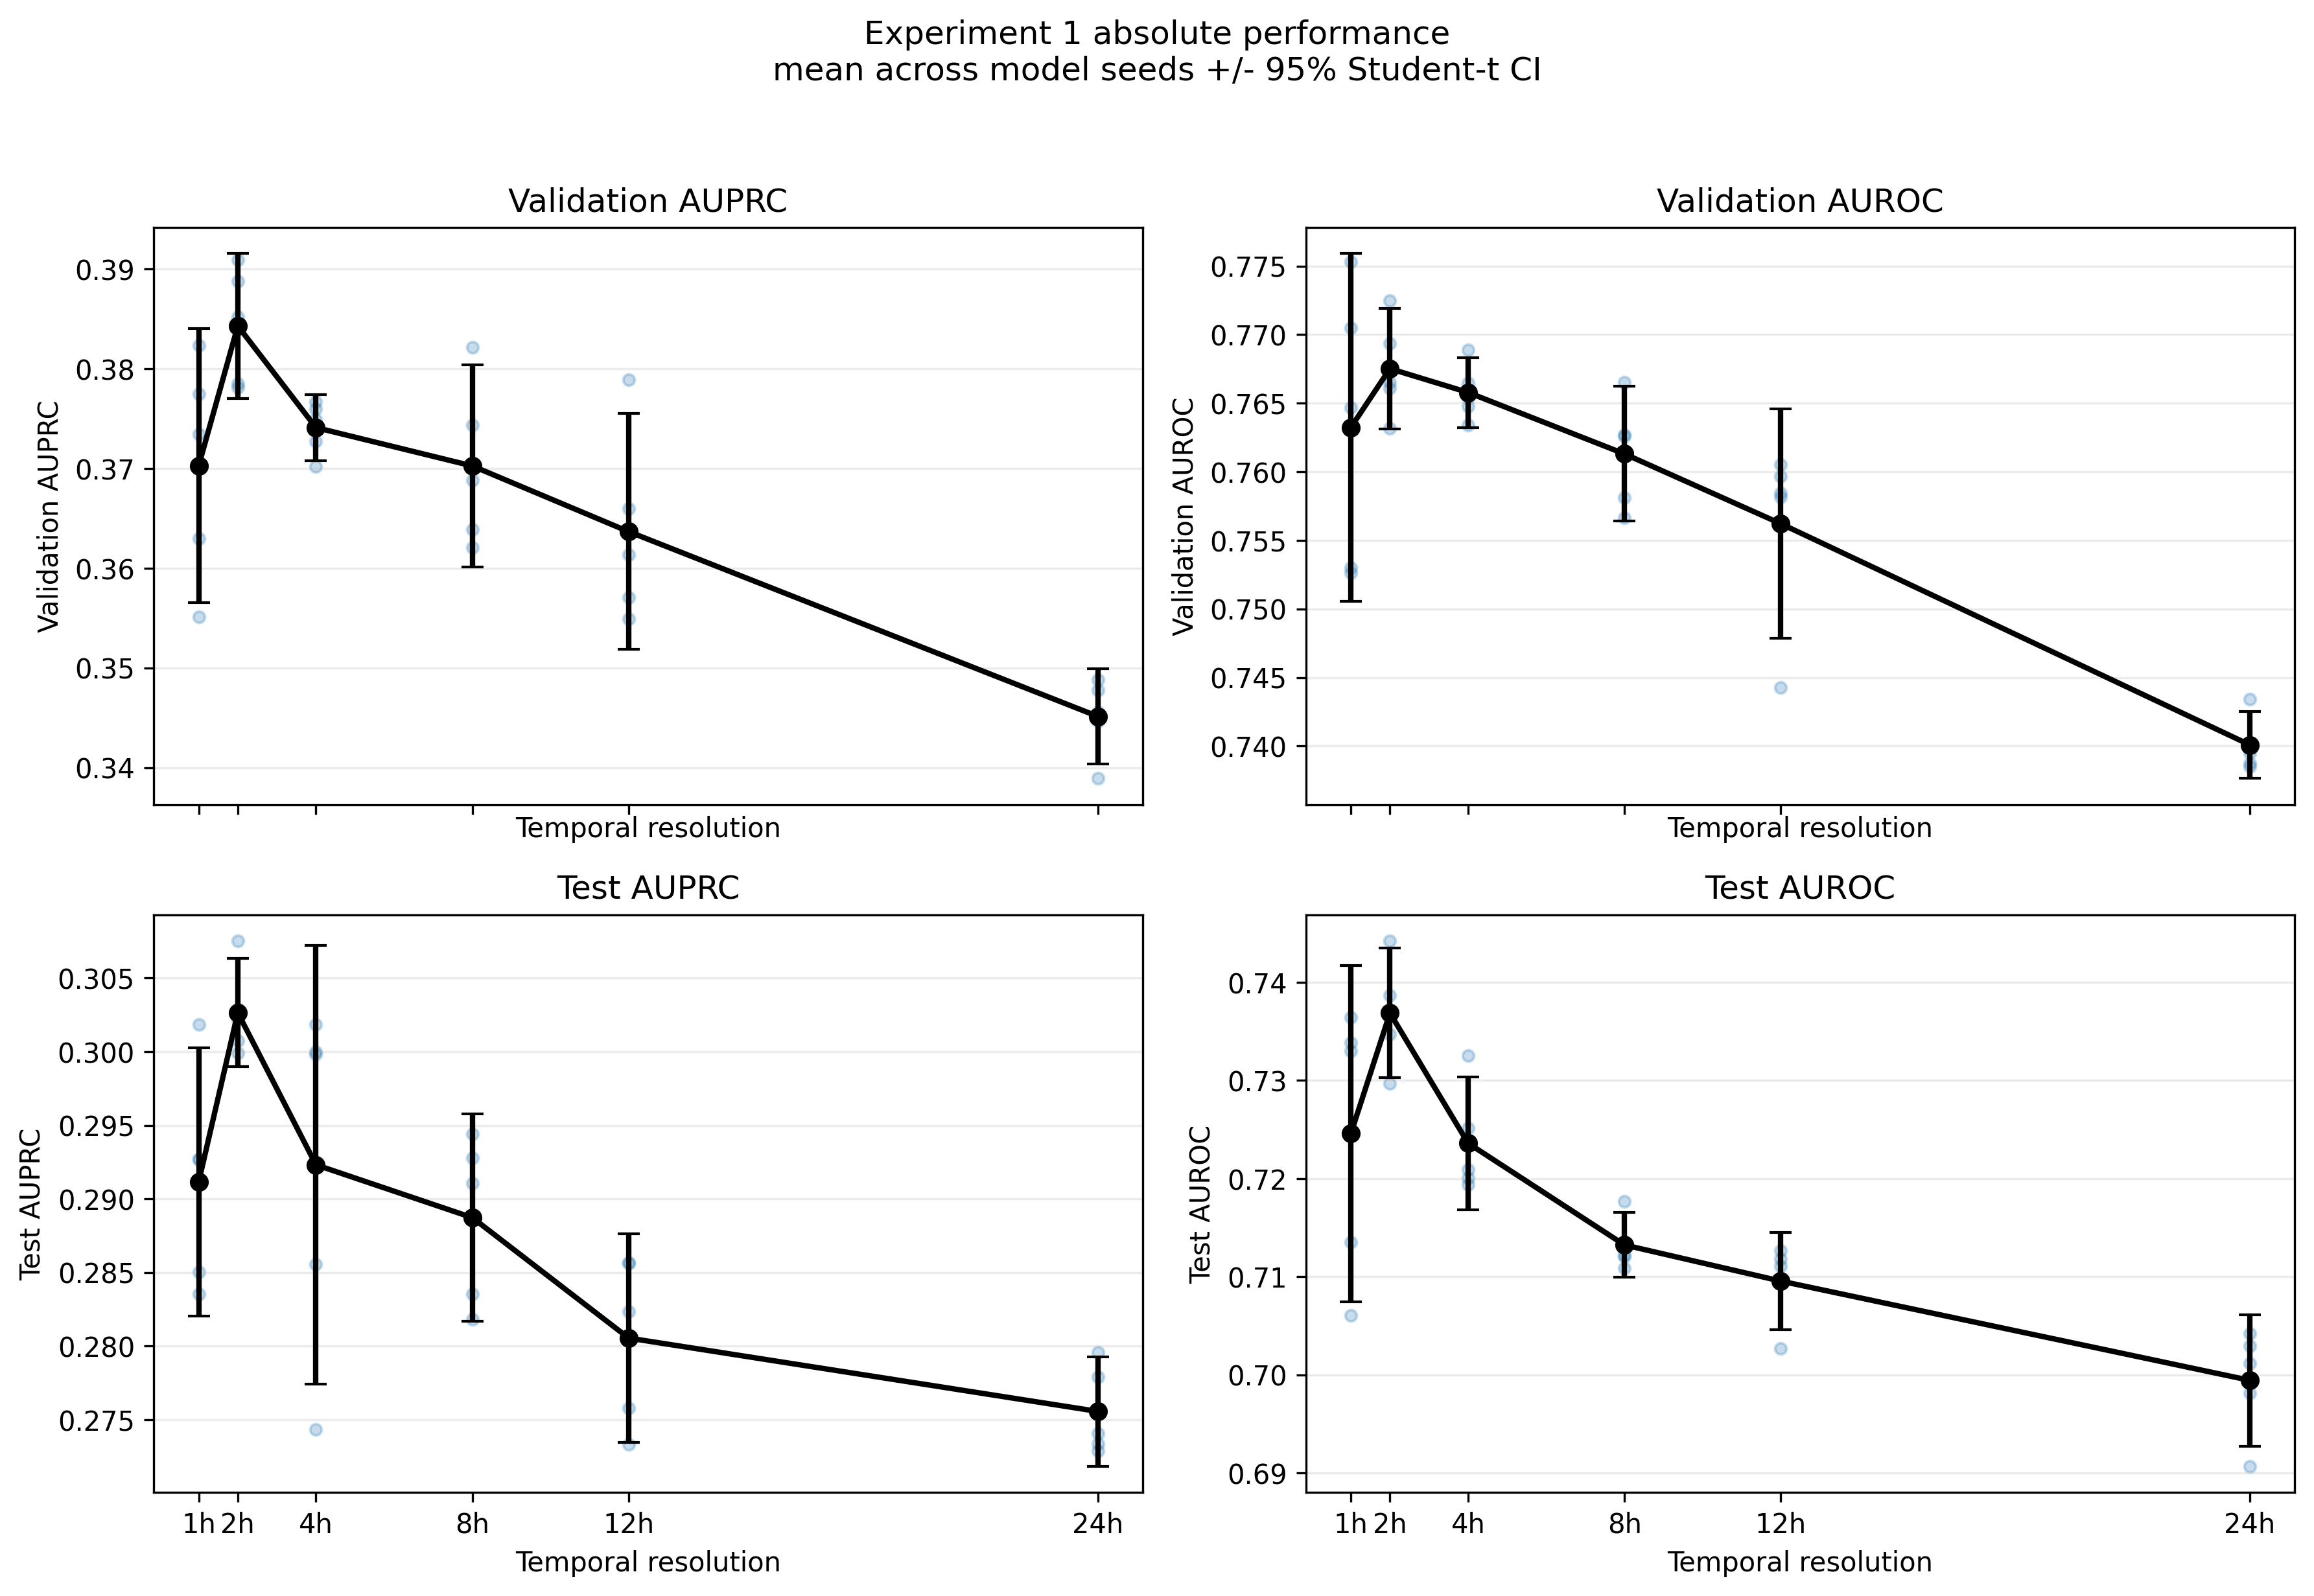

In [38]:
for title, key in [
    ("Exp1 validation AUPRC", "exp1_val_auprc_summary"),
    ("Exp1 validation AUROC", "exp1_val_auroc_summary"),
    ("Exp1 test AUPRC", "exp1_test_auprc_summary"),
    ("Exp1 test AUROC", "exp1_test_auroc_summary"),
]:
    show_table(title, add_status(DATA[key]), ["timestep", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"])

show_source_plot(
    "exp1",
    IHM_PLOTS,
    "experiment1_absolute_performance_ci95.png",
    "Exp1 source figure: absolute performance",
)


**Degradation guide:** The degradation tables and plots show `1h - coarse`, computed within model seed and summarized with a 95% Student-t CI across seeds. Positive values mean degradation under coarser resolution. The interval is across model seeds, not a patient bootstrap interval. Partial status reflects how many paired seed-level drops are available.


In [39]:
exp1_auprc_drop = add_status(DATA["exp1_auprc_drop_summary"])
exp1_auroc_drop = add_status(DATA["exp1_auroc_drop_summary"])
show_table("Exp1 AUPRC degradation from 1h", exp1_auprc_drop, ["timestep", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"])
show_table("Exp1 AUROC degradation from 1h", exp1_auroc_drop, ["timestep", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"])
print("No Exp1 degradation source figure is displayed because the Exp1 source notebook does not define one.")



Exp1 AUPRC degradation from 1h


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,5,COMPLETE
1,2.0,-0.011484,0.008554,0.003826,-0.022106,-0.000863,5,COMPLETE
2,4.0,-0.001151,0.015281,0.006834,-0.020125,0.017823,5,COMPLETE
3,8.0,0.002436,0.011670,0.005219,-0.012054,0.016927,5,COMPLETE
4,12.0,0.010617,0.012298,0.005500,-0.004653,0.025887,5,COMPLETE
5,24.0,0.015598,0.008970,0.004012,0.004460,0.026736,5,COMPLETE



Exp1 AUROC degradation from 1h


,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,5,COMPLETE
1,2.0,-0.012291,0.017835,0.007976,-0.034436,0.009855,5,COMPLETE
2,4.0,0.000974,0.017698,0.007915,-0.021001,0.022950,5,COMPLETE
3,8.0,0.011341,0.012662,0.005663,-0.004381,0.027064,5,COMPLETE
4,12.0,0.015026,0.015806,0.007069,-0.004599,0.034652,5,COMPLETE
5,24.0,0.025141,0.017781,0.007952,0.003063,0.047218,5,COMPLETE


No Exp1 degradation source figure is displayed because the Exp1 source notebook does not define one.


## 2. Experiment 2A - Does Frequency Matter More For Short Horizons?

### Scientific Question
At a fixed prediction time of 24h after ICU admission, is the cost of coarser measurement frequency larger for short prediction horizons than for long horizons?

Connection to Experiment 1: Experiment 1 establishes whether coarser temporal resolution affects prediction at all, while Experiment 2A tests whether the size of that effect depends on how far into the future the outcome is predicted.

### Experimental Design
Model: LSTM. 

Task: fixed-horizon ICU outcome from the source notebook. 

Prediction time: 24h after ICU admission. 

Prediction horizons: 12h, 24h, 48h, 96h, and 168h when available. 

Temporal resolution varies across available source timesteps. 

Training and test observation regimes match the resolution being evaluated. Checkpoints are selected by validation AUPRC.

### Quantity Being Measured
Absolute performance is `M(h,r,s)`. Degradation is `Delta(h,r,s) = M(h,1h,s) - M(h,r,s)`, computed within seed.

Positive degradation means the coarser resolution performed worse than 1h for that horizon. For Brier bootstrap contrasts, the source reverses the raw lower-is-better metric so positive still means the 1h/reference condition is better.

### Why This Comparison Is Informative
It asks whether temporal detail is especially important for near-term prediction rather than equally important across all horizons.

### Expected Evidence
If short-horizon prediction depends more on fine temporal information, degradation should be larger at 12h than at longer horizons. If the effect is horizon-independent, degradation should be similar across horizons. Non-monotonic patterns should be displayed.

### Caveats
Raw AUPRC cannot be compared directly across horizons because outcome prevalence changes. Across-seed CIs and paired patient-bootstrap CIs are different uncertainty estimates.


**Validation/test performance guide:** These tables and plots show absolute AUPRC/AUROC by horizon and temporal resolution. Values are source-computed means across model seeds with Student-t CIs. `n` is the number of model seeds contributing to each point. Points with fewer than the planned five seeds are still shown and should be interpreted as partial results. Raw AUPRC across horizons reflects different prevalence and should be interpreted cautiously.



Exp2A validation AUPRC


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,1.0,0.447704,0.027991,0.008851,0.427681,0.467728,10,COMPLETE
1,12,2.0,0.471397,0.002210,0.000988,0.468653,0.474141,5,COMPLETE
2,12,4.0,0.444728,0.001261,0.000564,0.443162,0.446294,5,COMPLETE
3,12,8.0,0.420502,0.003010,0.001346,0.416765,0.424239,5,COMPLETE
4,12,12.0,0.416039,0.002628,0.001175,0.412777,0.419302,5,COMPLETE
5,12,24.0,0.352244,0.001266,0.000566,0.350673,0.353816,5,COMPLETE
6,24,1.0,0.598446,0.003384,0.001513,0.594244,0.602648,5,COMPLETE
7,24,2.0,0.595687,0.002437,0.001090,0.592662,0.598713,5,COMPLETE
8,24,4.0,0.581138,0.002779,0.001243,0.577687,0.584589,5,COMPLETE
9,24,8.0,0.578795,0.001421,0.000635,0.577031,0.580559,5,COMPLETE



Exp2A validation AUROC


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,1.0,0.713132,0.021447,0.006782,0.697790,0.728474,10,COMPLETE
1,12,2.0,0.729151,0.001286,0.000575,0.727554,0.730748,5,COMPLETE
2,12,4.0,0.713962,0.002237,0.001000,0.711185,0.716739,5,COMPLETE
3,12,8.0,0.687468,0.001337,0.000598,0.685808,0.689128,5,COMPLETE
4,12,12.0,0.673099,0.002201,0.000984,0.670366,0.675831,5,COMPLETE
5,12,24.0,0.625574,0.001911,0.000855,0.623200,0.627947,5,COMPLETE
6,24,1.0,0.696884,0.002122,0.000949,0.694250,0.699519,5,COMPLETE
7,24,2.0,0.696739,0.002011,0.000899,0.694242,0.699236,5,COMPLETE
8,24,4.0,0.688475,0.001482,0.000663,0.686635,0.690314,5,COMPLETE
9,24,8.0,0.680789,0.001331,0.000595,0.679136,0.682442,5,COMPLETE



Exp2A test AUPRC


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,1.0,0.461798,0.030565,0.009666,0.439933,0.483663,10,COMPLETE
1,12,2.0,0.483862,0.003683,0.001647,0.479290,0.488435,5,COMPLETE
2,12,4.0,0.467079,0.002981,0.001333,0.463378,0.470781,5,COMPLETE
3,12,8.0,0.412376,0.004491,0.002008,0.406800,0.417952,5,COMPLETE
4,12,12.0,0.416252,0.001875,0.000839,0.413923,0.418581,5,COMPLETE
5,12,24.0,0.338577,0.003585,0.001603,0.334126,0.343028,5,COMPLETE
6,24,1.0,0.608492,0.002376,0.001063,0.605541,0.611442,5,COMPLETE
7,24,2.0,0.600849,0.004118,0.001842,0.595736,0.605963,5,COMPLETE
8,24,4.0,0.598515,0.002998,0.001341,0.594792,0.602237,5,COMPLETE
9,24,8.0,0.578585,0.002337,0.001045,0.575683,0.581486,5,COMPLETE



Exp2A test AUROC


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,1.0,0.722350,0.023639,0.007475,0.705439,0.739260,10,COMPLETE
1,12,2.0,0.740450,0.002244,0.001004,0.737663,0.743236,5,COMPLETE
2,12,4.0,0.734098,0.001701,0.000761,0.731985,0.736210,5,COMPLETE
3,12,8.0,0.693602,0.002824,0.001263,0.690096,0.697109,5,COMPLETE
4,12,12.0,0.687685,0.002316,0.001036,0.684809,0.690560,5,COMPLETE
5,12,24.0,0.624666,0.003388,0.001515,0.620460,0.628873,5,COMPLETE
6,24,1.0,0.701891,0.002462,0.001101,0.698834,0.704947,5,COMPLETE
7,24,2.0,0.695419,0.002042,0.000913,0.692884,0.697954,5,COMPLETE
8,24,4.0,0.694106,0.001930,0.000863,0.691710,0.696502,5,COMPLETE
9,24,8.0,0.675021,0.001336,0.000598,0.673362,0.676680,5,COMPLETE



Exp2A source figures: absolute performance

experiment2a_validation_absolute_performance_ci95.png


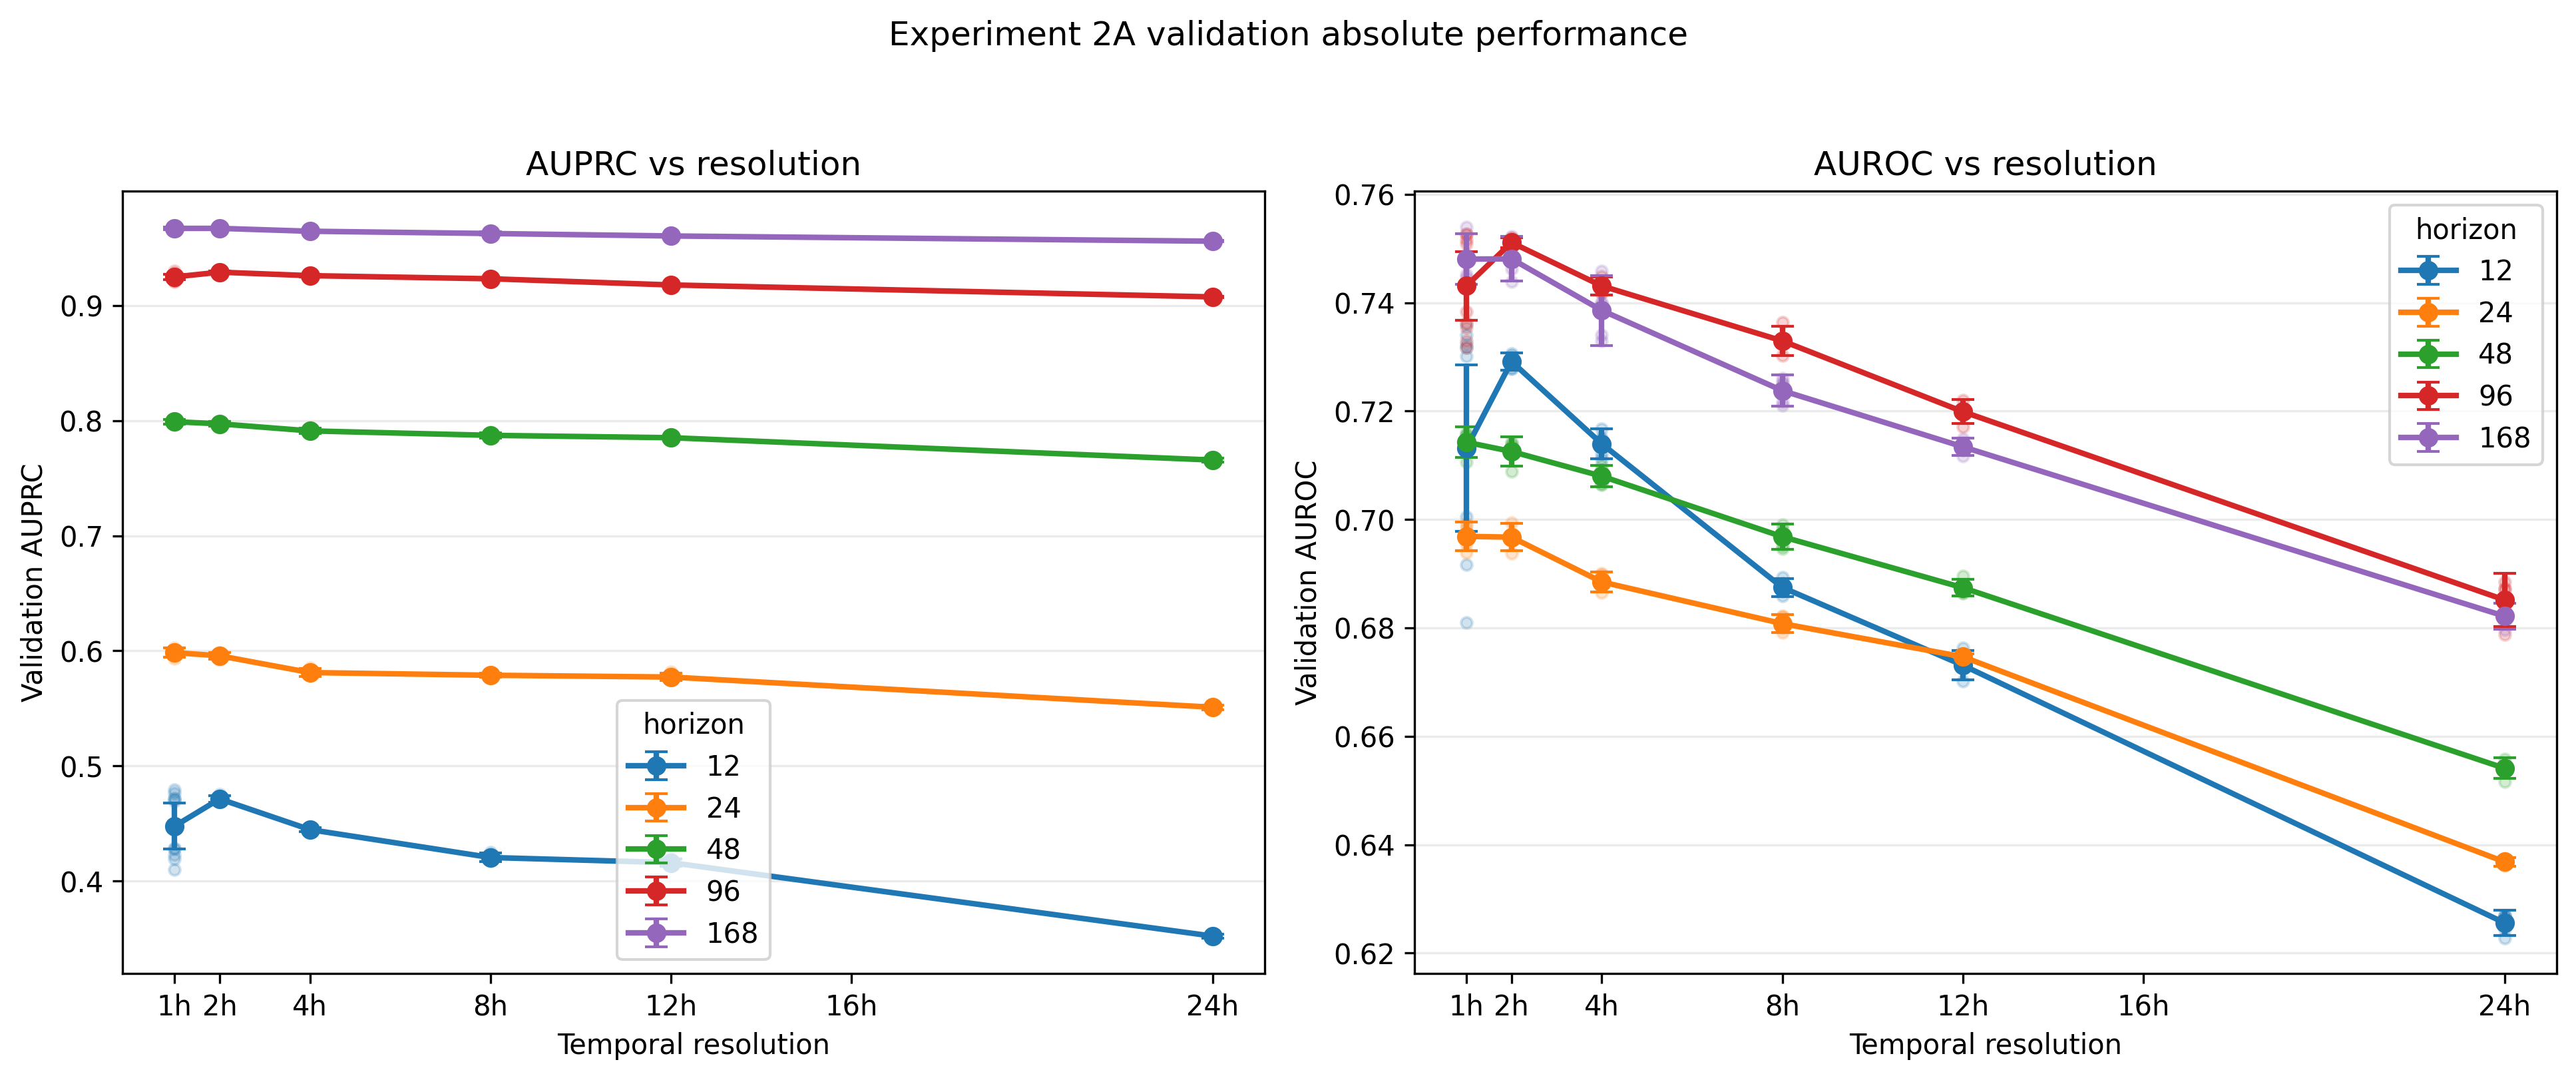


experiment2a_test_absolute_performance_ci95.png


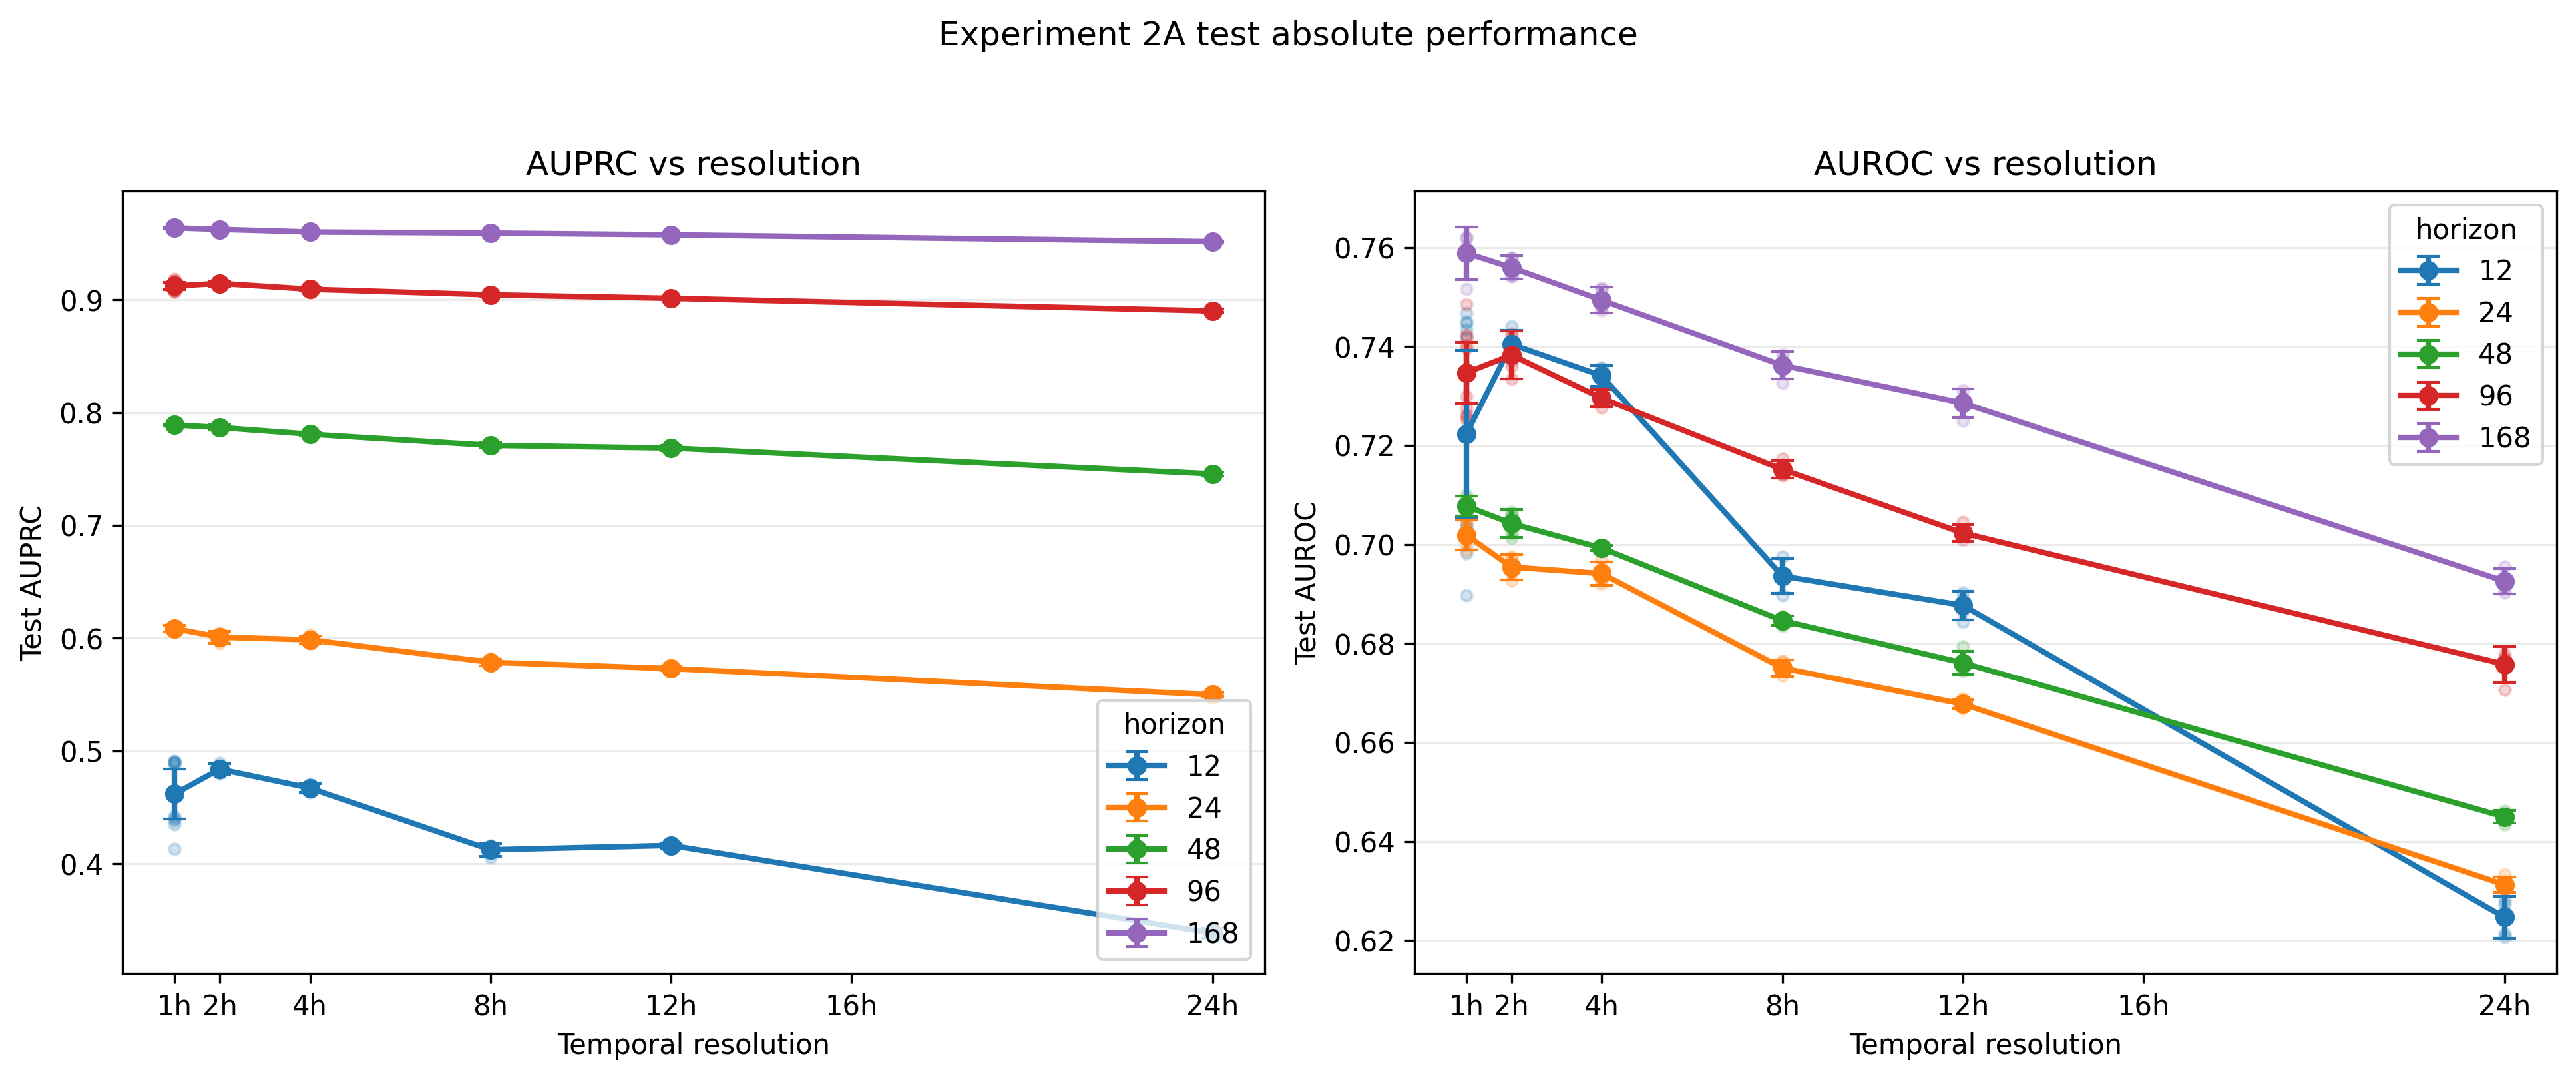

In [40]:
for title, key in [
    ("Exp2A validation AUPRC", "exp2a_val_auprc_summary"),
    ("Exp2A validation AUROC", "exp2a_val_auroc_summary"),
    ("Exp2A test AUPRC", "exp2a_test_auprc_summary"),
    ("Exp2A test AUROC", "exp2a_test_auroc_summary"),
]:
    show_table(title, add_status(DATA[key]), ["horizon", "timestep", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"])

show_source_plot_group(
    "Exp2A source figures: absolute performance",
    "exp2a",
    FH_PLOTS,
    [
        "experiment2a_validation_absolute_performance_ci95.png",
        "experiment2a_test_absolute_performance_ci95.png",
    ],
)


**Degradation and bootstrap guide:** Degradation summaries show `1h - coarse` with Student-t CIs across seeds. The patient-bootstrap tables come from paired test predictions and include patient-level bootstrap CIs. Positive values mean the 1h/reference condition performed better; for Brier, positive means lower Brier for the reference.



Exp2A validation AUPRC degradation


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,2.0,-0.023693,0.028019,0.008861,-0.043737,-0.003649,10,COMPLETE
1,12,4.0,0.002977,0.027919,0.008829,-0.016995,0.022949,10,COMPLETE
2,12,8.0,0.027202,0.028469,0.009003,0.006837,0.047568,10,COMPLETE
3,12,12.0,0.031665,0.028119,0.008892,0.011550,0.051780,10,COMPLETE
4,12,24.0,0.095460,0.027902,0.008823,0.075500,0.115420,10,COMPLETE
5,24,2.0,0.002759,0.001790,0.000801,0.000536,0.004982,5,COMPLETE
6,24,4.0,0.017308,0.003364,0.001504,0.013132,0.021485,5,COMPLETE
7,24,8.0,0.019651,0.002819,0.001261,0.016151,0.023151,5,COMPLETE
8,24,12.0,0.021203,0.005643,0.002524,0.014197,0.028210,5,COMPLETE
9,24,24.0,0.047444,0.003676,0.001644,0.042879,0.052008,5,COMPLETE



Exp2A validation AUROC degradation


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,2.0,-0.016019,0.021435,0.006778,-0.031352,-0.000685,10,COMPLETE
1,12,4.0,-0.000830,0.021387,0.006763,-0.016129,0.014469,10,COMPLETE
2,12,8.0,0.025664,0.021509,0.006802,0.010278,0.041050,10,COMPLETE
3,12,12.0,0.040033,0.021543,0.006812,0.024623,0.055444,10,COMPLETE
4,12,24.0,0.087558,0.021365,0.006756,0.072275,0.102842,10,COMPLETE
5,24,2.0,0.000145,0.003047,0.001362,-0.003637,0.003928,5,COMPLETE
6,24,4.0,0.008410,0.001328,0.000594,0.006761,0.010059,5,COMPLETE
7,24,8.0,0.016095,0.002356,0.001054,0.013169,0.019021,5,COMPLETE
8,24,12.0,0.022218,0.002263,0.001012,0.019408,0.025028,5,COMPLETE
9,24,24.0,0.060049,0.002235,0.001000,0.057274,0.062825,5,COMPLETE



Exp2A test AUPRC degradation


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,2.0,-0.022064,0.030808,0.009742,-0.044103,-0.000025,10,COMPLETE
1,12,4.0,-0.005281,0.031119,0.009841,-0.027542,0.016980,10,COMPLETE
2,12,8.0,0.049422,0.030288,0.009578,0.027755,0.071089,10,COMPLETE
3,12,12.0,0.045546,0.030643,0.009690,0.023626,0.067466,10,COMPLETE
4,12,24.0,0.123221,0.030511,0.009648,0.101395,0.145047,10,COMPLETE
5,24,2.0,0.007642,0.005583,0.002497,0.000710,0.014574,5,COMPLETE
6,24,4.0,0.009977,0.004232,0.001893,0.004722,0.015231,5,COMPLETE
7,24,8.0,0.029907,0.002466,0.001103,0.026845,0.032969,5,COMPLETE
8,24,12.0,0.035476,0.003495,0.001563,0.031137,0.039815,5,COMPLETE
9,24,24.0,0.058729,0.002433,0.001088,0.055708,0.061751,5,COMPLETE



Exp2A test AUROC degradation


,horizon,timestep,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,2.0,-0.018100,0.023706,0.007496,-0.035058,-0.001142,10,COMPLETE
1,12,4.0,-0.011748,0.023850,0.007542,-0.028810,0.005313,10,COMPLETE
2,12,8.0,0.028748,0.023553,0.007448,0.011899,0.045596,10,COMPLETE
3,12,12.0,0.034665,0.023708,0.007497,0.017705,0.051624,10,COMPLETE
4,12,24.0,0.097683,0.023741,0.007508,0.080700,0.114667,10,COMPLETE
5,24,2.0,0.006472,0.003404,0.001522,0.002245,0.010698,5,COMPLETE
6,24,4.0,0.007785,0.003582,0.001602,0.003338,0.012232,5,COMPLETE
7,24,8.0,0.026870,0.002496,0.001116,0.023770,0.029969,5,COMPLETE
8,24,12.0,0.034152,0.002762,0.001235,0.030722,0.037582,5,COMPLETE
9,24,24.0,0.070652,0.002011,0.000899,0.068155,0.073149,5,COMPLETE



Exp2A source figures: degradation

experiment2a_validation_degradation_ci95.png


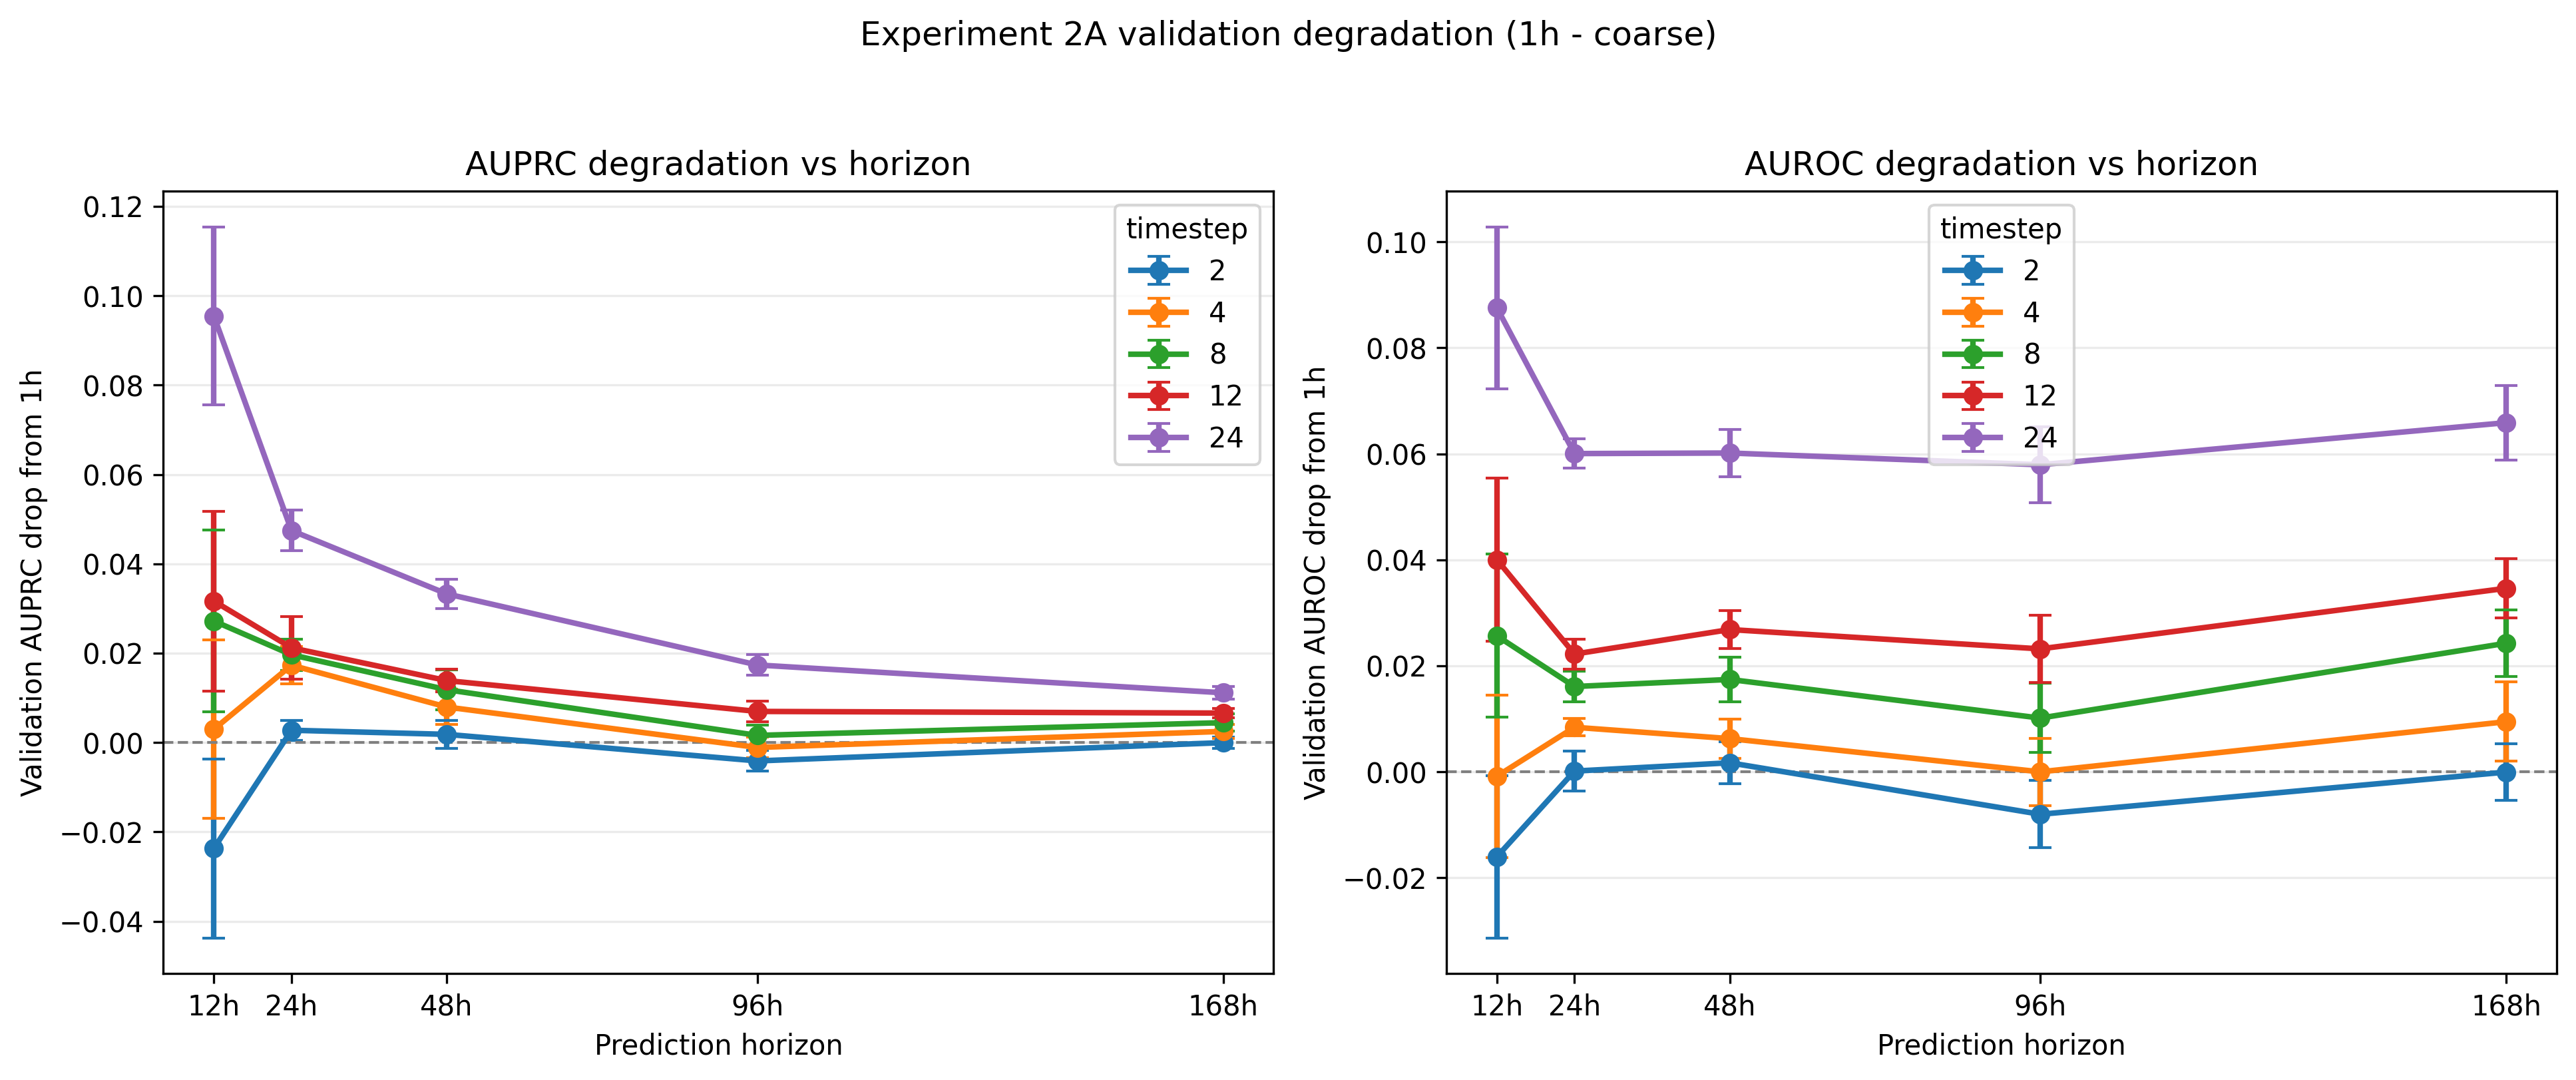


experiment2a_test_degradation_ci95.png


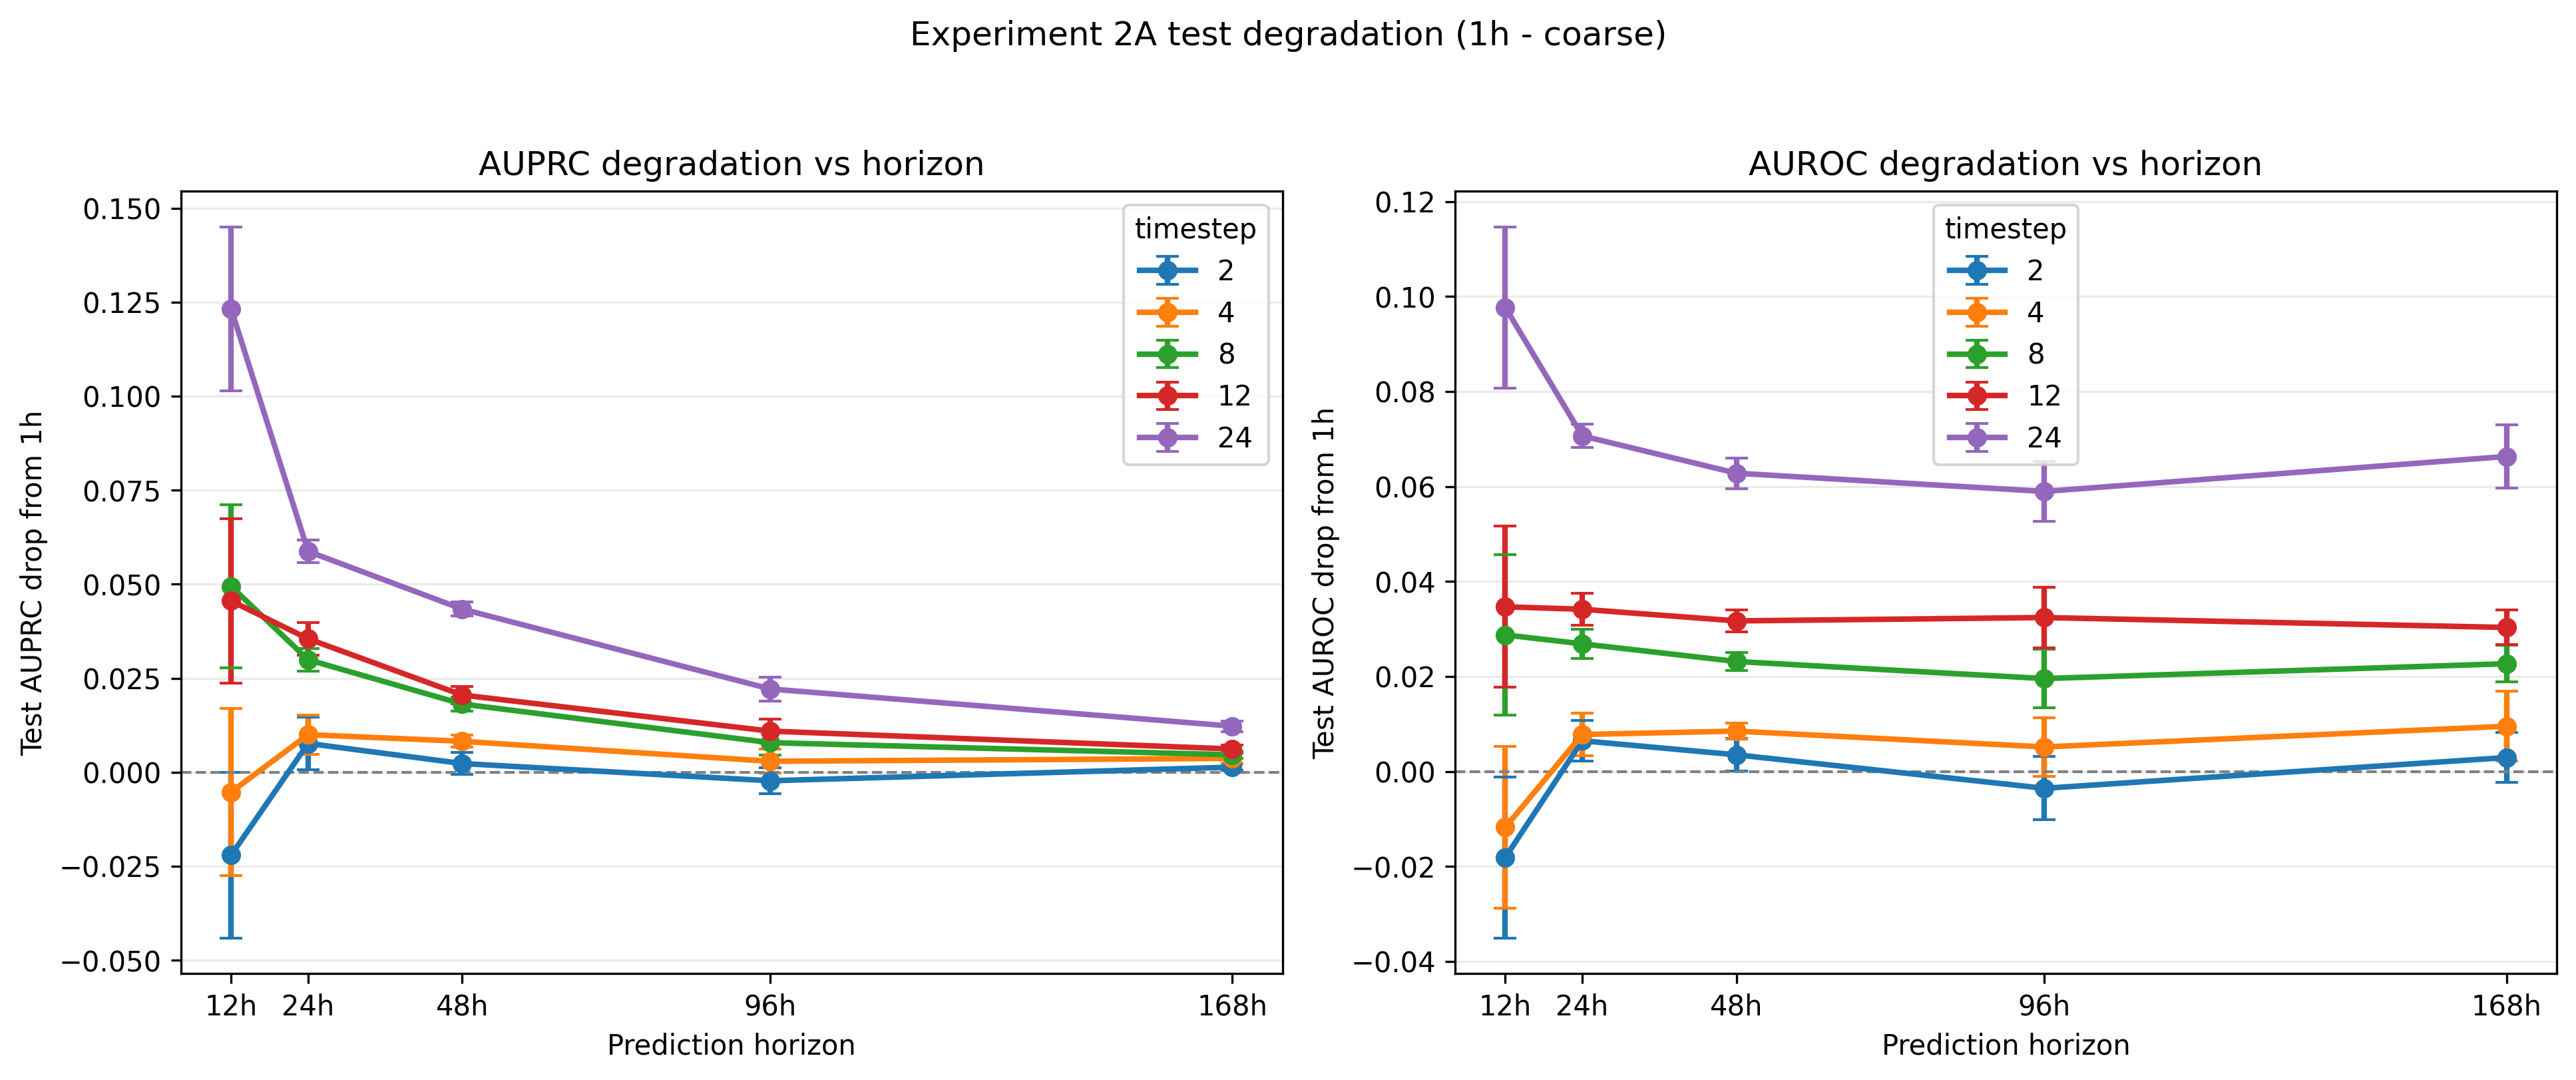


Exp2A across-seed paired patient-bootstrap summary


,horizon,timestep,metric,mean_difference,sd_difference,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,status
0,12,2,auprc,0.005955,0.003576,-0.002410,0.014196,5,COMPLETE
1,12,4,auprc,0.022738,0.003622,0.010645,0.034793,5,COMPLETE
2,12,8,auprc,0.077441,0.004810,0.061450,0.095029,5,COMPLETE
3,12,12,auprc,0.073565,0.001258,0.056149,0.090238,5,COMPLETE
4,12,24,auprc,0.151240,0.003207,0.130660,0.172868,5,COMPLETE
5,24,2,auprc,0.007642,0.005583,0.000990,0.014169,5,COMPLETE
6,24,4,auprc,0.009977,0.004232,0.000873,0.019680,5,COMPLETE
7,24,8,auprc,0.029907,0.002466,0.017716,0.041731,5,COMPLETE
8,24,12,auprc,0.035476,0.003495,0.023102,0.048119,5,COMPLETE
9,24,24,auprc,0.058729,0.002433,0.042838,0.073632,5,COMPLETE


In [41]:
for title, key in [
    ("Exp2A validation AUPRC degradation", "exp2a_val_auprc_drop_summary"),
    ("Exp2A validation AUROC degradation", "exp2a_val_auroc_drop_summary"),
    ("Exp2A test AUPRC degradation", "exp2a_test_auprc_drop_summary"),
    ("Exp2A test AUROC degradation", "exp2a_test_auroc_drop_summary"),
]:
    show_table(title, add_status(DATA[key]), ["horizon", "timestep", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"])

show_source_plot_group(
    "Exp2A source figures: degradation",
    "exp2a",
    FH_PLOTS,
    [
        "experiment2a_validation_degradation_ci95.png",
        "experiment2a_test_degradation_ci95.png",
    ],
)

exp2a_boot = add_status(DATA["exp2a_bootstrap_summary"], n_col="n_seeds")
show_table("Exp2A across-seed paired patient-bootstrap summary", exp2a_boot, ["horizon", "timestep", "metric", "mean_difference", "sd_difference", "seed_ci95_low", "seed_ci95_high", "patient_bootstrap_ci_low", "patient_bootstrap_ci_high", "n_seeds", "missing_seeds", "status"], max_rows=300)


## 3-4. Experiment 2B/C - Why Does Frequency Matter, And Does The Mechanism Depend On Severity?

### Scientific Question
Which parts of the frequency effect are associated with observation loss, temporal placement, and representation/grid changes? Does that mechanism change as thinning becomes more severe?

### Experimental Design
Model: LSTM. Task: fixed-horizon ICU outcome. Prediction time and horizons follow the source notebook. Conditions are preserved exactly from the source:

- A: native observations represented on the standard 1h grid.
- B: structured r-hour measurement selection/thinning; retained observations keep original timestamps and are represented on the downstream 1h grid.
- C: random matched-count thinning; for each patient-variable, retain the same effective number of observations as B but choose positions randomly from originally occupied 1h cells. Downstream representation remains 1h.
- D: standard r-hour discretization using the ordinary r-hour grid and therefore fewer recurrent steps.

| Condition                   | Observation selection                                            | Observation count                                         | Timing of retained observations              | Representation grid | Recurrent sequence length | What changes relative to A                                              |
| --------------------------- | ---------------------------------------------------------------- | --------------------------------------------------------- | -------------------------------------------- | ------------------- | ------------------------- | ----------------------------------------------------------------------- |
| **A: Dense / native**       | No thinning                                                      | Full                                                      | Original timing                              | **1h**              | Fixed by 1h grid          | Reference                                                               |
| **B: Structured thinning**  | Keep measurements according to an **r-hour structured schedule** | Reduced                                                   | Original timestamps of retained measurements | **1h**              | Same grid length as A     | Observation availability/frequency                                      |
| **C: Random matched-count** | Randomly retain observations                                     | Matched to B in both total observation count and per-variable observation count                             | Randomly selected occupied positions         | **1h**              | Same grid length as A/B   | Temporal placement, while holding observation count approximately fixed |
| **D: Coarse grid**          | No explicit thinning step                                        | Measurements aggregated/represented on an **r-hour grid** | Coarsened to r-hour bins                     | **r-hour**          | **Shorter than A/B/C**    | Representation/granularity and sequence length                          |

Fixed across A–D: patient cohort, prediction task and horizon, input variables, model architecture/hyperparameters, and evaluation procedure. A–C all use the same 1h downstream grid, so B and C change which observations are available without changing recurrent sequence length. D changes the temporal representation itself by using an r-hour grid with fewer recurrent steps.

### Quantity Being Measured
Absolute performance compares A/B/C/D condition metrics. Primary contrasts are A-vs-B, B-vs-C, and B-vs-D. Positive contrast values mean the left condition is better; for Brier the source reverses sign so positive still means the left/reference condition has lower Brier.

| Contrast  | Main question                                                                                                       |
| --------- | ------------------------------------------------------------------------------------------------------------------- |
| **A − B** | What is lost when observations become systematically **less frequent**?                                                 |
| **B − C** | Does the **temporal pattern** of missing observations matter when observation count is matched?                     |
| **B − D** | Does changing the **representation/grid and recurrent sequence length** matter beyond sparse observation selection? |


### Why This Comparison Is Informative
A-vs-B isolates structured observation removal relative to native observations. B-vs-C asks whether temporal pattern matters after matching observation count. B-vs-D asks whether the coarse representation/grid changes performance beyond sparse observation selection.

### Expected Evidence
Increasing A-B with `r` suggests stronger information loss at lower observation frequency. Increasing B-C suggests temporal structure matters more with stronger thinning. Increasing B-D suggests representation/grid choice matters more. Flat curves suggest relative insensitivity to severity.

### Caveats
A/B/C/D are not an additive causal decomposition. B-vs-D is not a pure sequence-length contrast. Use only available `r` values; do not fabricate missing severities.


**Absolute condition guide:** The next table contains all exported A/B/C/D condition-level performance. Means and CIs are across model seeds. Brier raw values are lower-is-better here; only contrast tables use the positive-is-left-better sign convention. Completeness is based on available seed counts.


**Exp2B/C input-information characterization:** Structured thinning is introduced here at `r=4` only. Observed tokens are real `(timestamp, variable)` values in the first 24h window; occupied 1h bins and observed channels are also based on real observations, not imputed values. The post-discretization sequence length is shown only as a representation sanity check.


In [ ]:
exp2b_input_information_cols = [
    "condition", "n_stays",
    "mean_token_count", "median_token_count", "p25_token_count", "p75_token_count", "p95_token_count",
    "mean_token_retained_fraction", "median_token_retained_fraction",
    "mean_occupied_1h_bins", "median_occupied_1h_bins",
    "mean_channels_observed", "median_channels_observed",
    "post_discretization_sequence_length",
]
show_table(
    "Exp2B/C input-information characterization: dense vs structured r=4",
    DATA["exp2b_input_information_summary"],
    exp2b_input_information_cols,
    max_rows=20,
)



Exp2B/C A/B/C/D condition-level summary


,horizon,r,condition,metric,mean,sd,sem,ci95_low,ci95_high,n,status
0,12,4,A,val_auprc,0.473711,0.003906,0.001747,0.468861,0.478561,5,COMPLETE
1,12,4,B,val_auprc,0.457758,0.005841,0.002612,0.450506,0.465010,5,COMPLETE
2,12,4,C,val_auprc,0.446423,0.002266,0.001013,0.443609,0.449236,5,COMPLETE
3,12,4,D,val_auprc,0.444728,0.001261,0.000564,0.443162,0.446294,5,COMPLETE
4,24,4,A,val_auprc,0.598446,0.003384,0.001513,0.594244,0.602648,5,COMPLETE
5,24,4,D,val_auprc,0.581138,0.002779,0.001243,0.577687,0.584589,5,COMPLETE
6,48,4,A,val_auprc,0.798992,0.001732,0.000774,0.796842,0.801142,5,COMPLETE
7,48,4,D,val_auprc,0.791035,0.001843,0.000824,0.788746,0.793324,5,COMPLETE
8,96,4,A,val_auprc,0.927542,0.001232,0.000551,0.926012,0.929072,5,COMPLETE
9,96,4,B,val_auprc,0.922843,0.000475,0.000213,0.922253,0.923433,5,COMPLETE



Exp2B/C source figures: condition-level performance

experiment2b_r4_test_auroc_by_condition_ci95.png


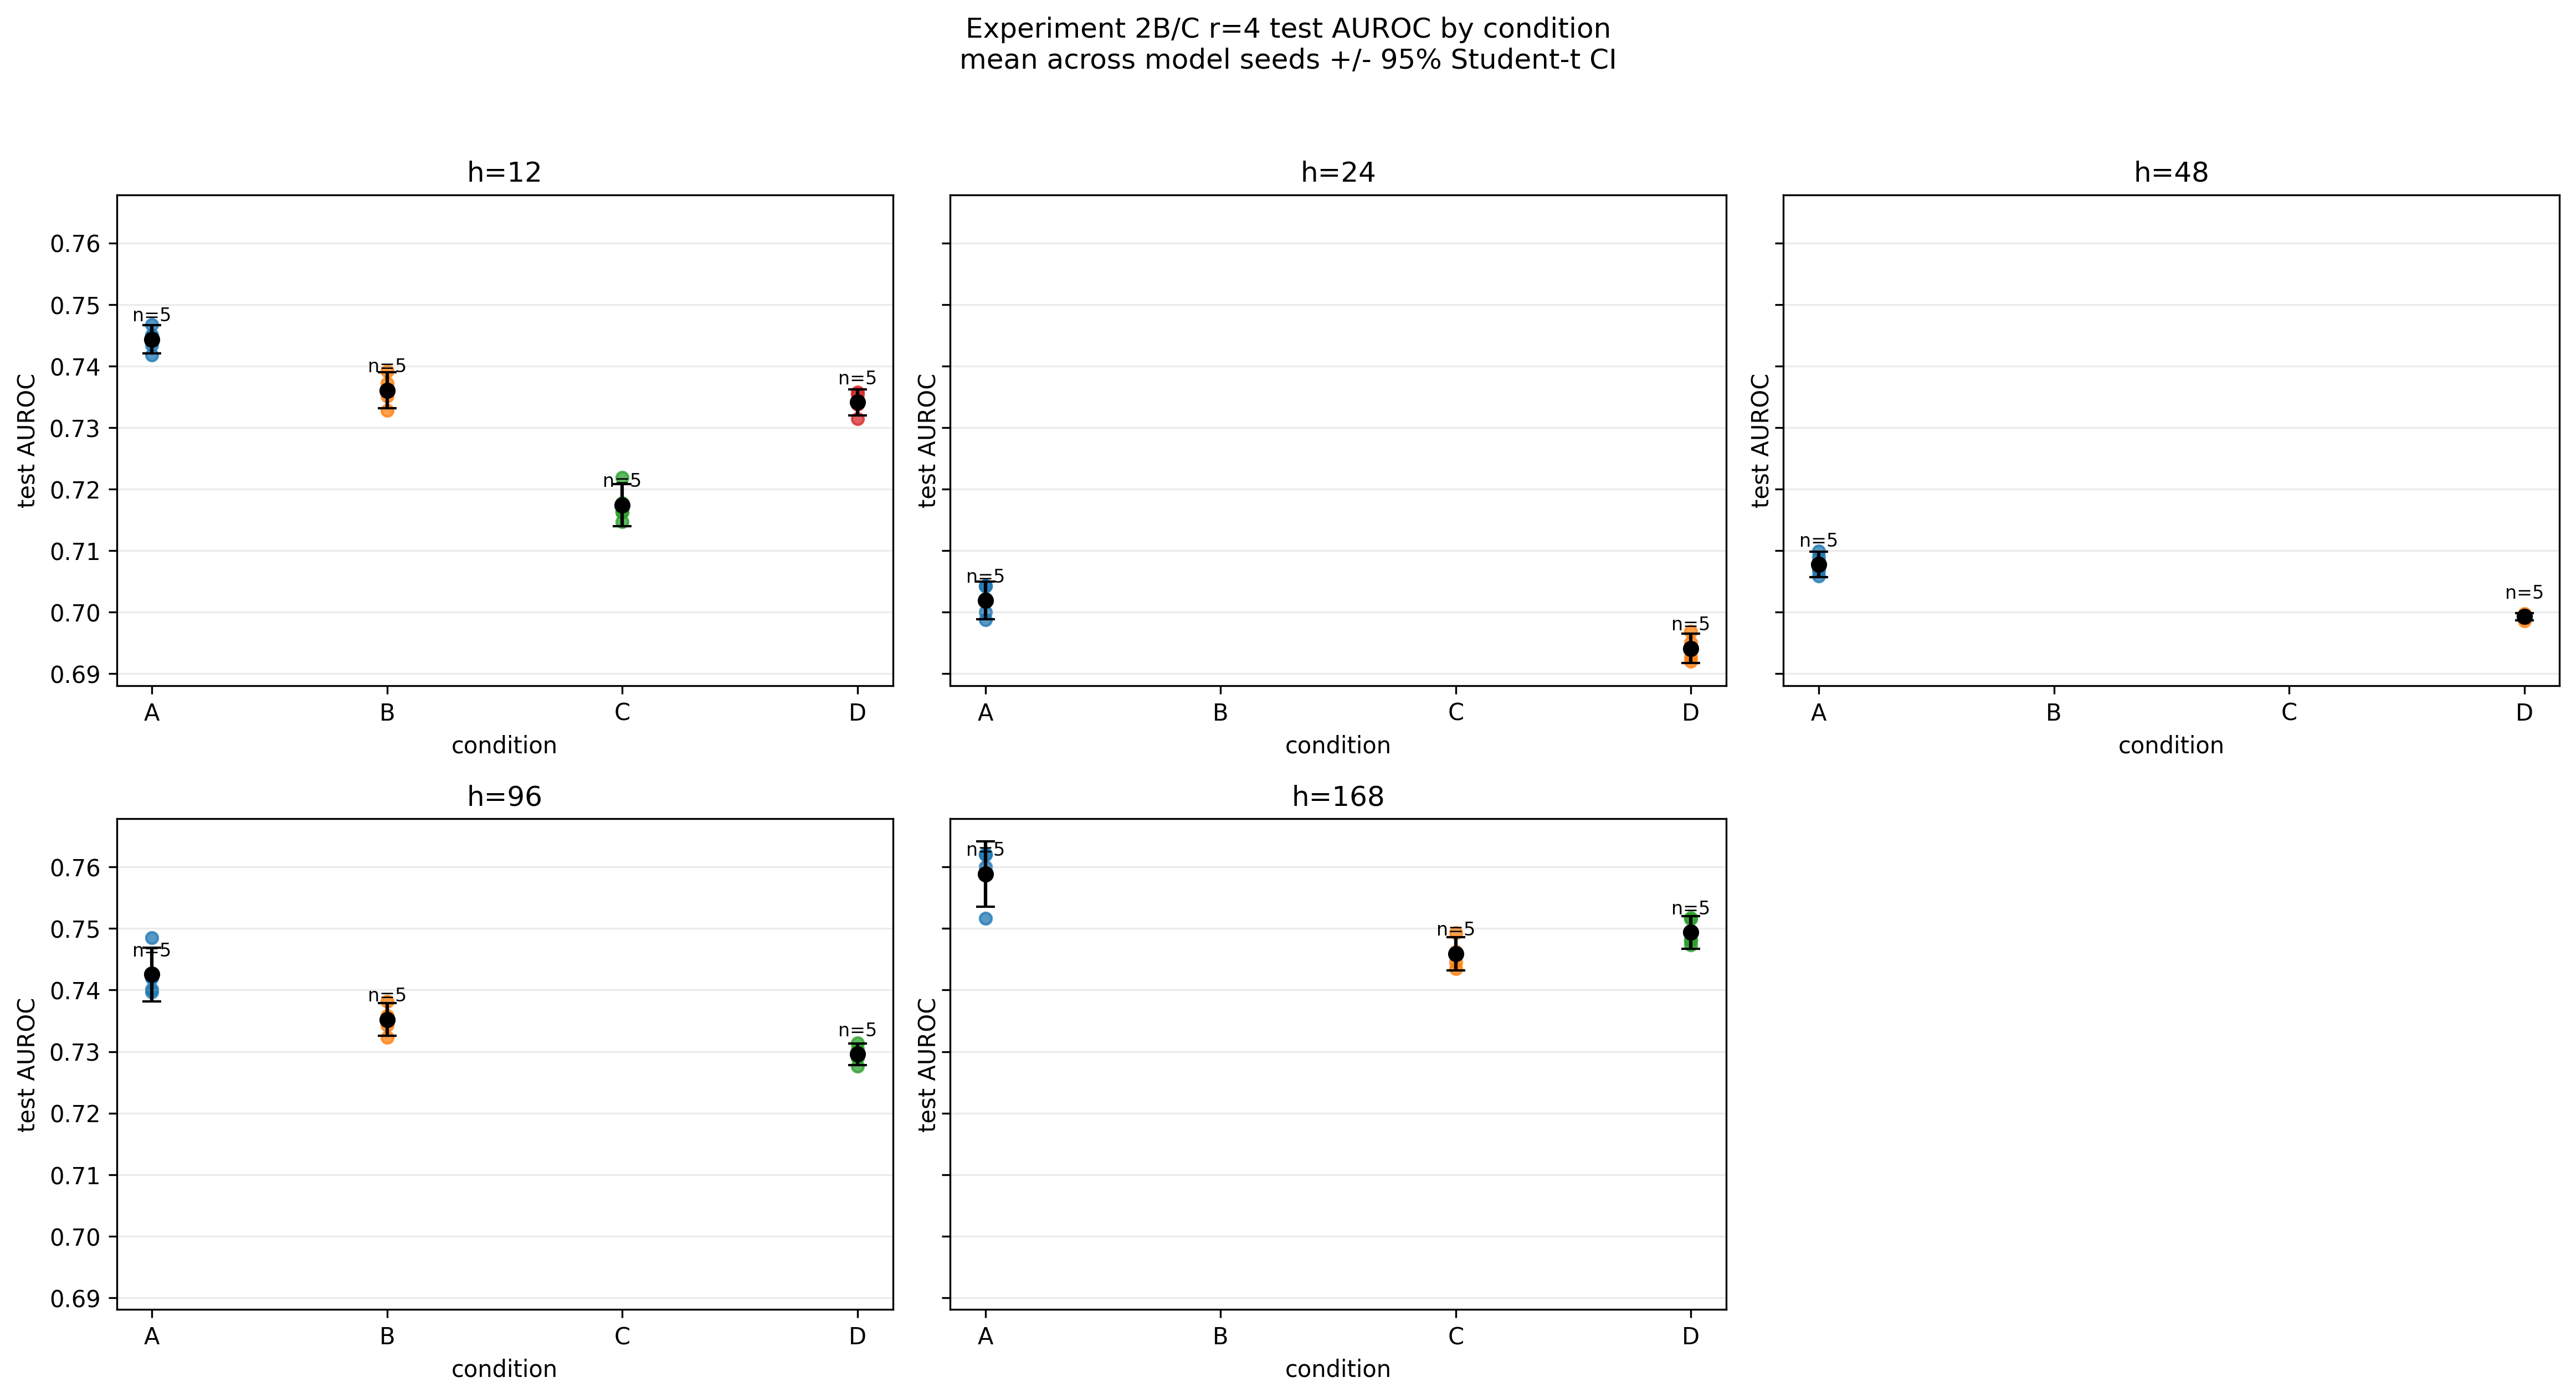


experiment2b_r4_test_auprc_by_condition_ci95.png


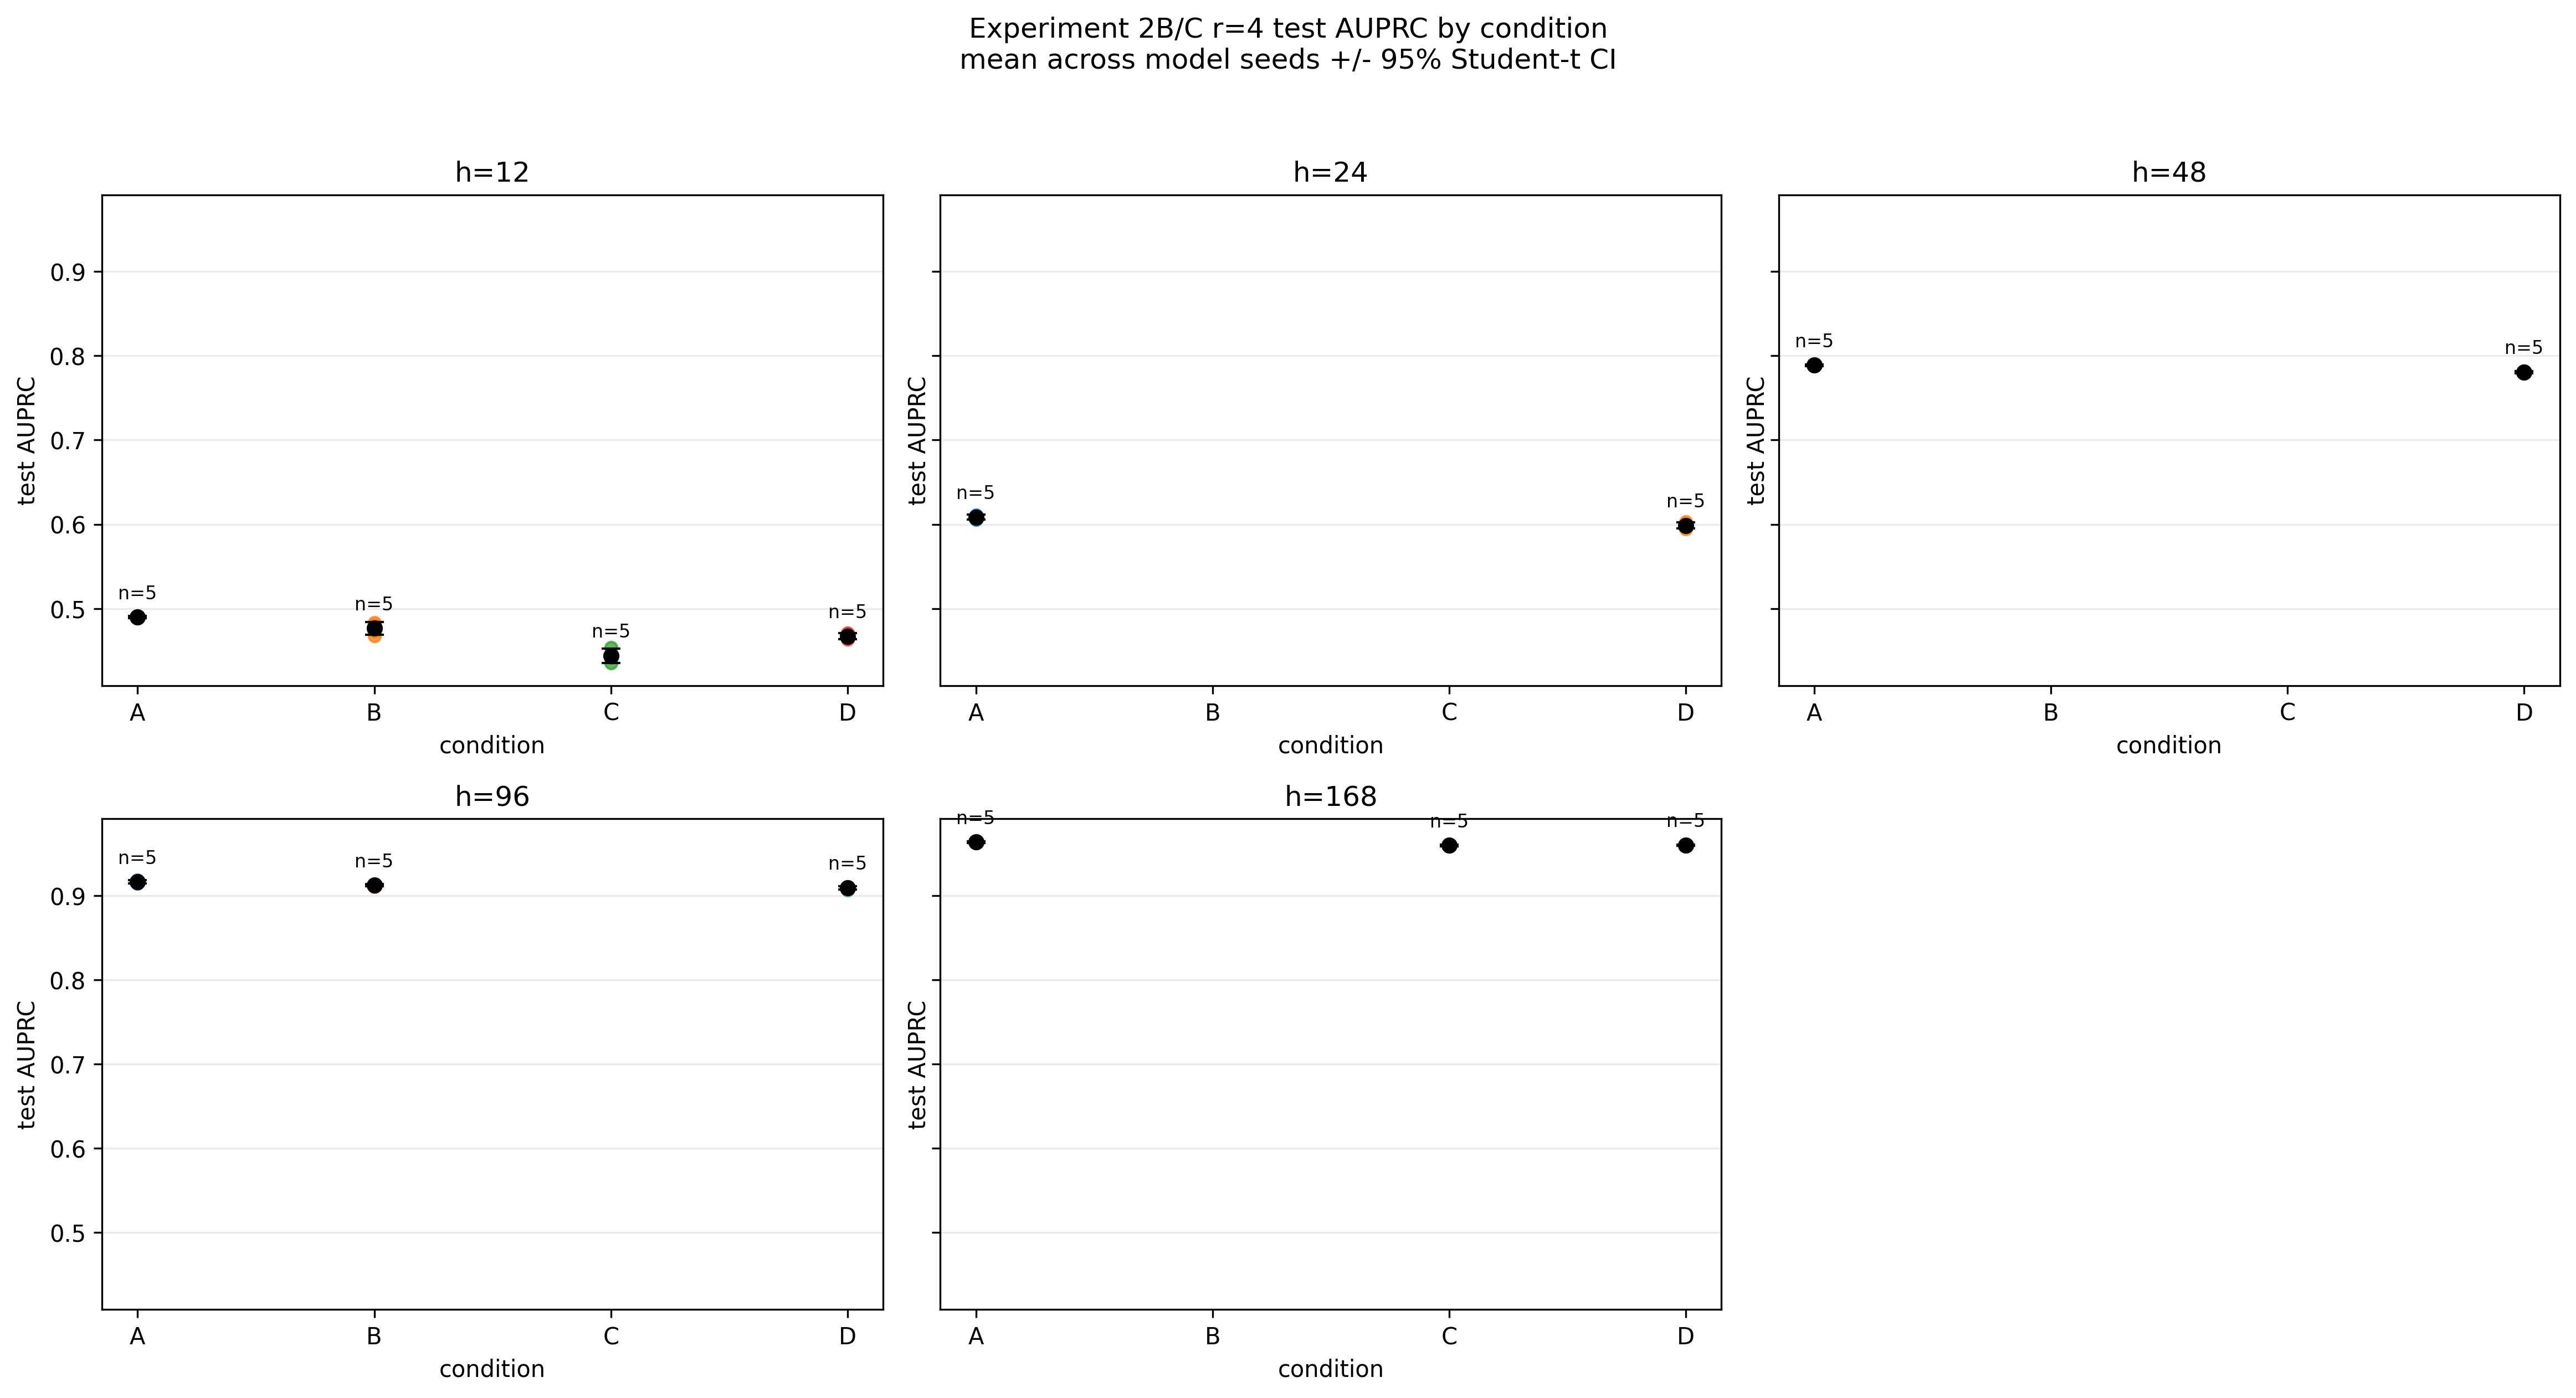


experiment2b_r4_test_brier_by_condition_ci95.png


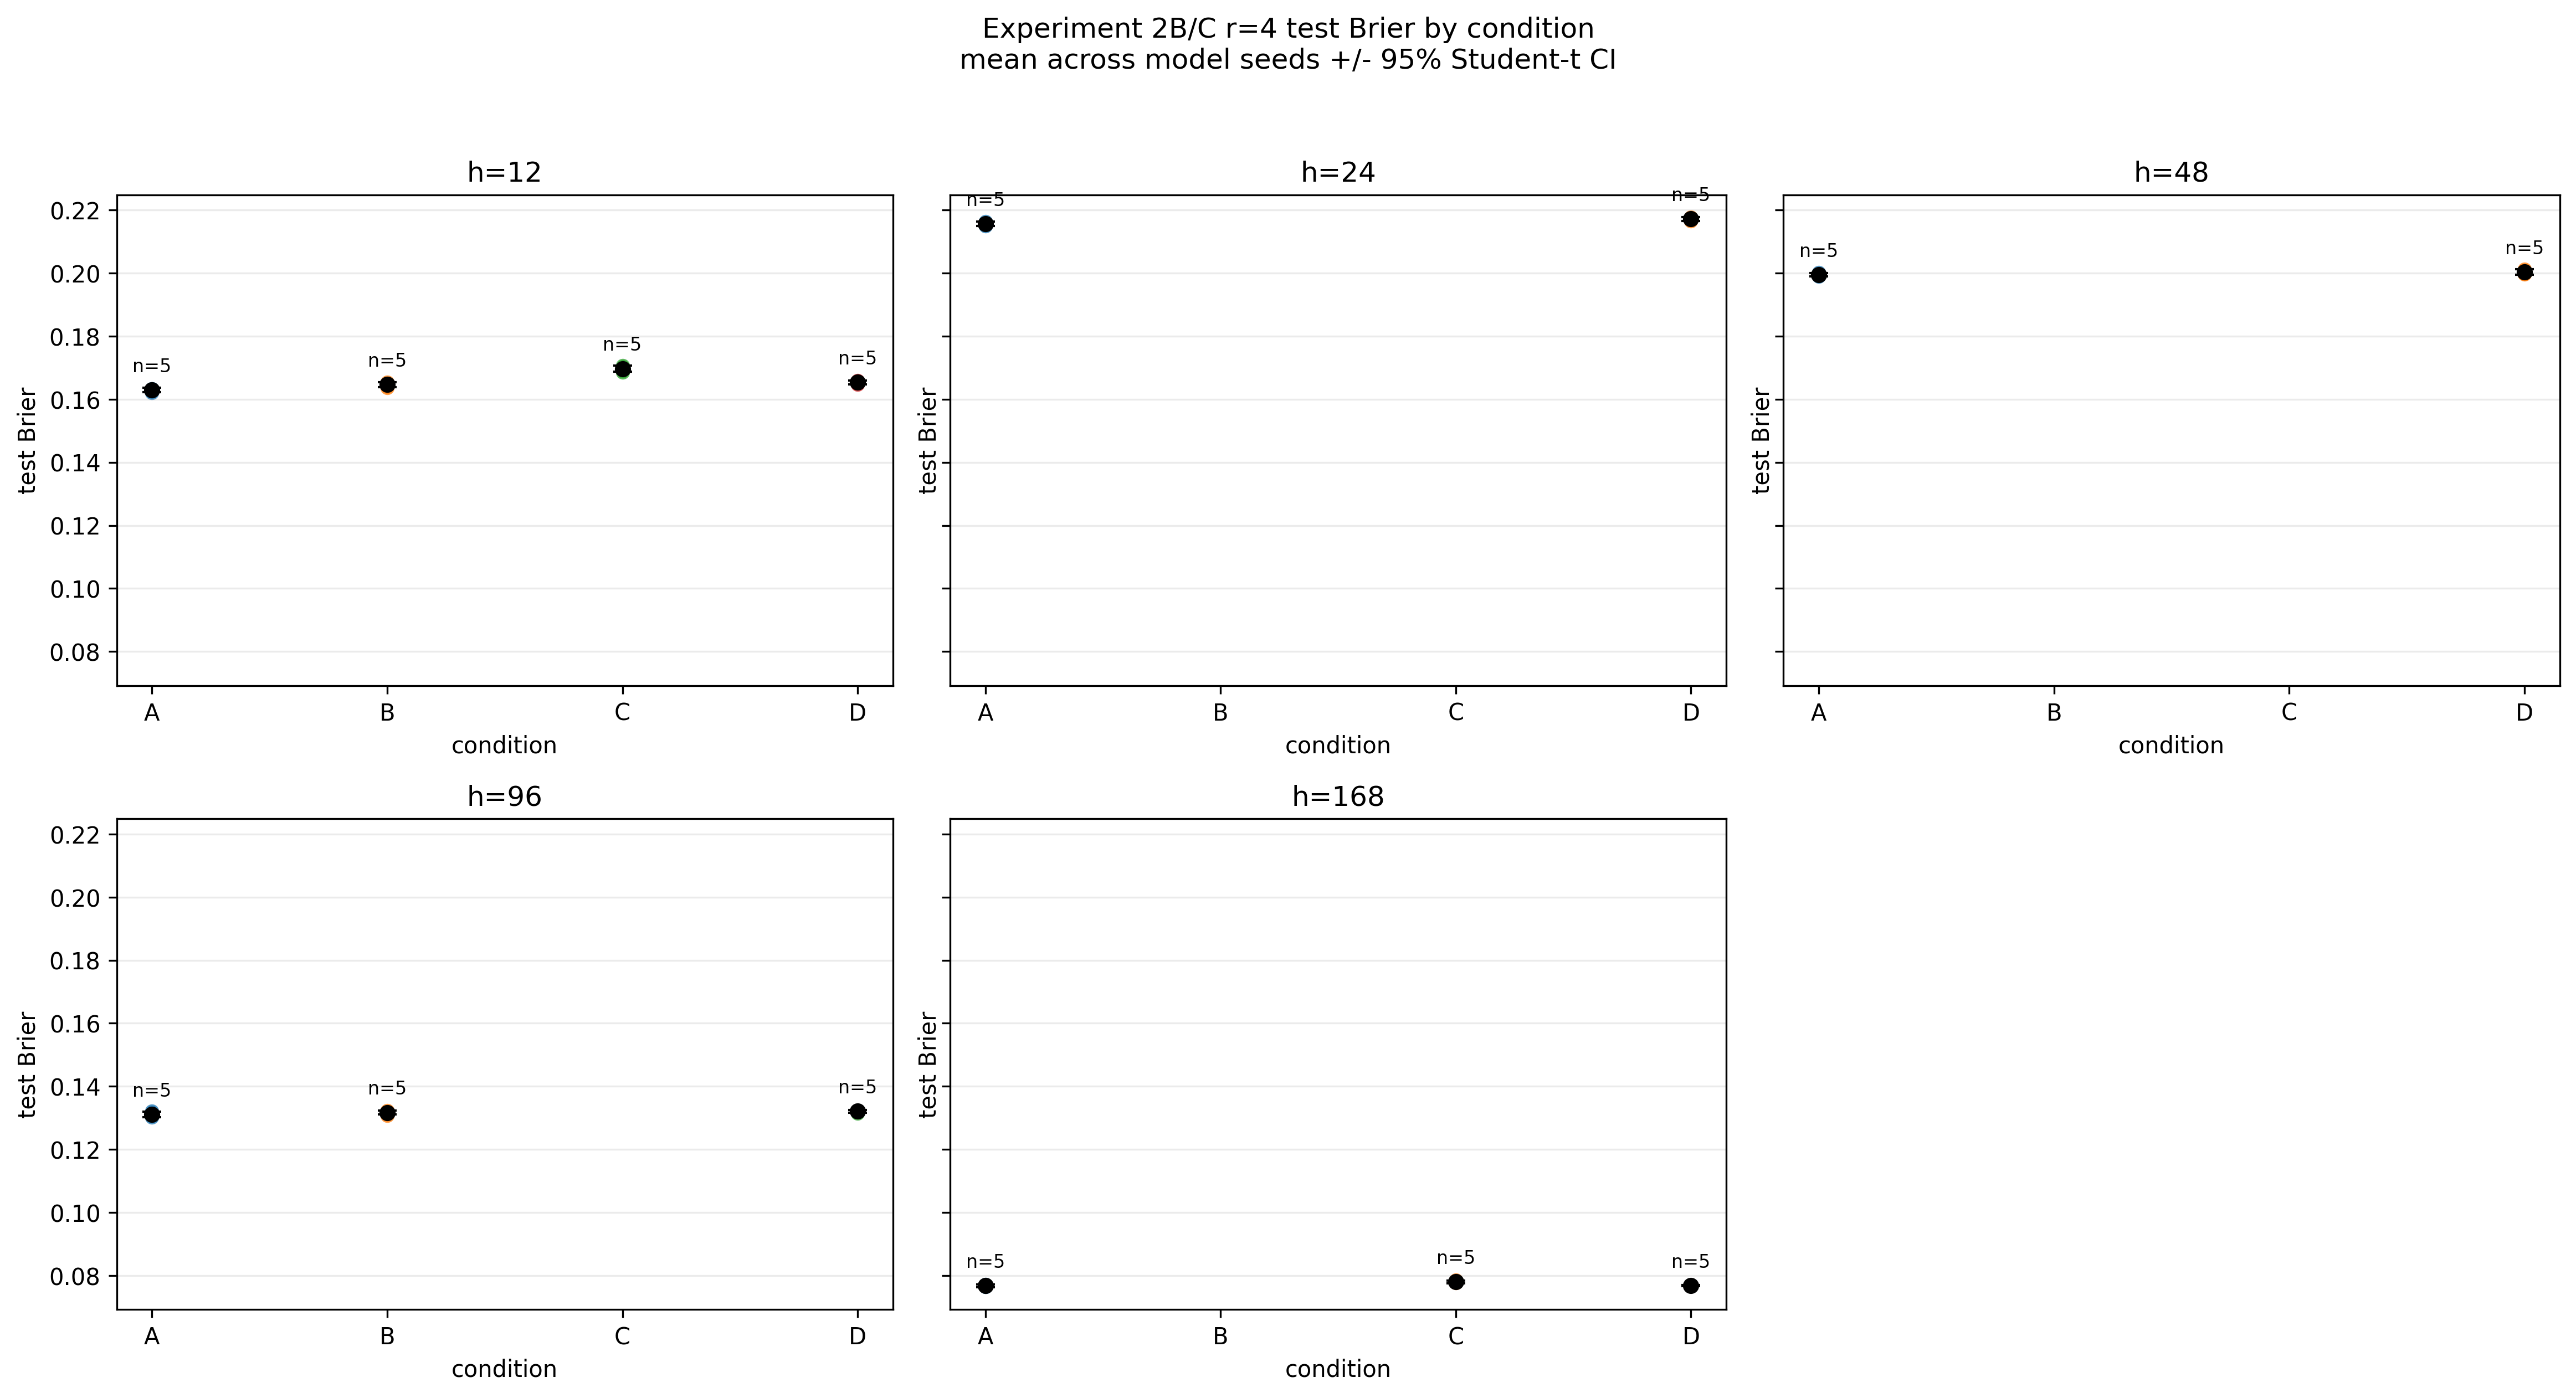

In [42]:
CONDITION_ORDER = ["A", "B", "C", "D"]

exp2b_cond = add_status(DATA["exp2b_condition_summary"])

show_table(
    "Exp2B/C A/B/C/D condition-level summary",
    exp2b_cond,
    [
        "horizon", "r", "condition", "metric",
        "mean", "sd", "sem", "ci95_low", "ci95_high",
        "n", "status",
    ],
    max_rows=300,
)

show_source_plot_group(
    "Exp2B/C source figures: condition-level performance",
    "exp2bc",
    FH_PLOTS,
    exp2b_condition_plot_filenames(),
)


**Contrast guide:** The contrast tables show seed-level paired patient-bootstrap contrasts and across-seed summaries. Positive means the left condition is better; for Brier, positive means lower Brier for the left/reference condition. Patient-bootstrap CIs and Student-t seed CIs must be read separately.



Exp2B/C mechanism contrasts: seed Student-t CI and paired patient-bootstrap CI


,horizon,r,contrast,left_condition,right_condition,primary,metric,mean_difference,sd_difference,sem_difference,seed_ci95_low,seed_ci95_high,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,missing_seeds,status
0,12,4,A_vs_B,A,B,True,auprc,0.013203,0.006339,0.002835,0.005332,0.021074,0.004001,0.022068,5,[],COMPLETE
1,12,4,A_vs_B,A,B,True,auroc,0.008288,0.002169,0.000970,0.005595,0.010981,0.003110,0.013538,5,[],COMPLETE
2,12,4,A_vs_B,A,B,True,brier,0.001713,0.000879,0.000393,0.000621,0.002805,0.000412,0.003080,5,[],COMPLETE
3,12,4,A_vs_D,A,D,False,auprc,0.022738,0.003622,0.001620,0.018241,0.027235,0.010617,0.034467,5,[],COMPLETE
4,12,4,A_vs_D,A,D,False,auroc,0.010243,0.002927,0.001309,0.006609,0.013878,0.003939,0.016798,5,[],COMPLETE
5,12,4,A_vs_D,A,D,False,brier,0.002396,0.000895,0.000400,0.001285,0.003507,0.000695,0.004052,5,[],COMPLETE
6,12,4,B_vs_C,B,C,True,auprc,0.032571,0.012317,0.005509,0.017277,0.047865,0.020863,0.045147,5,[],COMPLETE
7,12,4,B_vs_C,B,C,True,auroc,0.018655,0.003144,0.001406,0.014751,0.022559,0.012204,0.025047,5,[],COMPLETE
8,12,4,B_vs_C,B,C,True,brier,0.005064,0.001200,0.000537,0.003574,0.006555,0.003295,0.006818,5,[],COMPLETE
9,12,4,B_vs_D,B,D,True,auprc,0.009535,0.006699,0.002996,0.001217,0.017853,0.000240,0.018850,5,[],COMPLETE



Exp2B/C source figures: primary mechanism contrasts

experiment2b_r4_auprc_primary_contrasts_bootstrap_ci95.png


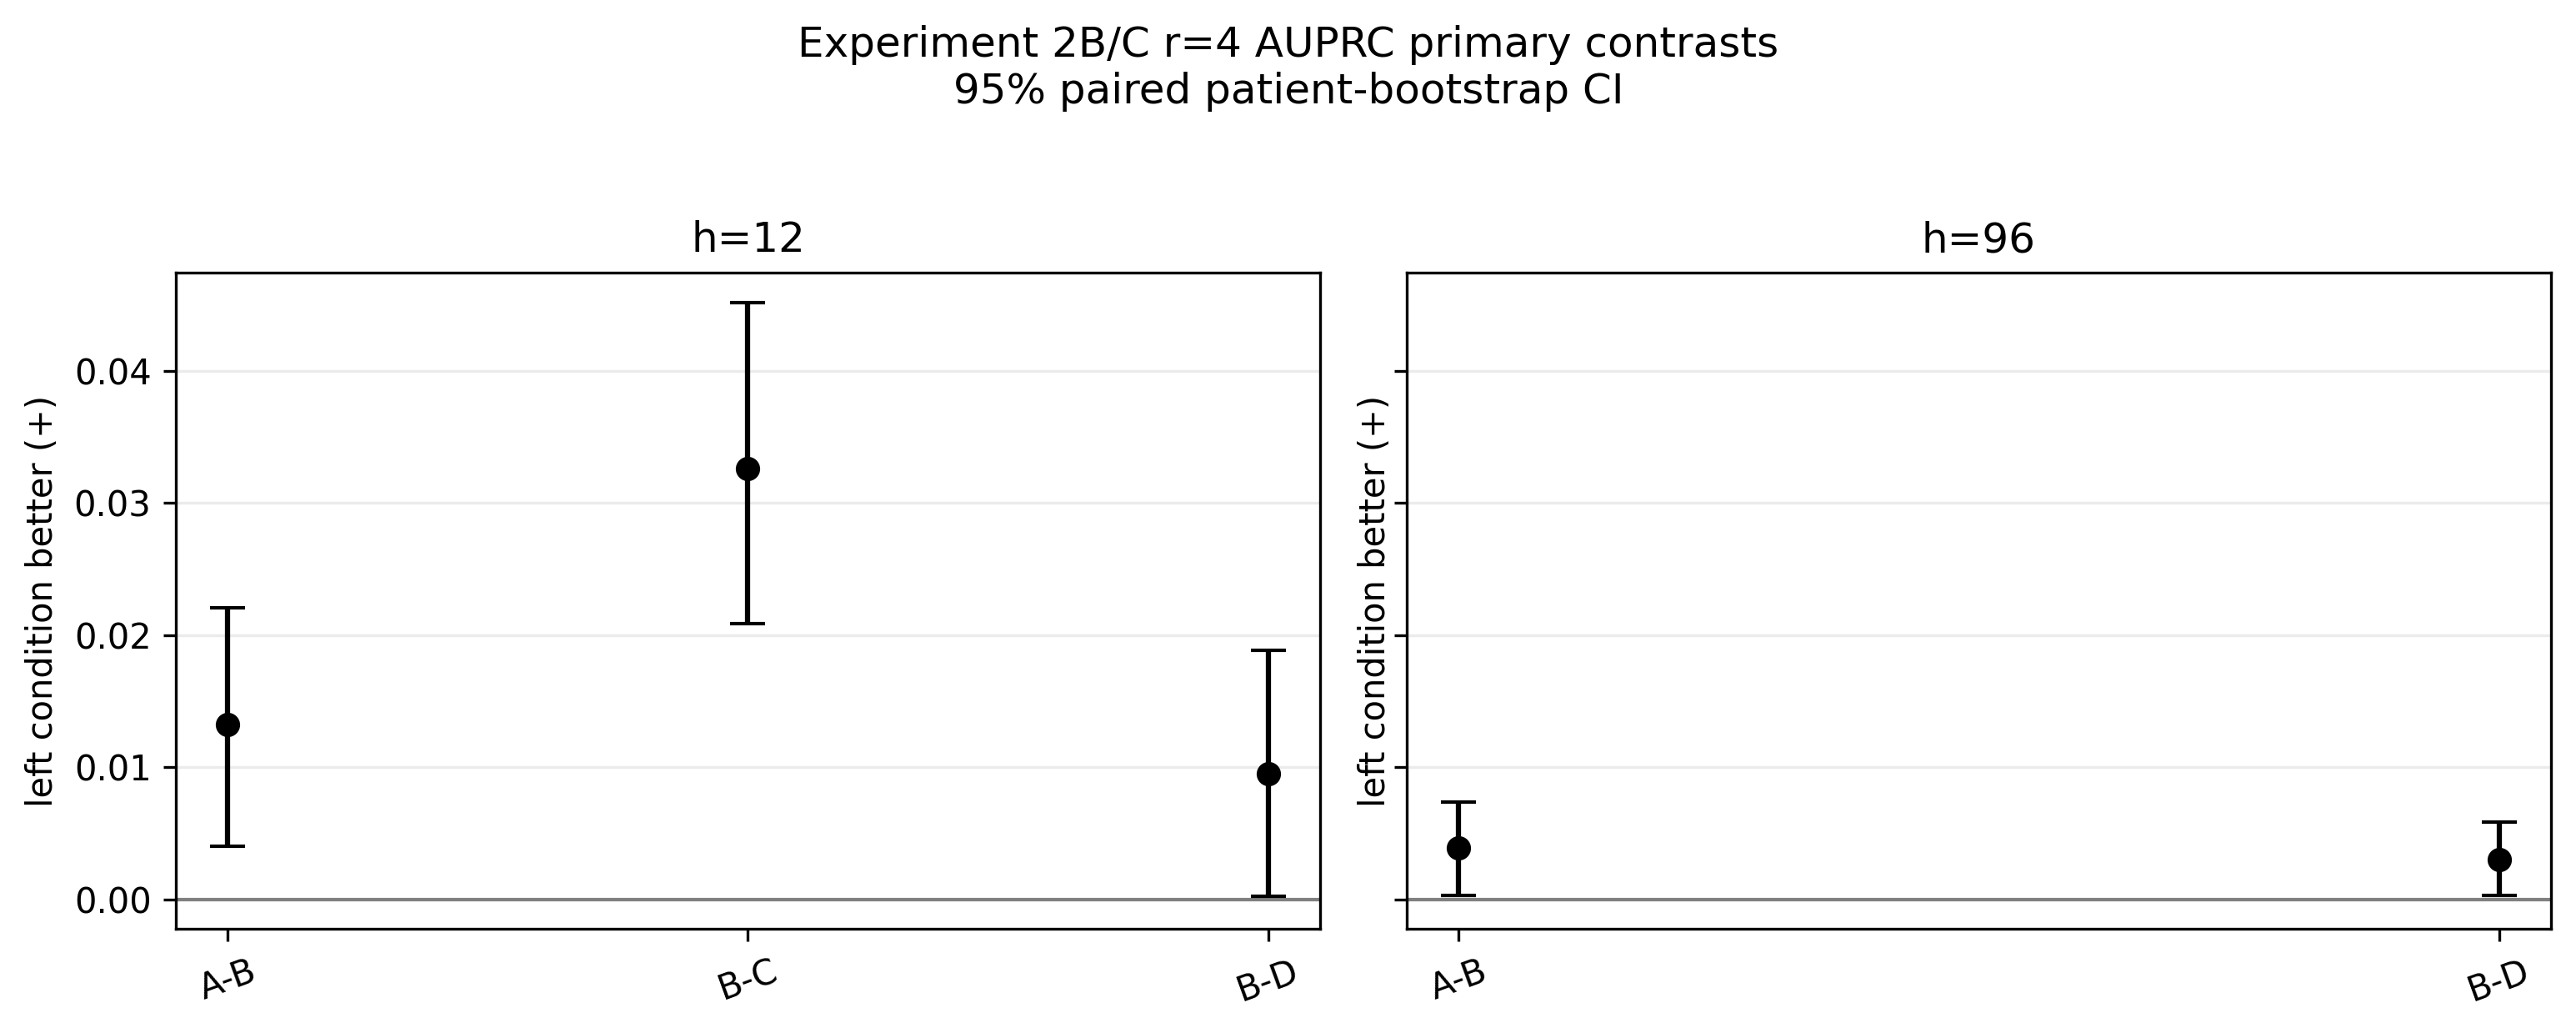


experiment2b_r4_auroc_primary_contrasts_bootstrap_ci95.png


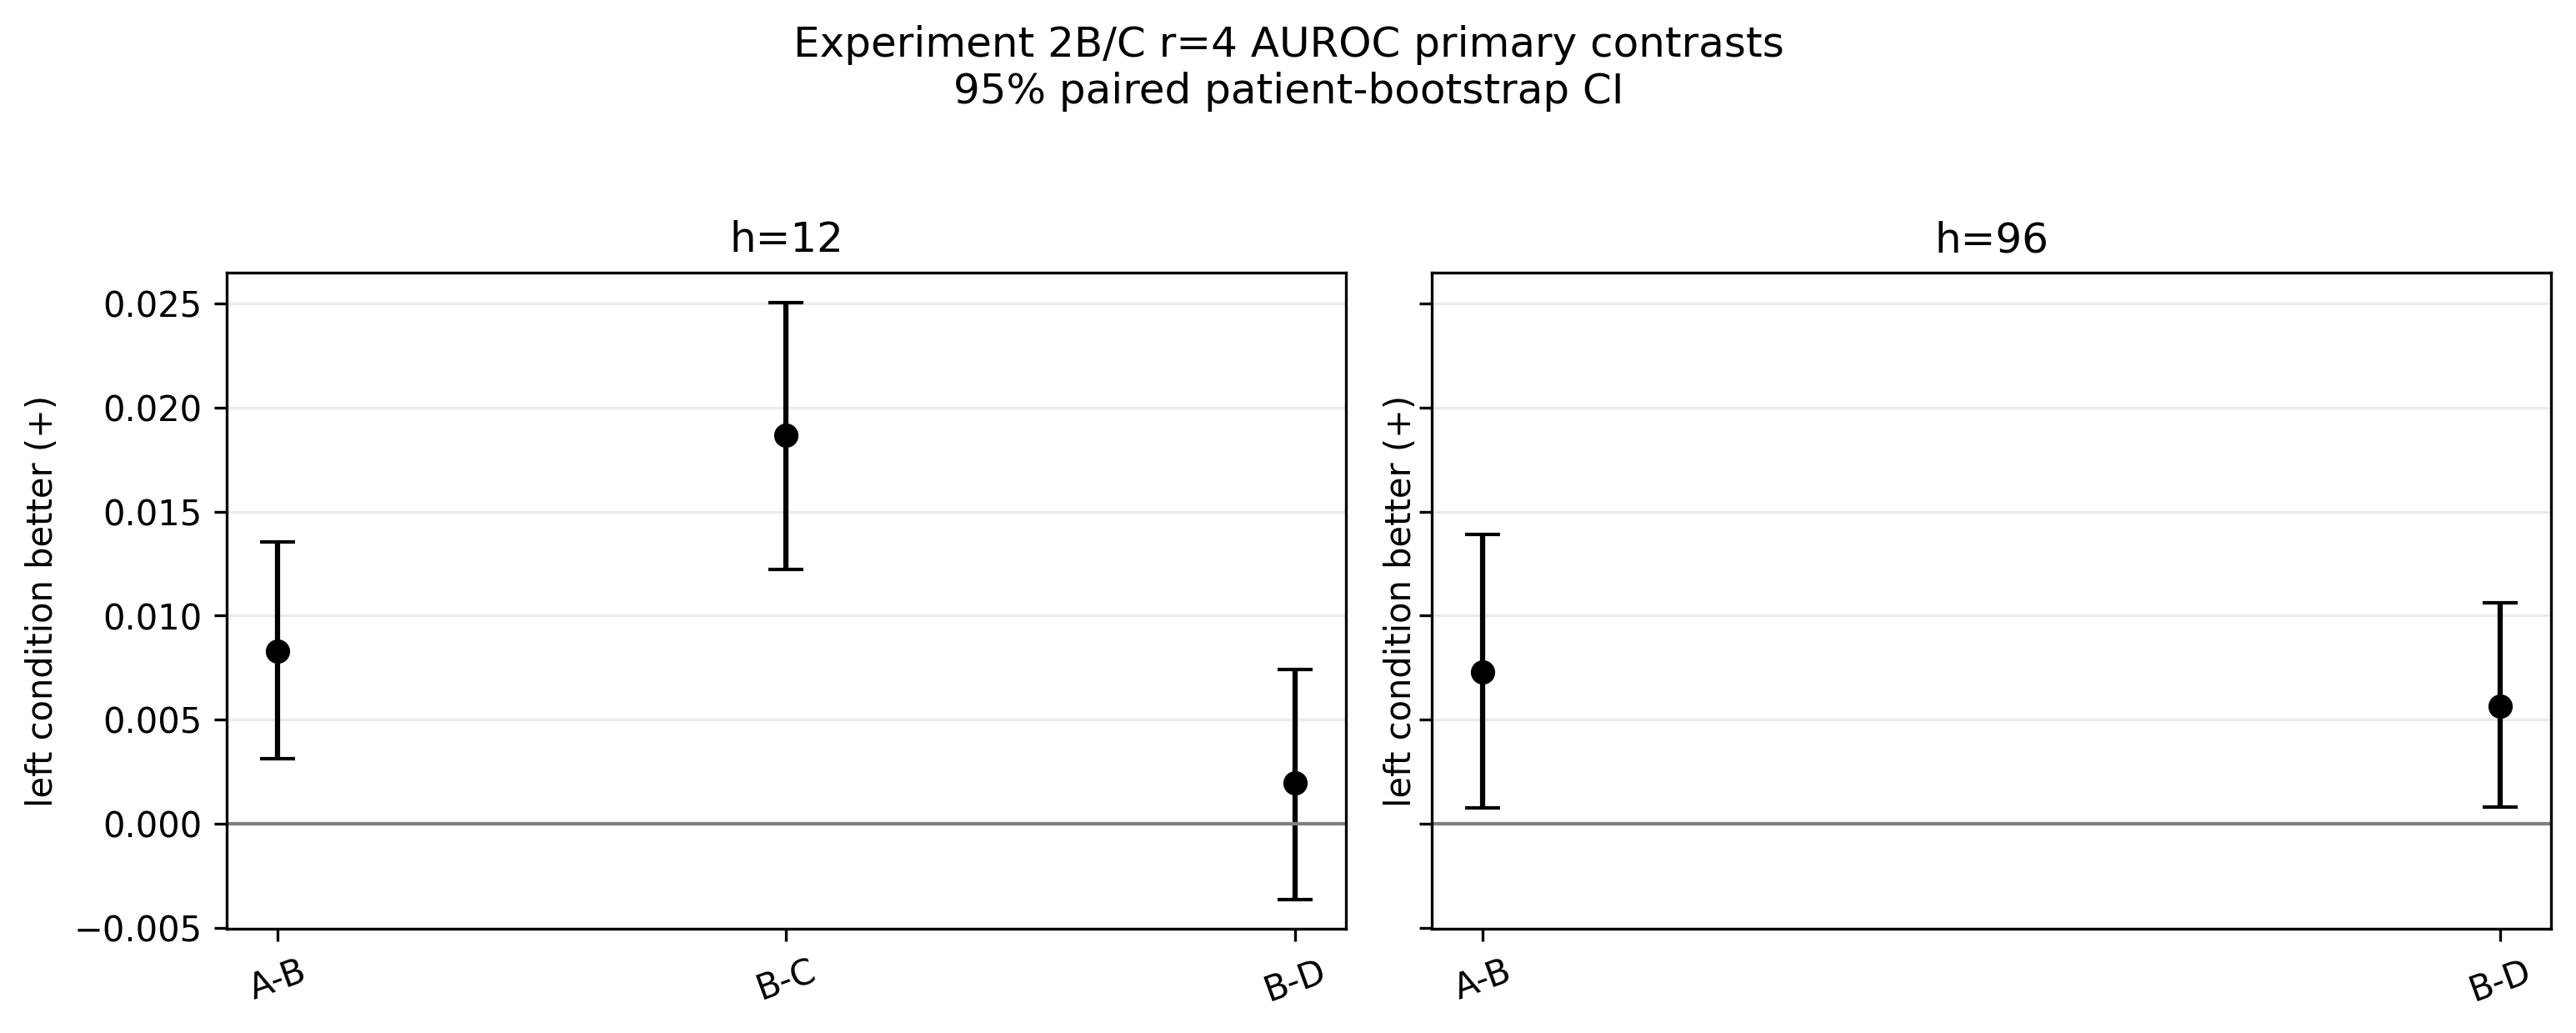


experiment2b_r4_brier_primary_contrasts_bootstrap_ci95.png


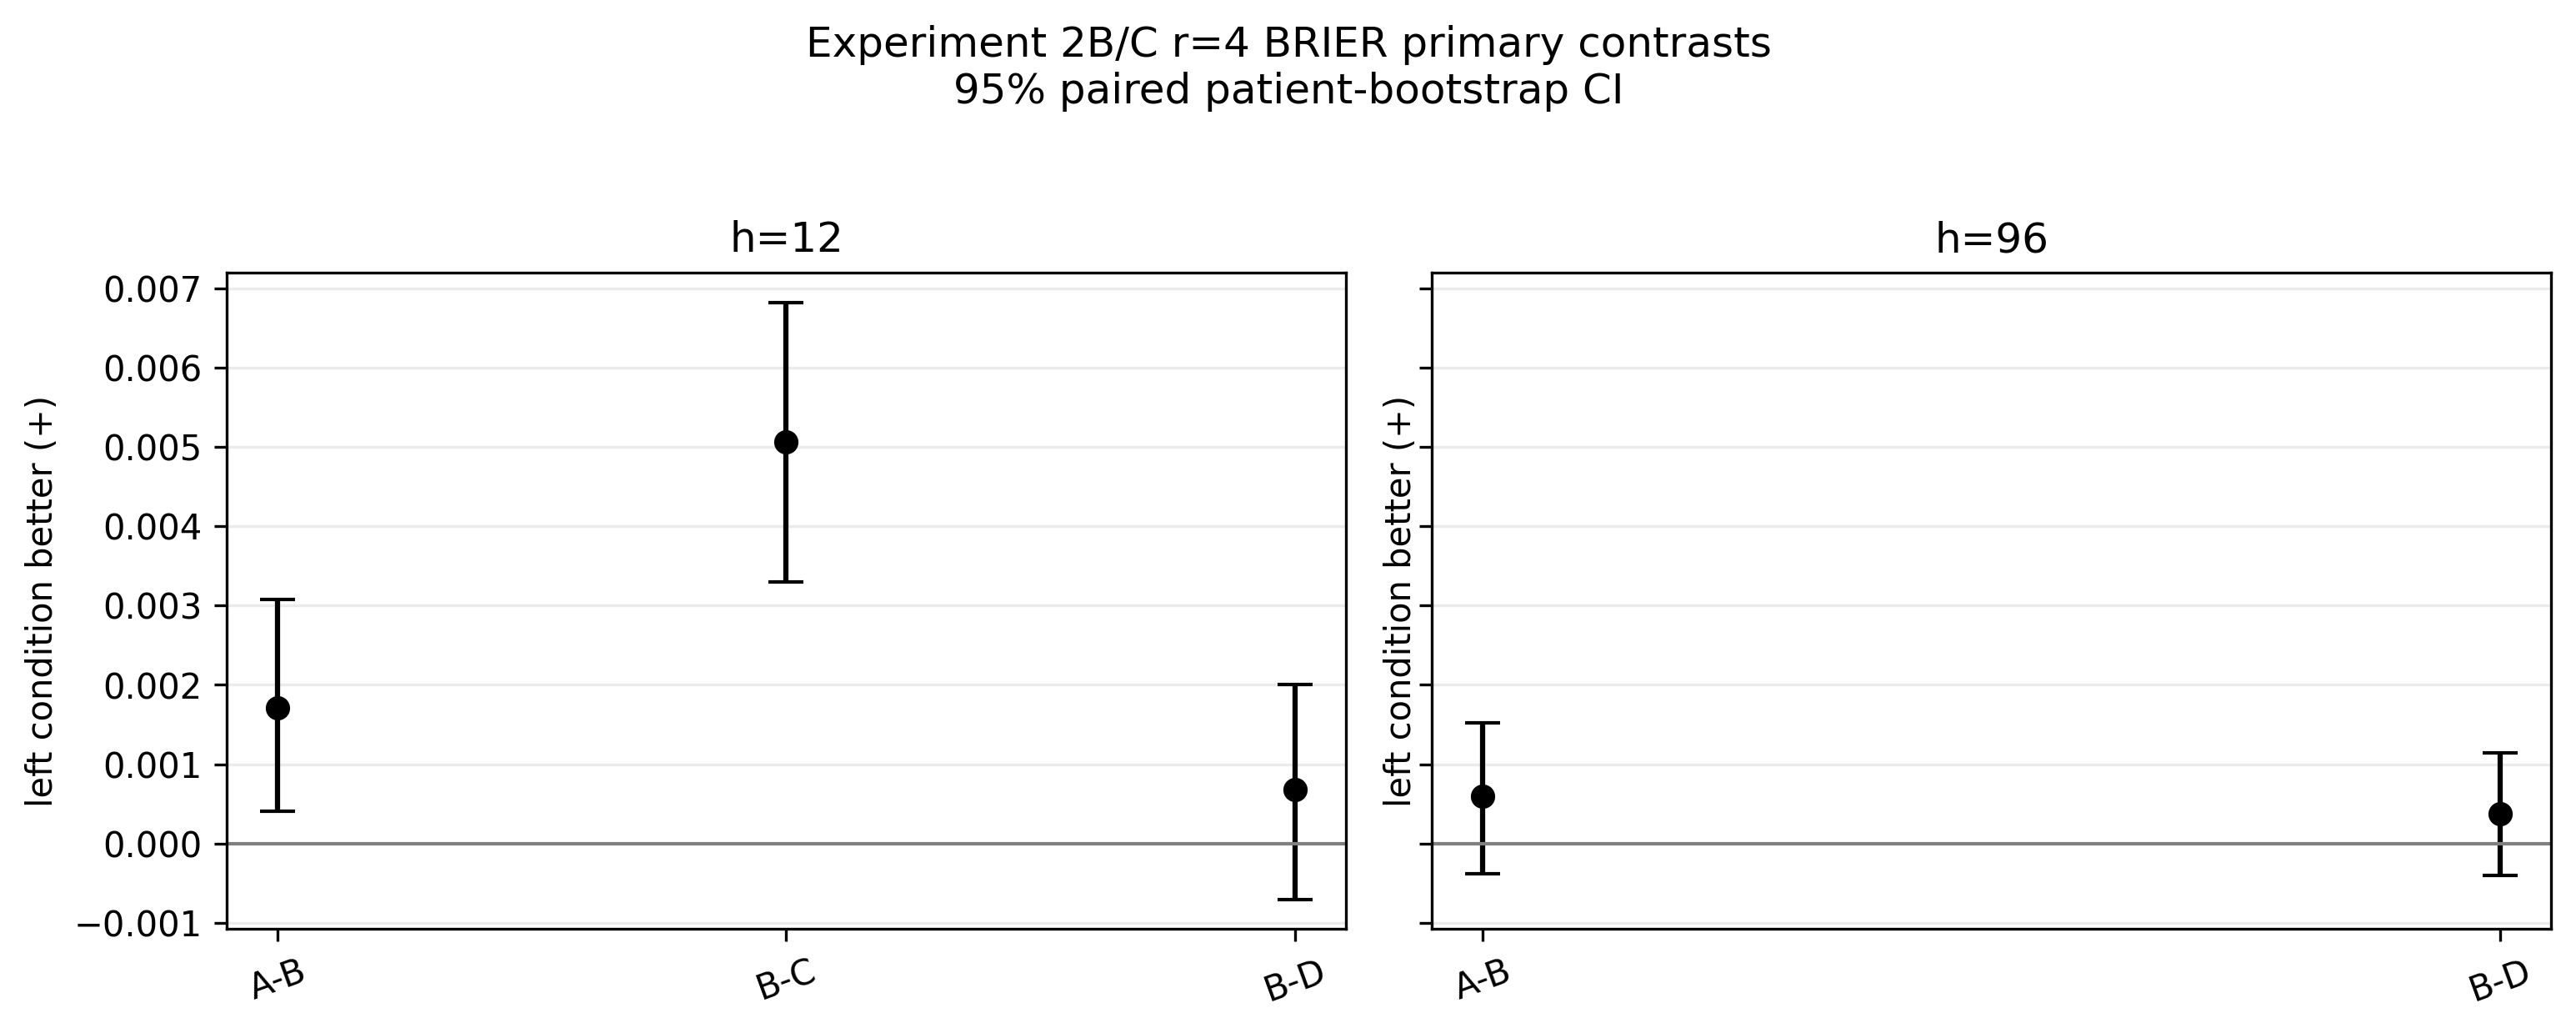

In [43]:
exp2b_contrasts = add_status(DATA["exp2b_across_seed_summary"], n_col="n_seeds")
show_table("Exp2B/C mechanism contrasts: seed Student-t CI and paired patient-bootstrap CI", exp2b_contrasts, ["horizon", "r", "contrast", "left_condition", "right_condition", "primary", "metric", "mean_difference", "sd_difference", "sem_difference", "seed_ci95_low", "seed_ci95_high", "patient_bootstrap_ci_low", "patient_bootstrap_ci_high", "n_seeds", "missing_seeds", "status"], max_rows=300)

show_source_plot_group(
    "Exp2B/C source figures: primary mechanism contrasts",
    "exp2bc",
    FH_PLOTS,
    exp2b_primary_contrast_plot_filenames(),
)


**Exp2C thinning-severity table:** This is the same A/B/C/D mechanism evaluated across available thinning severities. Increasing effect size with `r` suggests stronger sensitivity as measurements become less frequent. Flat or non-monotonic results are also valid and should remain visible. Positive means the left condition is better, with Brier sign already oriented appropriately by the source analysis.


In [44]:
exp2c_severity = exp2b_contrasts.copy()
if len(exp2c_severity):
    exp2c_severity = exp2c_severity.sort_values(["horizon", "r", "contrast", "metric"]).reset_index(drop=True)
show_table("Exp2C thinning-severity mechanism table", exp2c_severity, ["horizon", "r", "contrast", "left_condition", "right_condition", "metric", "mean_difference", "seed_ci95_low", "seed_ci95_high", "patient_bootstrap_ci_low", "patient_bootstrap_ci_high", "n_seeds", "missing_seeds", "status"], max_rows=300)

show_source_plot_group(
    "Exp2C source figures: mechanism severity across r",
    "exp2bc",
    FH_PLOTS,
    exp2c_severity_plot_filenames(),
)



Exp2C thinning-severity mechanism table


,horizon,r,contrast,left_condition,right_condition,metric,mean_difference,seed_ci95_low,seed_ci95_high,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,missing_seeds,status
0,12,4,A_vs_B,A,B,auprc,0.013203,0.005332,0.021074,0.004001,0.022068,5,[],COMPLETE
1,12,4,A_vs_B,A,B,auroc,0.008288,0.005595,0.010981,0.003110,0.013538,5,[],COMPLETE
2,12,4,A_vs_B,A,B,brier,0.001713,0.000621,0.002805,0.000412,0.003080,5,[],COMPLETE
3,12,4,A_vs_D,A,D,auprc,0.022738,0.018241,0.027235,0.010617,0.034467,5,[],COMPLETE
4,12,4,A_vs_D,A,D,auroc,0.010243,0.006609,0.013878,0.003939,0.016798,5,[],COMPLETE
5,12,4,A_vs_D,A,D,brier,0.002396,0.001285,0.003507,0.000695,0.004052,5,[],COMPLETE
6,12,4,B_vs_C,B,C,auprc,0.032571,0.017277,0.047865,0.020863,0.045147,5,[],COMPLETE
7,12,4,B_vs_C,B,C,auroc,0.018655,0.014751,0.022559,0.012204,0.025047,5,[],COMPLETE
8,12,4,B_vs_C,B,C,brier,0.005064,0.003574,0.006555,0.003295,0.006818,5,[],COMPLETE
9,12,4,B_vs_D,B,D,auprc,0.009535,0.001217,0.017853,0.000240,0.018850,5,[],COMPLETE



Exp2C source figures: mechanism severity across r
NOT AVAILABLE


## 5-11. Experiment 3 LSTM - Observation-Frequency Distribution Shift

### Scientific Question
How much predictive performance is lost under train–test observation-frequency mismatch, and how much is recovered by training on data with the same observation frequency as deployment? Is this effect robust to normalization, thinning mechanism, prediction horizon, and temporal representation?

### Experimental Design
Model: LSTM. 

Task: fixed-horizon ICU outcome. 

- Exp3A. Structured observation-frequency shift: h=12, r={4,8}. Compare (train on dense, test on sparse) vs (train on sparse, test on sparse). Dense = standard 1h discretization; sparse = structured thinning every \(r\) hours while keeping the 1h grid.
- Exp3B. Normalizer control: h=12, r=4. (sparse train + sparse test + sparse normalizer) vs (sparse train + sparse test + dense normalizer).
- Exp3C. Random-matched observation-frequency shift: h=12, r=4. Compare (train on dense, test on random-sparse) vs (train on random-sparse, test on random-sparse). Random-sparse randomly retains observations while matching the structured-r4 observation counts.
- Exp3D. Longer-horizon replication: h=96, r=4. Repeat Exp3A at a longer horizon.
- Exp3E. Raw-representation frequency shift: h=12, r={4,8}. Repeat the same mismatch comparison using the raw representation instead of the 1h-discretized representation: (train on raw dense, test on raw sparse) vs (train on raw sparse, test on raw sparse).

### Quantity Being Measured
Absolute performance is condition-level AUPRC/AUROC/Brier by train regime, test regime, horizon, r, and normalizer regime. Main shift recovery for AUPRC/AUROC is `M(matched sparse -> sparse) - M(dense -> sparse)`. For Brier, the source uses `Brier(dense -> sparse) - Brier(matched sparse -> sparse)`, so positive consistently means improvement from matching the training observation regime.

### Why This Comparison Is Informative
It separates information loss at deployment from train/test observation-regime mismatch. The normalizer control asks whether normalization statistics explain the effect. Random matched thinning asks whether the mismatch persists without periodic structure. The h=96 replication links to Exp2A. Raw/grid analyses ask whether the fixed grid amplifies sensitivity.

### Expected Evidence
Positive mismatch recovery suggests matched sparse training improves sparse deployment performance. Little normalizer-control difference suggests normalizer choice alone does not explain recovery. Structured-vs-random and r4-vs-r8 comparisons describe whether temporal pattern and severity matter. Grid-minus-raw above zero suggests the fixed grid amplifies the shift penalty.

### Caveats
A difference between regimes does not prove universal model robustness. LSTM Exp3 exports may be partial or unavailable if the source notebook run was interrupted. Do not call partial results final.


**Absolute performance guide:** These are raw condition-level test metrics summarized across seeds with Student-t CIs. Brier is lower-is-better in absolute tables. `status` flags partial seed availability. No patient-bootstrap interval is shown in this absolute table.


**Exp3A input-information characterization:** `r=8` first appears in Experiment 3A, so the dense/r4/r8 retained-information table is shown here. Sequence length remains a fixed 1h-grid sanity check, not an information-content metric.


In [ ]:
exp3a_input_information_cols = [
    "condition", "r", "n_stays",
    "mean_token_count", "median_token_count", "p25_token_count", "p75_token_count", "p95_token_count",
    "mean_token_retained_fraction", "median_token_retained_fraction",
    "mean_occupied_1h_bins", "median_occupied_1h_bins",
    "mean_channels_observed", "median_channels_observed",
    "post_discretization_sequence_length",
]
show_table(
    "Exp3A input-information characterization: dense vs structured r=4/r=8",
    DATA["exp3a_input_information_summary"],
    exp3a_input_information_cols,
    max_rows=20,
)


In [45]:
exp3_abs = add_status(DATA["exp3_lstm_absolute_summary"])
show_table("Experiment 3 LSTM absolute performance", exp3_abs, ["experiment", "horizon", "target_r", "condition", "normalizer_regime", "metric", "mean", "sd", "sem", "ci95_low", "ci95_high", "n", "status"], max_rows=300)



Experiment 3 LSTM absolute performance


,experiment,horizon,target_r,condition,normalizer_regime,metric,mean,sd,sem,ci95_low,ci95_high,n,status
0,Exp3A Structured frequency shift,12,1,dense->dense,train_matched,test_auroc,0.744341,0.001849,0.000827,0.742045,0.746637,5,COMPLETE
1,Exp3A Structured frequency shift,12,4,dense->structured-r4,train_matched,test_auroc,0.679189,0.010704,0.004787,0.665897,0.692480,5,COMPLETE
2,Exp3A Structured frequency shift,12,4,structured-r4->structured-r4,train_matched,test_auroc,0.736053,0.002377,0.001063,0.733102,0.739004,5,COMPLETE
3,Exp3A Structured frequency shift,12,8,dense->structured-r8,train_matched,test_auroc,0.651799,0.004316,0.001930,0.646440,0.657157,5,COMPLETE
4,Exp3A Structured frequency shift,12,8,structured-r8->structured-r8,train_matched,test_auroc,0.719811,0.003929,0.001757,0.714932,0.724689,5,COMPLETE
5,Exp3B Normalizer control,12,4,structured-r4 train + dense norm,dense,test_auroc,0.735366,0.001682,0.000752,0.733278,0.737454,5,COMPLETE
6,Exp3B Normalizer control,12,4,structured-r4 train + train-matched norm,train_matched,test_auroc,0.736053,0.002377,0.001063,0.733102,0.739004,5,COMPLETE
7,Exp3C Random-matched frequency shift,12,4,dense->random-r4,train_matched,test_auroc,0.698035,0.006319,0.002826,0.690190,0.705880,5,COMPLETE
8,Exp3C Random-matched frequency shift,12,4,random-r4->random-r4,train_matched,test_auroc,0.717398,0.002744,0.001227,0.713990,0.720806,5,COMPLETE
9,Exp3D Horizon replication,96,4,dense->structured-r4,train_matched,test_auroc,0.711905,0.005184,0.002318,0.705467,0.718342,5,COMPLETE


**Exp3A-D contrast guide:** The following tables come directly from the source LSTM summaries. Positive values mean the left/matched condition performs better. `seed_ci95_*` is a Student-t CI across model seeds. `patient_bootstrap_ci_*` is a paired patient-level bootstrap CI. Both are shown when exported.



Exp3A LSTM structured shift recovery


,experiment,contrast,horizon,r,metric,left_condition,right_condition,mean_difference,sd_difference,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,expected_seeds,status
0,Exp3A Structured frequency shift,structured shift,12,4,auprc,structured-r4->structured-r4,dense->structured-r4,0.078936,0.014574,0.060167,0.098623,5,5,COMPLETE
1,Exp3A Structured frequency shift,structured shift,12,4,auroc,structured-r4->structured-r4,dense->structured-r4,0.056864,0.011505,0.046936,0.067177,5,5,COMPLETE
2,Exp3A Structured frequency shift,structured shift,12,4,brier,structured-r4->structured-r4,dense->structured-r4,0.015694,0.004161,0.012661,0.018801,5,5,COMPLETE
3,Exp3A Structured frequency shift,structured shift,12,8,auprc,structured-r8->structured-r8,dense->structured-r8,0.078472,0.011074,0.057254,0.099748,5,5,COMPLETE
4,Exp3A Structured frequency shift,structured shift,12,8,auroc,structured-r8->structured-r8,dense->structured-r8,0.068012,0.007583,0.056095,0.079762,5,5,COMPLETE
5,Exp3A Structured frequency shift,structured shift,12,8,brier,structured-r8->structured-r8,dense->structured-r8,0.017375,0.002610,0.013776,0.020714,5,5,COMPLETE



Exp3B LSTM normalizer control


,experiment,contrast,horizon,r,metric,left_condition,right_condition,mean_difference,sd_difference,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,expected_seeds,status
0,Exp3B Normalizer control,normalizer control,12,4,auprc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.001430,0.005848,-0.004415,0.006905,5,5,COMPLETE
1,Exp3B Normalizer control,normalizer control,12,4,auroc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.000687,0.002590,-0.002889,0.004003,5,5,COMPLETE
2,Exp3B Normalizer control,normalizer control,12,4,brier,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.000508,0.000770,-0.000435,0.001370,5,5,COMPLETE



Exp3C LSTM random matched-count shift


...


Exp3 combined key-contrast summary


,experiment,contrast,horizon,r,metric,left_condition,right_condition,mean_difference,sd_difference,patient_bootstrap_ci_low,patient_bootstrap_ci_high,n_seeds,expected_seeds,status
0,Exp3A Structured frequency shift,structured shift,12,4,auprc,structured-r4->structured-r4,dense->structured-r4,0.078936,0.014574,0.060167,0.098623,5,5,COMPLETE
1,Exp3A Structured frequency shift,structured shift,12,4,auroc,structured-r4->structured-r4,dense->structured-r4,0.056864,0.011505,0.046936,0.067177,5,5,COMPLETE
2,Exp3A Structured frequency shift,structured shift,12,4,brier,structured-r4->structured-r4,dense->structured-r4,0.015694,0.004161,0.012661,0.018801,5,5,COMPLETE
3,Exp3A Structured frequency shift,structured shift,12,8,auprc,structured-r8->structured-r8,dense->structured-r8,0.078472,0.011074,0.057254,0.099748,5,5,COMPLETE
4,Exp3A Structured frequency shift,structured shift,12,8,auroc,structured-r8->structured-r8,dense->structured-r8,0.068012,0.007583,0.056095,0.079762,5,5,COMPLETE
5,Exp3A Structured frequency shift,structured shift,12,8,brier,structured-r8->structured-r8,dense->structured-r8,0.017375,0.002610,0.013776,0.020714,5,5,COMPLETE
6,Exp3B Normalizer control,normalizer control,12,4,auprc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.001430,0.005848,-0.004415,0.006905,5,5,COMPLETE
7,Exp3B Normalizer control,normalizer control,12,4,auroc,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.000687,0.002590,-0.002889,0.004003,5,5,COMPLETE
8,Exp3B Normalizer control,normalizer control,12,4,brier,structured-r4 train + train-matched norm,structured-r4 train + dense norm,0.000508,0.000770,-0.000435,0.001370,5,5,COMPLETE
9,Exp3C Random-matched frequency shift,random-matched shift,12,4,auprc,random-r4->random-r4,dense->random-r4,0.028058,0.006154,0.015692,0.041527,5,5,COMPLETE



Exp3 final contrast coverage


,experiment,contrast,horizon,r,metric,n_seeds,expected_seeds,status,present_in_final_summary
0,Exp3A Structured frequency shift,structured shift,12,4,auroc,5,5,COMPLETE,True
1,Exp3A Structured frequency shift,structured shift,12,4,auprc,5,5,COMPLETE,True
2,Exp3A Structured frequency shift,structured shift,12,4,brier,5,5,COMPLETE,True
3,Exp3A Structured frequency shift,structured shift,12,8,auroc,5,5,COMPLETE,True
4,Exp3A Structured frequency shift,structured shift,12,8,auprc,5,5,COMPLETE,True
5,Exp3A Structured frequency shift,structured shift,12,8,brier,5,5,COMPLETE,True
6,Exp3B Normalizer control,normalizer control,12,4,auroc,5,5,COMPLETE,True
7,Exp3B Normalizer control,normalizer control,12,4,auprc,5,5,COMPLETE,True
8,Exp3B Normalizer control,normalizer control,12,4,brier,5,5,COMPLETE,True
9,Exp3C Random-matched frequency shift,random-matched shift,12,4,auroc,5,5,COMPLETE,True



Exp3 LSTM source figure: A-D frequency-shift robustness


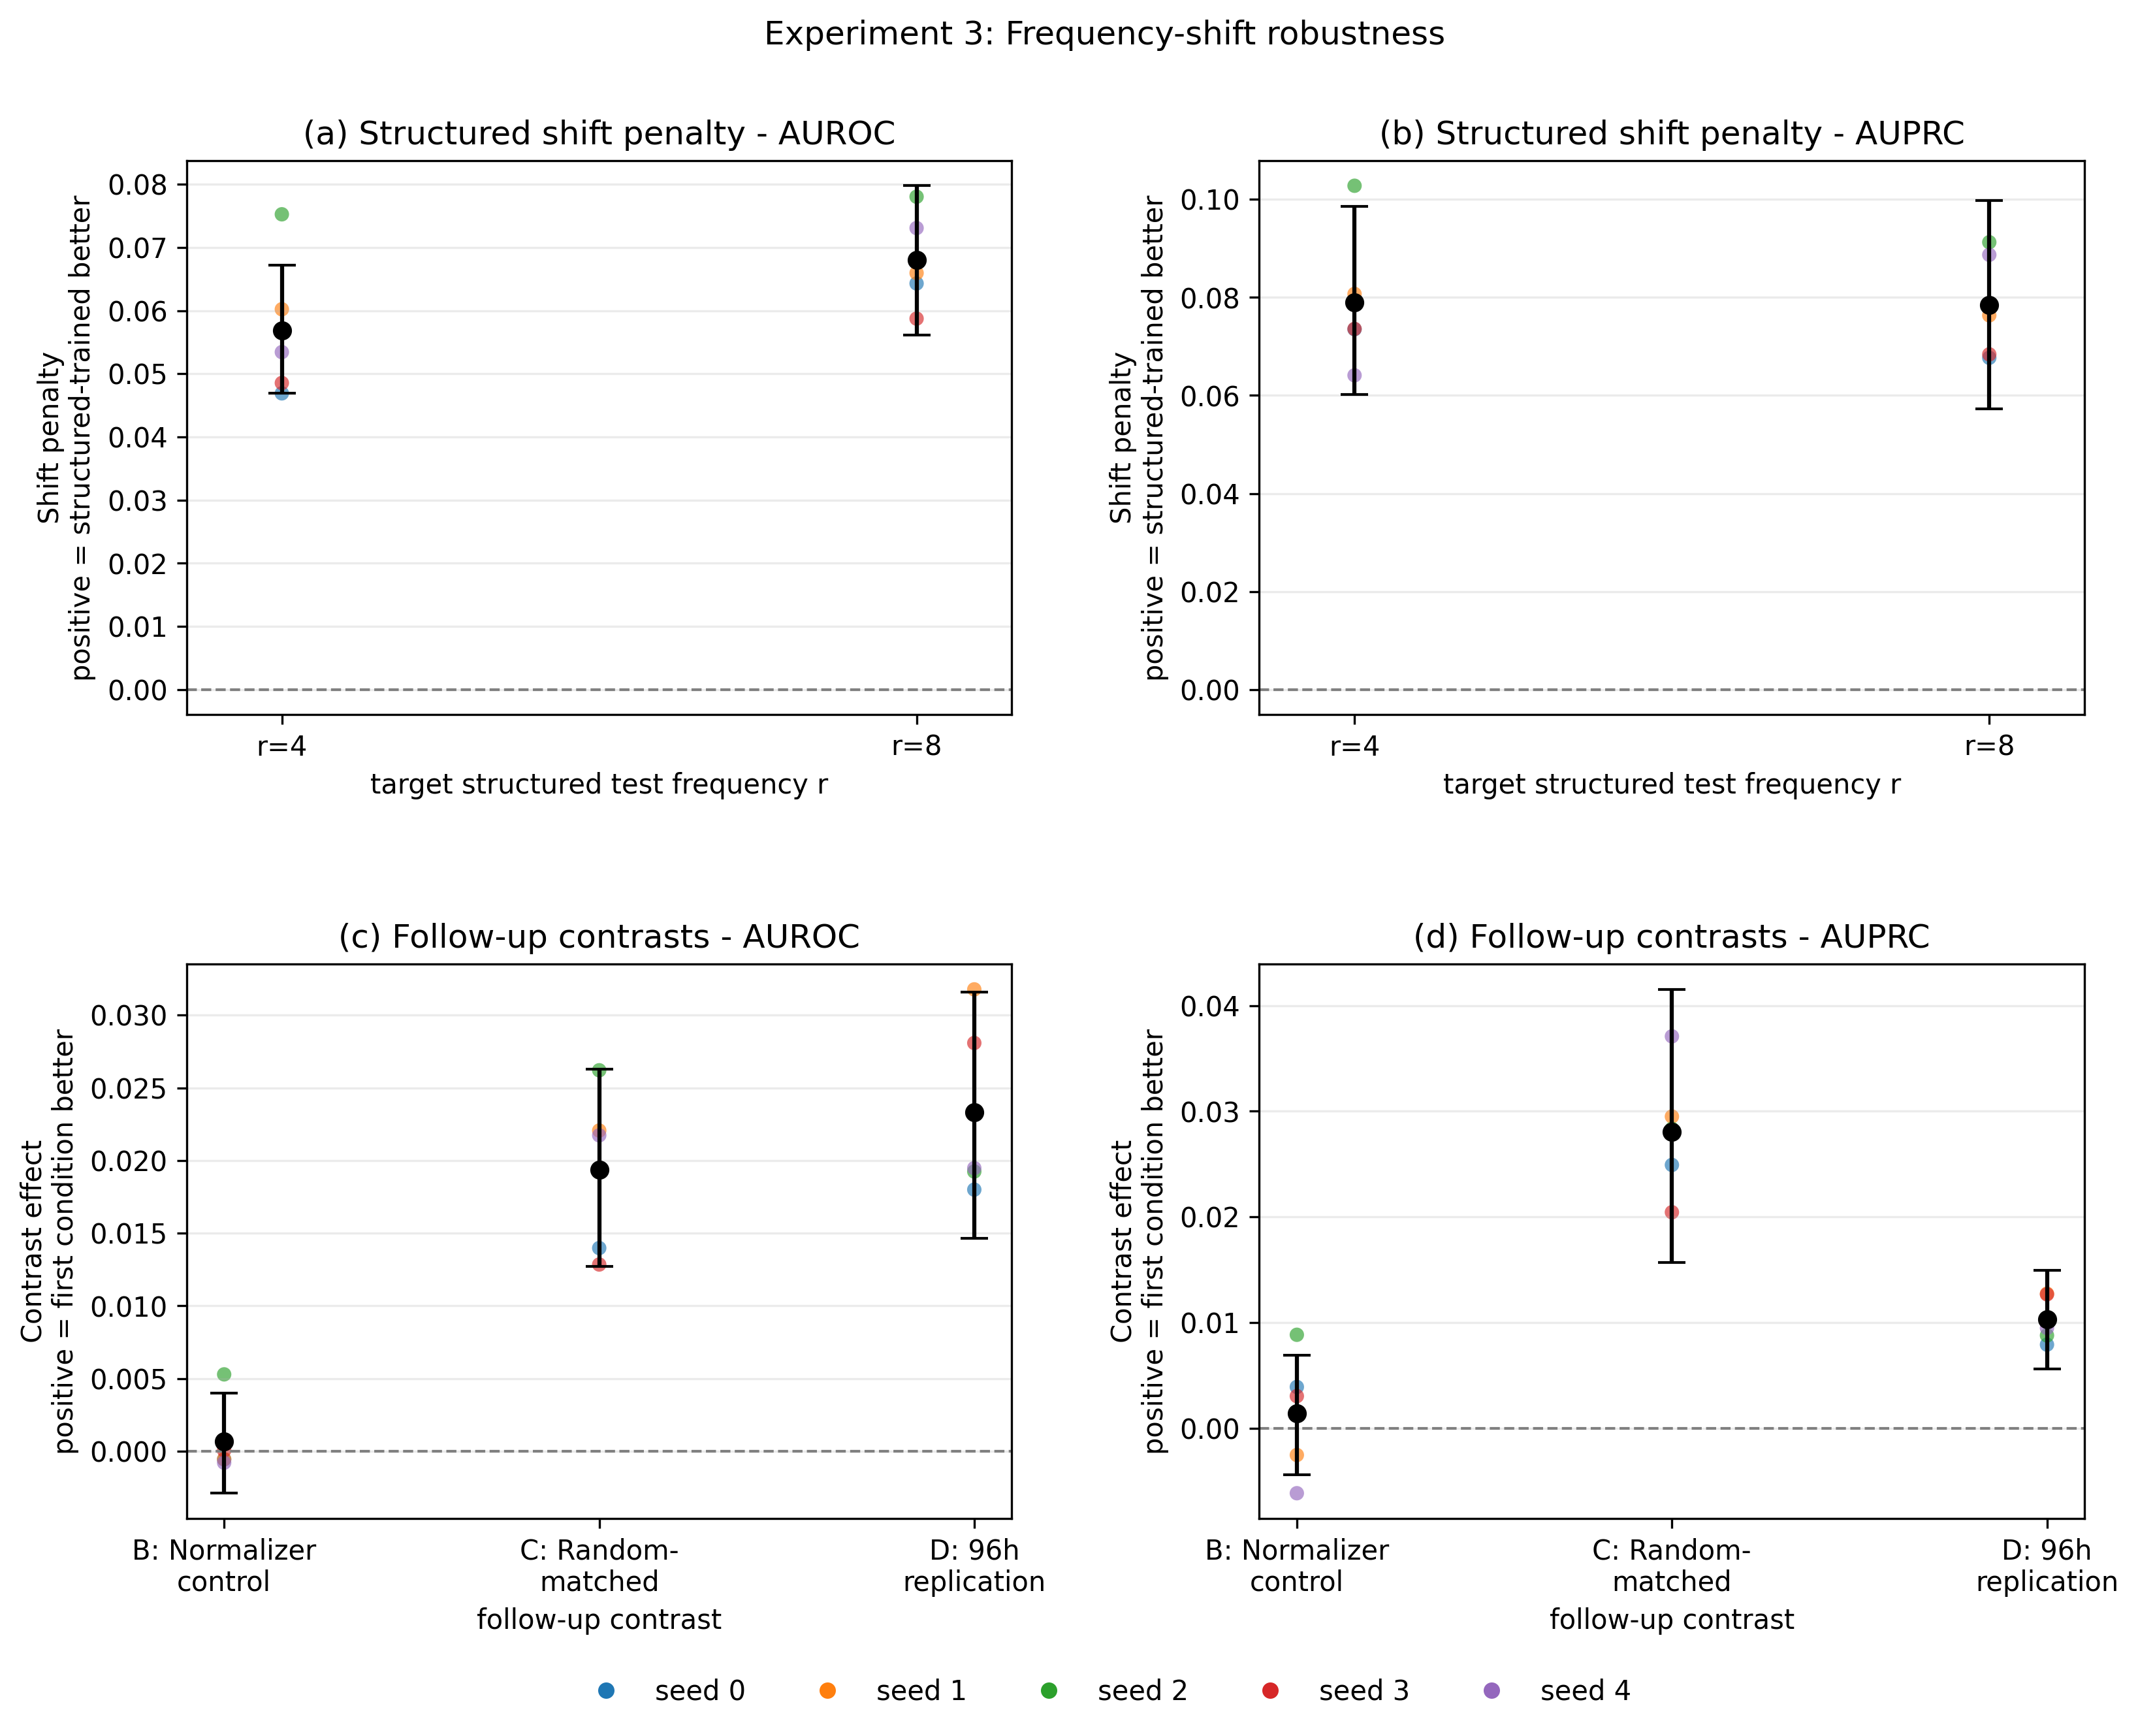

In [46]:
for title, key in [
    ("Exp3A LSTM structured shift recovery", "exp3_lstm_structured_shift_summary"),
    ("Exp3B LSTM normalizer control", "exp3_lstm_normalizer_control_summary"),
    ("Exp3C LSTM random matched-count shift", "exp3_lstm_random_shift_summary"),
    ("Exp3D LSTM longer-horizon replication", "exp3_lstm_horizon_replication_summary"),
    ("Exp3 combined key-contrast summary", "exp3_lstm_combined_key_contrast_summary"),
    ("Exp3 final contrast coverage", "exp3_lstm_final_contrast_coverage"),
]:
    df = add_status(DATA[key], n_col="n_seeds")
    show_table(title, df, ["experiment", "contrast", "horizon", "r", "metric", "left_condition", "right_condition", "mean_difference", "sd_difference", "seed_ci95_low", "seed_ci95_high", "patient_bootstrap_ci_low", "patient_bootstrap_ci_high", "n_seeds", "expected_seeds", "missing_seeds", "status", "present_in_final_summary", "final_reporting_ready"], max_rows=300)

show_source_plot(
    "exp3_lstm",
    FH_PLOTS,
    "experiment3_abcd_frequency_shift_bootstrap_ci95.png",
    "Exp3 LSTM source figure: A-D frequency-shift robustness",
)


**Exp3E raw/grid guide:** Raw mismatch recovery compares raw matched sparse training against raw dense-trained sparse deployment. Grid-vs-raw reports `Delta_grid - Delta_raw`; positive means the fixed-grid representation has a larger frequency-shift penalty than raw. The diagnostic compares grid matched-frequency against raw dense-trained as a descriptive robustness check, not an isolated causal contrast.


In [47]:
for title, key in [
    ("Exp3E LSTM raw condition-level performance", "exp3e_lstm_raw_absolute_summary"),
    ("Exp3E LSTM raw mismatch recovery", "exp3e_lstm_raw_shift_summary"),
    ("Exp3E LSTM grid-vs-raw difference-of-shifts", "exp3_lstm_grid_vs_raw_shift_summary"),
    ("Exp3E LSTM grid-matched vs raw-dense diagnostic", "exp3e_lstm_grid_matched_vs_raw_dense_summary"),
]:
    df = add_status(DATA[key], n_col="n_seeds")
    show_table(title, df, max_rows=300)



Exp3E LSTM raw condition-level performance
NOT AVAILABLE

Exp3E LSTM raw mismatch recovery


,complete_seed_set,contrast,expected_seeds,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,right_condition,right_mean,right_normalizer_regime,sd_difference,status
0,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.445498,raw_train_matched,0.049713,auprc,5,0.066420,0.033719,4,raw-dense->raw-structured-r4,0.395785,raw_train_matched,0.005474,COMPLETE
1,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.710251,raw_train_matched,0.041860,auroc,5,0.051997,0.032464,4,raw-dense->raw-structured-r4,0.668391,raw_train_matched,0.002401,COMPLETE
2,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r4->raw-structured-r4,0.169607,raw_train_matched,0.009133,brier,5,0.011614,0.006668,4,raw-dense->raw-structured-r4,0.178740,raw_train_matched,0.001027,COMPLETE
3,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.425344,raw_train_matched,0.082347,auprc,5,0.101483,0.063702,8,raw-dense->raw-structured-r8,0.342997,raw_train_matched,0.002465,COMPLETE
4,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.695039,raw_train_matched,0.069381,auroc,5,0.082358,0.056418,8,raw-dense->raw-structured-r8,0.625658,raw_train_matched,0.008480,COMPLETE
5,True,raw structured shift,5,Exp3E Raw-representation frequency shift,12,raw-structured-r8->raw-structured-r8,0.173237,raw_train_matched,0.013179,brier,5,0.016200,0.010100,8,raw-dense->raw-structured-r8,0.186416,raw_train_matched,0.001994,COMPLETE



Exp3E LSTM grid-vs-raw difference-of-shifts


,complete_seed_set,expected_seeds,mean_grid_minus_raw_shift,mean_grid_shift,mean_raw_shift,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,sd_grid_minus_raw_shift,status
0,True,5,0.029224,0.078936,0.049713,auprc,5,0.047546,0.010936,4,0.014731,COMPLETE
1,True,5,0.015004,0.056864,0.041860,auroc,5,0.025764,0.004918,4,0.010234,COMPLETE
2,True,5,0.006561,0.015694,0.009133,brier,5,0.009142,0.004086,4,0.003201,COMPLETE
3,True,5,-0.003874,0.078472,0.082347,auprc,5,0.014902,-0.021418,8,0.010846,COMPLETE
4,True,5,-0.001369,0.068012,0.069381,auroc,5,0.009913,-0.011920,8,0.010267,COMPLETE
5,True,5,0.004196,0.017375,0.013179,brier,5,0.006549,0.001810,8,0.002115,COMPLETE



Exp3E LSTM grid-matched vs raw-dense diagnostic


,complete_seed_set,expected_seeds,mean_difference,mean_grid_matched,mean_raw_dense_to_structured,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,r,sd_difference,status
0,True,5,0.080829,0.476614,0.395785,auprc,5,0.099550,0.062598,4,0.005967,COMPLETE
1,True,5,0.067662,0.736053,0.668391,auroc,5,0.080234,0.054889,4,0.004098,COMPLETE
2,True,5,0.014109,0.164631,0.178740,brier,5,0.017190,0.011190,4,0.001244,COMPLETE
3,True,5,0.107104,0.450101,0.342997,auprc,5,0.128481,0.085930,8,0.010049,COMPLETE
4,True,5,0.094153,0.719811,0.625658,auroc,5,0.108909,0.079093,8,0.009875,COMPLETE
5,True,5,0.017781,0.168635,0.186416,brier,5,0.021397,0.014345,8,0.002307,COMPLETE


**Raw representation characterization:** Raw inputs keep irregular timestamp rows rather than the fixed 1h grid. Token count is the number of retained observed variable values; timestamp-row count is the number of distinct retained raw timestamps needed to represent those values. The raw sequence-length sanity check is the retained raw row count after the 24h window filter and should not be interpreted as information content.


In [ ]:
exp3e_raw_characterization_cols = [
    "condition", "r", "n_stays",
    "mean_token_count", "median_token_count", "p25_token_count", "p75_token_count", "p95_token_count",
    "mean_token_retained_fraction", "median_token_retained_fraction",
    "mean_timestamp_rows", "median_timestamp_rows", "p25_timestamp_rows", "p75_timestamp_rows", "p95_timestamp_rows", "max_timestamp_rows",
    "mean_raw_sequence_length", "median_raw_sequence_length", "p25_raw_sequence_length", "p75_raw_sequence_length", "p95_raw_sequence_length", "max_raw_sequence_length",
]
show_table(
    "Exp3E raw representation token and timestamp-row characterization",
    DATA["exp3e_raw_representation_characterization_summary"],
    exp3e_raw_characterization_cols,
    max_rows=20,
)


## 12. GRU-D Experiment 3

### Scientific Question
Does explicitly modeling observation masks and elapsed time with GRU-D change sensitivity to observation-frequency shift?

### Experimental Design
- Model: GRU-D. 
- Task and Exp3A-D definitions follow the LSTM Exp3 notebook. Implemented analyses include structured shift at h=12 r=4/r=8, normalizer control at h=12 r=4, random matched-count h=12 r=4 sampling seed 100, and h=96 r=4 structured replication.

### Quantity Being Measured
Absolute performance and mismatch/control contrasts use the same orientation as LSTM Exp3. For AUPRC/AUROC, positive recovery means matched sparse training performs better on sparse deployment. For Brier, positive means matched training has lower Brier because the source reports mismatched minus matched.

### Why This Comparison Is Informative
GRU-D uses masks and elapsed time, so it may respond differently to observation-frequency shifts than an LSTM on gridded inputs.

### Expected Evidence
Smaller, larger, or similar GRU-D effects relative to LSTM are all informative. Do not conclude universal superiority from one point estimate, especially under partial seeds.

### Caveats
GRU-D runs may still be in progress. Partial result sets are valid exploratory outputs but not final evidence.


**GRU-D tables/plots guide:** Absolute tables use Student-t CIs across model seeds. Contrast summaries show both seed CIs and patient-bootstrap CIs when exported. Partial `n` is displayed instead of suppressing incomplete analyses.



GRU-D absolute condition performance


,ci95,ci95_high,ci95_low,condition,experiment,horizon,mean,metric,n,normalizer_regime,sd,sem,target_r,test_regime,train_regime,observed_seeds,missing_seeds,complete_seed_set,status
0,0.014598,0.448377,0.419181,dense->dense,Exp3A Structured frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,4,dense,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE
1,0.008493,0.345980,0.328993,dense->structured-r4,Exp3A Structured frequency shift,12,0.337487,auprc,5,train_matched,0.006840,0.003059,4,structured-r4,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE
2,0.013207,0.423401,0.396987,structured-r4->structured-r4,Exp3A Structured frequency shift,12,0.410194,auprc,5,train_matched,0.010637,0.004757,4,structured-r4,structured-r4,"[0, 1, 2, 3, 4]",[],True,COMPLETE
3,0.014598,0.448377,0.419181,dense->dense,Exp3A Structured frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,8,dense,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE
4,0.007007,0.332486,0.318472,dense->structured-r8,Exp3A Structured frequency shift,12,0.325479,auprc,5,train_matched,0.005643,0.002524,8,structured-r8,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE
5,0.018838,0.387897,0.350222,structured-r8->structured-r8,Exp3A Structured frequency shift,12,0.369060,auprc,5,train_matched,0.015171,0.006785,8,structured-r8,structured-r8,"[0, 1, 2, 3, 4]",[],True,COMPLETE
6,0.012895,0.421652,0.395861,structured-r4 train + dense norm,Exp3B Normalizer control,12,0.408757,auprc,5,dense,0.010385,0.004645,4,structured-r4,structured-r4,"[0, 1, 2, 3, 4]",[],True,COMPLETE
7,0.013207,0.423401,0.396987,structured-r4 train + train-matched norm,Exp3B Normalizer control,12,0.410194,auprc,5,train_matched,0.010637,0.004757,4,structured-r4,structured-r4,"[0, 1, 2, 3, 4]",[],True,COMPLETE
8,0.014598,0.448377,0.419181,dense->dense,Exp3C Random-matched frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,4,dense,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE
9,0.017219,0.353758,0.319319,dense->random-r4,Exp3C Random-matched frequency shift,12,0.336538,auprc,5,train_matched,0.013868,0.006202,4,random-r4-sseed100,dense,"[0, 1, 2, 3, 4]",[],True,COMPLETE



GRU-D Exp3A structured shift


,complete_seed_set,contrast,difference_orientation,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,missing_seeds,model,n_seeds,observed_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,patient_bootstrap_mean_difference,r,right_condition,right_mean,right_normalizer_regime,sampling,sd_difference,sem_difference,student_t_ci95,student_t_ci95_high,student_t_ci95_low,expected_seeds,status
0,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.410194,train_matched,0.072707,auprc,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.090946,0.055506,0.072707,4,dense->structured-r4,0.337487,train_matched,structured,0.006017,0.002691,0.007471,0.080178,0.065236,5,COMPLETE
1,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.685415,train_matched,0.067359,auroc,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.081737,0.054066,0.067359,4,dense->structured-r4,0.618056,train_matched,structured,0.003578,0.001600,0.004443,0.071802,0.062916,5,COMPLETE
2,True,structured shift,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.175589,train_matched,0.010797,brier,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.013108,0.008538,0.010797,4,dense->structured-r4,0.186386,train_matched,structured,0.002438,0.001090,0.003027,0.013824,0.007770,5,COMPLETE
3,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.369060,train_matched,0.043580,auprc,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.059765,0.027755,0.043580,8,dense->structured-r8,0.325479,train_matched,structured,0.020043,0.008963,0.024886,0.068466,0.018694,5,COMPLETE
4,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.655828,train_matched,0.049247,auroc,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.061543,0.037526,0.049247,8,dense->structured-r8,0.606580,train_matched,structured,0.021562,0.009643,0.026772,0.076020,0.022475,5,COMPLETE
5,True,structured shift,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.180290,train_matched,0.007898,brier,[],GRU-D,5,"[0, 1, 2, 3, 4]",0.010124,0.005679,0.007898,8,dense->structured-r8,0.188187,train_matched,structured,0.004111,0.001838,0.005104,0.013002,0.002794,5,COMPLETE



GRU-D Exp3B normalizer control


...


GRU-D final status


,complete_seed_set,experiment,horizon,missing_seeds,n_seeds,observed_seeds,r,sub_experiment,expected_seeds,status
0,True,Exp3A Structured frequency shift,12,[],5,"[0, 1, 2, 3, 4]",4,Exp3A r4,5,COMPLETE
1,True,Exp3A Structured frequency shift,12,[],5,"[0, 1, 2, 3, 4]",8,Exp3A r8,5,COMPLETE
2,True,Exp3B Normalizer control,12,[],5,"[0, 1, 2, 3, 4]",4,Exp3B,5,COMPLETE
3,True,Exp3C Random-matched frequency shift,12,[],5,"[0, 1, 2, 3, 4]",4,Exp3C,5,COMPLETE
4,True,Exp3D Horizon replication,96,[],5,"[0, 1, 2, 3, 4]",4,Exp3D,5,COMPLETE



GRU-D final contrast coverage


,complete_seed_set,contrast,experiment,final_reporting_ready,horizon,metric,n_seeds,present,r,expected_seeds,status
0,True,structured shift,Exp3A Structured frequency shift,True,12,auprc,5,True,4,5,COMPLETE
1,True,structured shift,Exp3A Structured frequency shift,True,12,auroc,5,True,4,5,COMPLETE
2,True,structured shift,Exp3A Structured frequency shift,True,12,brier,5,True,4,5,COMPLETE
3,True,structured shift,Exp3A Structured frequency shift,True,12,auprc,5,True,8,5,COMPLETE
4,True,structured shift,Exp3A Structured frequency shift,True,12,auroc,5,True,8,5,COMPLETE
5,True,structured shift,Exp3A Structured frequency shift,True,12,brier,5,True,8,5,COMPLETE
6,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,auprc,5,True,4,5,COMPLETE
7,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,auroc,5,True,4,5,COMPLETE
8,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,brier,5,True,4,5,COMPLETE
9,False,structured shift,Exp3D Horizon replication,False,96,auprc,0,False,4,5,NOT AVAILABLE



GRU-D source figure: A-D frequency-shift robustness


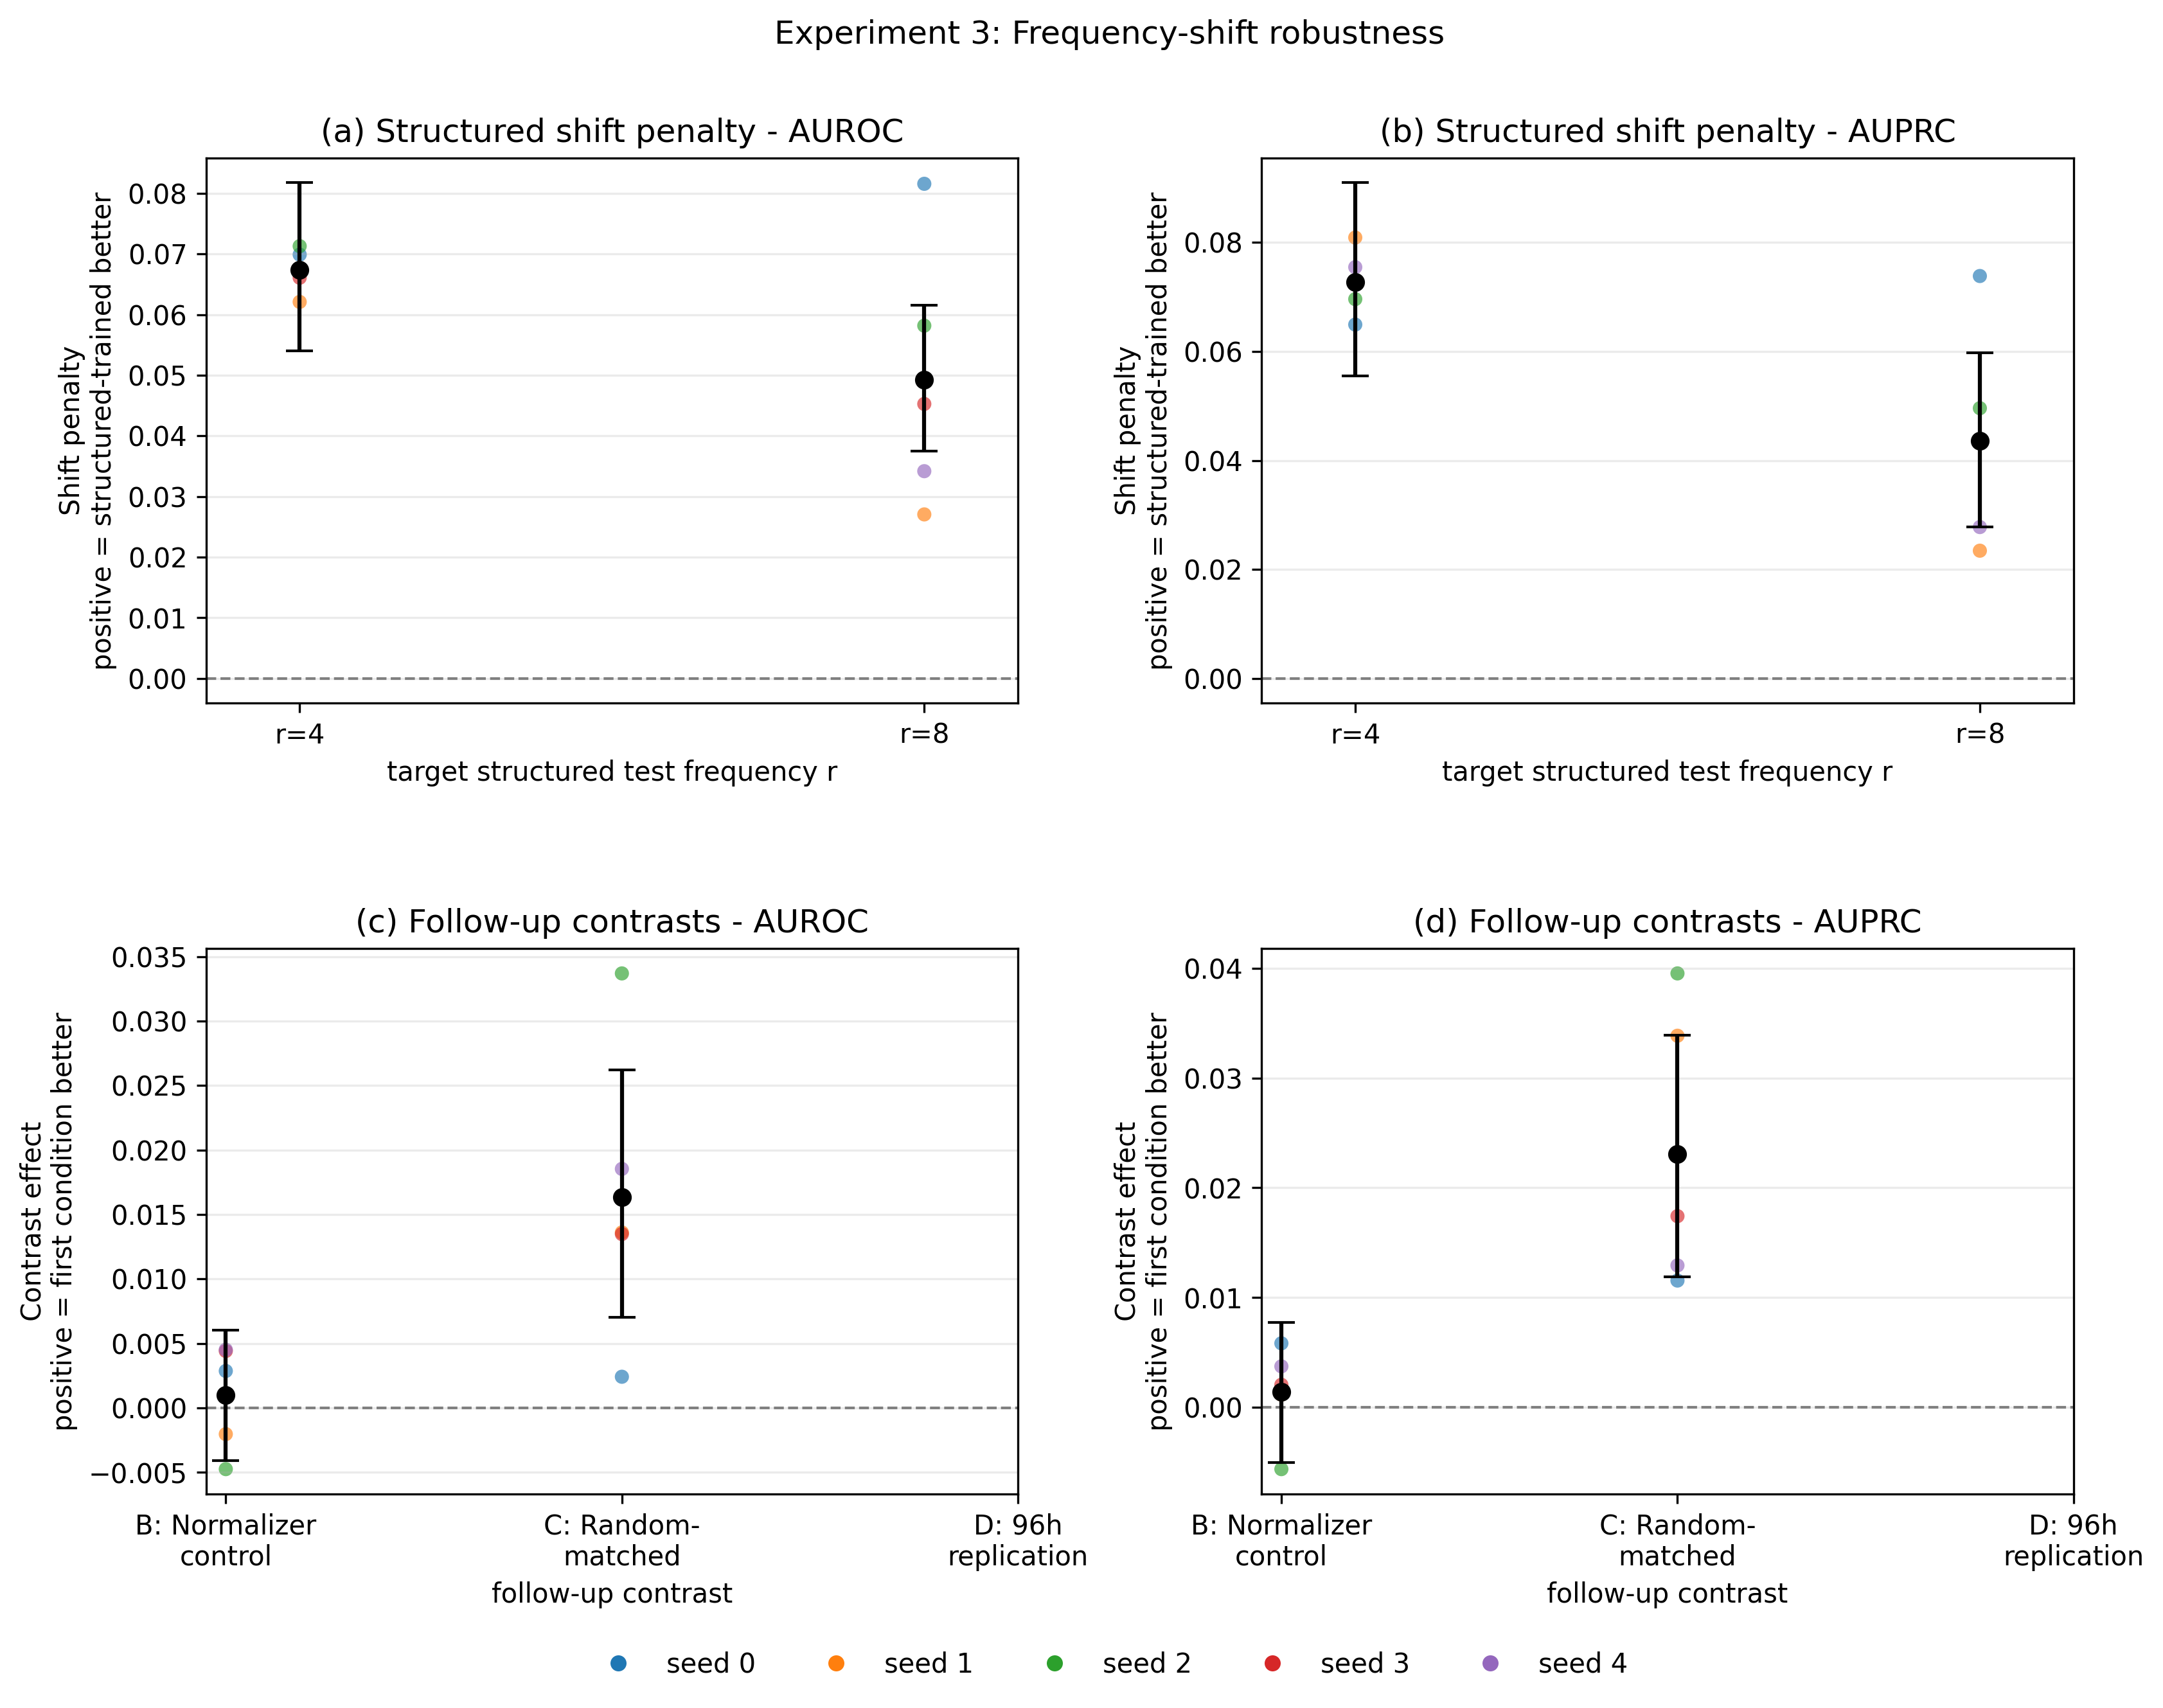

In [49]:
for title, key in [
    ("GRU-D absolute condition performance", "exp3_grud_across_seed_summary"),
    ("GRU-D Exp3A structured shift", "exp3_grud_structured_shift_summary"),
    ("GRU-D Exp3B normalizer control", "exp3_grud_normalizer_control_summary"),
    ("GRU-D Exp3C random matched-count shift", "exp3_grud_random_shift_summary"),
    ("GRU-D Exp3D horizon replication", "exp3_grud_horizon_replication_summary"),
    ("GRU-D combined key-contrast summary", "exp3_grud_combined_key_contrast_summary"),
    ("GRU-D final status", "exp3_grud_final_status"),
    ("GRU-D final contrast coverage", "exp3_grud_final_contrast_coverage"),
]:
    df = add_status(DATA[key], n_col="n_seeds")
    show_table(title, df, max_rows=300)

show_source_plot(
    "exp3_grud",
    FH_PLOTS,
    "experiment3_grud_abcd_frequency_shift_bootstrap_ci95.png",
    "GRU-D source figure: A-D frequency-shift robustness",
)


## 13-17. Cross-Experiment Comparisons

### Scientific Questions
These exploratory comparisons connect the individual experiments:

- LSTM vs GRU-D: does mask/time modeling alter frequency-shift sensitivity?
- Structured vs random matched thinning: how much effect is due to fewer observations versus temporal removal pattern?
- r4 vs r8 information-loss severity: does increasing structured sparsity from r4 to r8 remove progressively more predictive information, independent of mismatch recovery?
- r4 vs r8 mismatch-recovery severity: does matched sparse training recover more sparse-deployment performance as thinning becomes stronger?
- Short vs long horizon: does h=12 differ from h=96, linking back to Exp2A?
- Grid vs raw representation: does hourly gridding amplify the shift penalty?

### Quantity Being Measured
All effect sizes use source CSV exports. For Exp3 contrasts, positive means matched/left/reference condition is better; Brier is oriented so positive means improvement. For grid-vs-raw, positive `grid - raw` means a larger shift penalty in the grid representation.

A. Information loss severity compares dense-trained dense evaluation with dense-trained sparse structured evaluation: `dense -> dense` versus `dense -> structured-r` for r4 and r8. It asks whether stronger sparsity removes progressively more predictive information.

B. Mismatch recovery severity remains separate: `matched sparse -> sparse` versus `dense -> sparse`. It asks whether training on the sparse observation regime recovers sparse-deployment performance.

### Interpretation
If information-loss magnitude is larger at r8 than r4, stronger thinning is associated with greater degradation when the dense-trained model is deployed on sparse observations. If r4 and r8 are similar, information loss may saturate or be relatively insensitive over this range. Non-monotonic results should remain visible.

For mismatch recovery, larger effects at r8 than r4 suggest matched sparse training helps more under stronger deployment shift. Flat or non-monotonic recovery should also remain visible.

### Caveats
These are side-by-side exploratory comparisons. They do not require complete five-seed results for both models and should not be overinterpreted as architecture rankings.


In [50]:
def model_effect_table(lstm, grud):
    rows = []
    common_specs = [
        ("structured r4 h12", "Exp3A Structured frequency shift", 12, 4, "structured shift"),
        ("structured r8 h12", "Exp3A Structured frequency shift", 12, 8, "structured shift"),
        ("normalizer control", "Exp3B Normalizer control", 12, 4, "normalizer control"),
        ("random matched r4 h12", "Exp3C Random-matched frequency shift", 12, 4, "random-matched shift"),
        ("structured r4 h96", "Exp3D Horizon replication", 96, 4, "structured shift"),
    ]
    for label, experiment, horizon, r, contrast in common_specs:
        for metric in METRICS:
            row = {"comparison": label, "experiment": experiment, "horizon": horizon, "r": r, "metric": metric}
            for model, df in [("LSTM", lstm), ("GRU-D", grud)]:
                sub = df[
                    (df.get("experiment", pd.Series(dtype=str)).astype(str) == experiment) &
                    (pd.to_numeric(df.get("horizon", pd.Series(dtype=float)), errors="coerce") == horizon) &
                    (pd.to_numeric(df.get("r", pd.Series(dtype=float)), errors="coerce") == r) &
                    (df.get("contrast", pd.Series(dtype=str)).astype(str) == contrast) &
                    (df.get("metric", pd.Series(dtype=str)).astype(str) == metric)
                ] if len(df) else pd.DataFrame()
                prefix = model.lower().replace("-", "")
                if len(sub) == 1:
                    one = sub.iloc[0]
                    row.update({
                        f"{prefix}_effect": one.get("mean_difference", np.nan),
                        f"{prefix}_seed_ci_low": one.get("seed_ci95_low", one.get("student_t_ci95_low", np.nan)),
                        f"{prefix}_seed_ci_high": one.get("seed_ci95_high", one.get("student_t_ci95_high", np.nan)),
                        f"{prefix}_patient_ci_low": one.get("patient_bootstrap_ci_low", np.nan),
                        f"{prefix}_patient_ci_high": one.get("patient_bootstrap_ci_high", np.nan),
                        f"{prefix}_n": one.get("n_seeds", np.nan),
                        f"{prefix}_status": status_from_n(one.get("n_seeds", 0)),
                    })
                else:
                    row.update({f"{prefix}_status": "NOT AVAILABLE"})
            rows.append(row)
    return pd.DataFrame(rows)


def metric_difference_for_summary(left_value, right_value, metric):
    if pd.isna(left_value) or pd.isna(right_value):
        return np.nan
    return float(right_value - left_value) if metric == "brier" else float(left_value - right_value)


def exp3a_dense_information_loss_table(run_df):
    rows = []
    columns = ["r", "metric", "information_loss_effect", "seed_ci_low", "seed_ci_high", "n_seeds", "status"]
    if run_df is None or len(run_df) == 0:
        return pd.DataFrame(columns=columns)
    df = run_df[run_df.get("experiment", pd.Series(dtype=str)).astype(str).eq("Exp3A Structured frequency shift")].copy()
    if len(df) == 0:
        return pd.DataFrame(columns=columns)
    df["target_r_num"] = pd.to_numeric(df.get("target_r", pd.Series(dtype=float)), errors="coerce")
    df["model_seed_num"] = pd.to_numeric(df.get("model_seed", pd.Series(dtype=float)), errors="coerce")
    for r in [4, 8]:
        for metric in METRICS:
            diffs = []
            for seed in sorted(df["model_seed_num"].dropna().astype(int).unique()):
                dense = df[(df["condition"].astype(str) == "dense->dense") & (df["model_seed_num"] == seed)]
                sparse = df[(df["condition"].astype(str) == "dense->structured-r{}".format(r)) & (df["target_r_num"] == r) & (df["model_seed_num"] == seed)]
                col = "test_{}".format(metric)
                if len(dense) and len(sparse) and col in dense.columns and col in sparse.columns:
                    diffs.append(metric_difference_for_summary(dense.iloc[0][col], sparse.iloc[0][col], metric))
            values = np.asarray([x for x in diffs if not pd.isna(x)], dtype=float)
            n = len(values)
            mean = float(np.mean(values)) if n else np.nan
            sd = float(np.std(values, ddof=1)) if n > 1 else np.nan
            sem = sd / np.sqrt(n) if n > 1 else np.nan
            ci95 = float(t.ppf(0.975, n - 1) * sem) if n > 1 else np.nan
            rows.append({
                "r": r,
                "metric": metric,
                "information_loss_effect": mean,
                "seed_ci_low": mean - ci95 if n > 1 else np.nan,
                "seed_ci_high": mean + ci95 if n > 1 else np.nan,
                "n_seeds": int(n),
                "status": status_from_n(n),
            })
    return pd.DataFrame(rows, columns=columns)


lstm_combined = DATA["exp3_lstm_combined_key_contrast_summary"].copy()
grud_combined = DATA["exp3_grud_combined_key_contrast_summary"].copy()
lstm_vs_grud = model_effect_table(lstm_combined, grud_combined)
show_table("LSTM vs GRU-D common frequency-shift effects", lstm_vs_grud, max_rows=200)

structured_random = lstm_vs_grud[lstm_vs_grud["comparison"].isin(["structured r4 h12", "random matched r4 h12"])]
show_table("Structured vs random matched thinning", structured_random, max_rows=100)

information_loss_severity = exp3a_dense_information_loss_table(DATA["exp3_lstm_run_results"])
show_table("A. r4 vs r8 information-loss severity comparison", information_loss_severity, ["r", "metric", "information_loss_effect", "seed_ci_low", "seed_ci_high", "n_seeds", "status"], max_rows=100)

mismatch_recovery_severity = lstm_vs_grud[lstm_vs_grud["comparison"].isin(["structured r4 h12", "structured r8 h12"])]
show_table("B. r4 vs r8 mismatch-recovery severity comparison", mismatch_recovery_severity, max_rows=100)

horizon_cmp = lstm_vs_grud[lstm_vs_grud["comparison"].isin(["structured r4 h12", "structured r4 h96"])]
show_table("Short vs long horizon structured r4 comparison", horizon_cmp, max_rows=100)

show_table("Grid vs raw representation comparison", add_status(DATA["exp3_lstm_grid_vs_raw_shift_summary"], n_col="n_seeds"), ["r", "metric", "mean_grid_shift", "mean_raw_shift", "mean_grid_minus_raw_shift", "n_seeds", "status"], max_rows=100)



LSTM vs GRU-D common frequency-shift effects


,comparison,experiment,grud_effect,grud_n,grud_patient_ci_high,grud_patient_ci_low,grud_seed_ci_high,grud_seed_ci_low,grud_status,horizon,lstm_effect,lstm_n,lstm_patient_ci_high,lstm_patient_ci_low,lstm_seed_ci_high,lstm_seed_ci_low,lstm_status,metric,r
0,structured r4 h12,Exp3A Structured frequency shift,0.072707,5.0,0.090946,0.055506,0.080178,0.065236,COMPLETE,12,0.078936,5,0.098623,0.060167,NaN,NaN,COMPLETE,auprc,4
1,structured r4 h12,Exp3A Structured frequency shift,0.067359,5.0,0.081737,0.054066,0.071802,0.062916,COMPLETE,12,0.056864,5,0.067177,0.046936,NaN,NaN,COMPLETE,auroc,4
2,structured r4 h12,Exp3A Structured frequency shift,0.010797,5.0,0.013108,0.008538,0.013824,0.007770,COMPLETE,12,0.015694,5,0.018801,0.012661,NaN,NaN,COMPLETE,brier,4
3,structured r8 h12,Exp3A Structured frequency shift,0.043580,5.0,0.059765,0.027755,0.068466,0.018694,COMPLETE,12,0.078472,5,0.099748,0.057254,NaN,NaN,COMPLETE,auprc,8
4,structured r8 h12,Exp3A Structured frequency shift,0.049247,5.0,0.061543,0.037526,0.076020,0.022475,COMPLETE,12,0.068012,5,0.079762,0.056095,NaN,NaN,COMPLETE,auroc,8
5,structured r8 h12,Exp3A Structured frequency shift,0.007898,5.0,0.010124,0.005679,0.013002,0.002794,COMPLETE,12,0.017375,5,0.020714,0.013776,NaN,NaN,COMPLETE,brier,8
6,normalizer control,Exp3B Normalizer control,0.001437,5.0,0.007738,-0.005005,0.006812,-0.003938,COMPLETE,12,0.001430,5,0.006905,-0.004415,NaN,NaN,COMPLETE,auprc,4
7,normalizer control,Exp3B Normalizer control,0.001006,5.0,0.006034,-0.004082,0.006189,-0.004177,COMPLETE,12,0.000687,5,0.004003,-0.002889,NaN,NaN,COMPLETE,auroc,4
8,normalizer control,Exp3B Normalizer control,0.000436,5.0,0.001137,-0.000291,0.000642,0.000231,COMPLETE,12,0.000508,5,0.001370,-0.000435,NaN,NaN,COMPLETE,brier,4
9,random matched r4 h12,Exp3C Random-matched frequency shift,0.023057,5.0,0.033898,0.011913,0.038940,0.007175,COMPLETE,12,0.028058,5,0.041527,0.015692,NaN,NaN,COMPLETE,auprc,4



Structured vs random matched thinning


,comparison,experiment,grud_effect,grud_n,grud_patient_ci_high,grud_patient_ci_low,grud_seed_ci_high,grud_seed_ci_low,grud_status,horizon,lstm_effect,lstm_n,lstm_patient_ci_high,lstm_patient_ci_low,lstm_seed_ci_high,lstm_seed_ci_low,lstm_status,metric,r
0,structured r4 h12,Exp3A Structured frequency shift,0.072707,5.0,0.090946,0.055506,0.080178,0.065236,COMPLETE,12,0.078936,5,0.098623,0.060167,NaN,NaN,COMPLETE,auprc,4
1,structured r4 h12,Exp3A Structured frequency shift,0.067359,5.0,0.081737,0.054066,0.071802,0.062916,COMPLETE,12,0.056864,5,0.067177,0.046936,NaN,NaN,COMPLETE,auroc,4
2,structured r4 h12,Exp3A Structured frequency shift,0.010797,5.0,0.013108,0.008538,0.013824,0.007770,COMPLETE,12,0.015694,5,0.018801,0.012661,NaN,NaN,COMPLETE,brier,4
9,random matched r4 h12,Exp3C Random-matched frequency shift,0.023057,5.0,0.033898,0.011913,0.038940,0.007175,COMPLETE,12,0.028058,5,0.041527,0.015692,NaN,NaN,COMPLETE,auprc,4
10,random matched r4 h12,Exp3C Random-matched frequency shift,0.016346,5.0,0.026195,0.007018,0.030439,0.002254,COMPLETE,12,0.019363,5,0.026266,0.012722,NaN,NaN,COMPLETE,auroc,4
11,random matched r4 h12,Exp3C Random-matched frequency shift,0.001817,5.0,0.003442,0.000404,0.004013,-0.000380,COMPLETE,12,0.005186,5,0.007026,0.003398,NaN,NaN,COMPLETE,brier,4



A. r4 vs r8 information-loss severity comparison


...

,comparison,experiment,grud_effect,grud_n,grud_patient_ci_high,grud_patient_ci_low,grud_seed_ci_high,grud_seed_ci_low,grud_status,horizon,lstm_effect,lstm_n,lstm_patient_ci_high,lstm_patient_ci_low,lstm_seed_ci_high,lstm_seed_ci_low,lstm_status,metric,r
0,structured r4 h12,Exp3A Structured frequency shift,0.072707,5.0,0.090946,0.055506,0.080178,0.065236,COMPLETE,12,0.078936,5,0.098623,0.060167,NaN,NaN,COMPLETE,auprc,4
1,structured r4 h12,Exp3A Structured frequency shift,0.067359,5.0,0.081737,0.054066,0.071802,0.062916,COMPLETE,12,0.056864,5,0.067177,0.046936,NaN,NaN,COMPLETE,auroc,4
2,structured r4 h12,Exp3A Structured frequency shift,0.010797,5.0,0.013108,0.008538,0.013824,0.007770,COMPLETE,12,0.015694,5,0.018801,0.012661,NaN,NaN,COMPLETE,brier,4
3,structured r8 h12,Exp3A Structured frequency shift,0.043580,5.0,0.059765,0.027755,0.068466,0.018694,COMPLETE,12,0.078472,5,0.099748,0.057254,NaN,NaN,COMPLETE,auprc,8
4,structured r8 h12,Exp3A Structured frequency shift,0.049247,5.0,0.061543,0.037526,0.076020,0.022475,COMPLETE,12,0.068012,5,0.079762,0.056095,NaN,NaN,COMPLETE,auroc,8
5,structured r8 h12,Exp3A Structured frequency shift,0.007898,5.0,0.010124,0.005679,0.013002,0.002794,COMPLETE,12,0.017375,5,0.020714,0.013776,NaN,NaN,COMPLETE,brier,8



Short vs long horizon structured r4 comparison


,comparison,experiment,grud_effect,grud_n,grud_patient_ci_high,grud_patient_ci_low,grud_seed_ci_high,grud_seed_ci_low,grud_status,horizon,lstm_effect,lstm_n,lstm_patient_ci_high,lstm_patient_ci_low,lstm_seed_ci_high,lstm_seed_ci_low,lstm_status,metric,r
0,structured r4 h12,Exp3A Structured frequency shift,0.072707,5.0,0.090946,0.055506,0.080178,0.065236,COMPLETE,12,0.078936,5,0.098623,0.060167,NaN,NaN,COMPLETE,auprc,4
1,structured r4 h12,Exp3A Structured frequency shift,0.067359,5.0,0.081737,0.054066,0.071802,0.062916,COMPLETE,12,0.056864,5,0.067177,0.046936,NaN,NaN,COMPLETE,auroc,4
2,structured r4 h12,Exp3A Structured frequency shift,0.010797,5.0,0.013108,0.008538,0.013824,0.007770,COMPLETE,12,0.015694,5,0.018801,0.012661,NaN,NaN,COMPLETE,brier,4
12,structured r4 h96,Exp3D Horizon replication,NaN,NaN,NaN,NaN,NaN,NaN,NOT AVAILABLE,96,0.010324,5,0.014934,0.005617,NaN,NaN,COMPLETE,auprc,4
13,structured r4 h96,Exp3D Horizon replication,NaN,NaN,NaN,NaN,NaN,NaN,NOT AVAILABLE,96,0.023313,5,0.031575,0.014630,NaN,NaN,COMPLETE,auroc,4
14,structured r4 h96,Exp3D Horizon replication,NaN,NaN,NaN,NaN,NaN,NaN,NOT AVAILABLE,96,0.003955,5,0.005107,0.002692,NaN,NaN,COMPLETE,brier,4



Grid vs raw representation comparison


,r,metric,mean_grid_shift,mean_raw_shift,mean_grid_minus_raw_shift,n_seeds,status
0,4,auprc,0.078936,0.049713,0.029224,5,COMPLETE
1,4,auroc,0.056864,0.041860,0.015004,5,COMPLETE
2,4,brier,0.015694,0.009133,0.006561,5,COMPLETE
3,8,auprc,0.078472,0.082347,-0.003874,5,COMPLETE
4,8,auroc,0.068012,0.069381,-0.001369,5,COMPLETE
5,8,brier,0.017375,0.013179,0.004196,5,COMPLETE


## Representation and Information Summary

This overview separates observed information from representation structure. Observed tokens, retained fraction, occupied 1h bins, and observed channels describe real measurements retained after sampling. Raw timestamp rows and post-discretization sequence length describe how the retained measurements are represented for the model. Rows are assembled only from saved characterization CSVs produced by the experiment notebooks.


In [ ]:
def _summary_row(df, condition):
    if df is None or len(df) == 0:
        raise RuntimeError("Missing characterization table while building representation summary")
    sub = df[df["condition"].astype(str) == condition]
    if len(sub) != 1:
        raise RuntimeError("Expected one characterization row for {}; got {}".format(condition, len(sub)))
    return sub.iloc[0]


def _grid_representation_row(source, condition, representation, introduced_in):
    row = _summary_row(source, condition)
    return {
        "representation": representation,
        "introduced_in": introduced_in,
        "mean_observed_tokens": row.get("mean_token_count", np.nan),
        "median_observed_tokens": row.get("median_token_count", np.nan),
        "mean_token_retained_fraction": row.get("mean_token_retained_fraction", np.nan),
        "mean_occupied_1h_bins": row.get("mean_occupied_1h_bins", np.nan),
        "mean_channels_observed": row.get("mean_channels_observed", np.nan),
        "mean_raw_timestamp_rows": np.nan,
        "median_raw_timestamp_rows": np.nan,
        "post_discretization_sequence_length": row.get("post_discretization_sequence_length", np.nan),
        "mean_raw_sequence_length": np.nan,
        "median_raw_sequence_length": np.nan,
    }


def _raw_representation_row(raw_source, grid_source, raw_condition, grid_condition, representation, introduced_in):
    raw = _summary_row(raw_source, raw_condition)
    grid = _summary_row(grid_source, grid_condition)
    for col in ["mean_token_count", "median_token_count", "mean_token_retained_fraction"]:
        if pd.notna(raw.get(col, np.nan)) and pd.notna(grid.get(col, np.nan)):
            if abs(float(raw.get(col)) - float(grid.get(col))) > 1e-9:
                raise RuntimeError("{} does not match {} for {}".format(raw_condition, grid_condition, col))
    return {
        "representation": representation,
        "introduced_in": introduced_in,
        "mean_observed_tokens": raw.get("mean_token_count", np.nan),
        "median_observed_tokens": raw.get("median_token_count", np.nan),
        "mean_token_retained_fraction": raw.get("mean_token_retained_fraction", np.nan),
        "mean_occupied_1h_bins": grid.get("mean_occupied_1h_bins", np.nan),
        "mean_channels_observed": grid.get("mean_channels_observed", np.nan),
        "mean_raw_timestamp_rows": raw.get("mean_timestamp_rows", np.nan),
        "median_raw_timestamp_rows": raw.get("median_timestamp_rows", np.nan),
        "post_discretization_sequence_length": np.nan,
        "mean_raw_sequence_length": raw.get("mean_raw_sequence_length", np.nan),
        "median_raw_sequence_length": raw.get("median_raw_sequence_length", np.nan),
    }


representation_information_summary = pd.DataFrame([
    _grid_representation_row(DATA["exp2b_input_information_summary"], "dense", "dense", "baseline"),
    _grid_representation_row(DATA["exp2b_input_information_summary"], "structured-r4", "structured-r4", "Exp2B/C"),
    _grid_representation_row(DATA["exp3a_input_information_summary"], "structured-r8", "structured-r8", "Exp3A"),
    _raw_representation_row(DATA["exp3e_raw_representation_characterization_summary"], DATA["exp3a_input_information_summary"], "dense/raw", "dense", "raw", "Exp3E"),
    _raw_representation_row(DATA["exp3e_raw_representation_characterization_summary"], DATA["exp3a_input_information_summary"], "structured-r4/raw", "structured-r4", "structured-r4/raw", "Exp3E"),
    _raw_representation_row(DATA["exp3e_raw_representation_characterization_summary"], DATA["exp3a_input_information_summary"], "structured-r8/raw", "structured-r8", "structured-r8/raw", "Exp3E"),
])

representation_information_cols = [
    "representation", "introduced_in",
    "mean_observed_tokens", "median_observed_tokens", "mean_token_retained_fraction",
    "mean_occupied_1h_bins", "mean_channels_observed",
    "mean_raw_timestamp_rows", "median_raw_timestamp_rows",
    "post_discretization_sequence_length",
    "mean_raw_sequence_length", "median_raw_sequence_length",
]
representation_information_summary = representation_information_summary[representation_information_cols]
show_table("Representation and information summary", representation_information_summary, max_rows=20)


## 18. Master Everything-Tested Table

**What is shown:** every important exported scientific contrast from Exp1, Exp2A, Exp2B/C, Exp3 LSTM, Exp3E, and GRU-D Exp3.

**How each value is computed:** rows are not recomputed here. They are reshaped from source notebook CSV exports. Effect orientation is recorded explicitly.

**How to read columns:** `effect` is the source point estimate; `seed_ci_*` is the Student-t CI across model seeds; `patient_ci_*` is the paired patient-bootstrap CI when available; `n_seeds`, `expected_n_seeds`, `missing_seeds`, and `status` describe completeness.

**Positive/negative values:** Exp1/Exp2A positive means degradation under coarser resolution. Exp2B/C positive means the left condition is better. Exp3 positive means matched/left condition improves performance; Brier is oriented positive-is-improvement. Grid-vs-raw positive means grid shift exceeds raw shift.

**Relevant pattern:** this table is meant for scanning what has actually been tested and which results are partial.

**Uncertainty interval:** both uncertainty types are preserved in separate columns and may be missing when the source did not compute them.


In [51]:
master_rows = []


def add_master(row):
    base = {
        "experiment": None, "subexperiment": None, "task": None, "model": None,
        "prediction_time": None, "horizon": None, "resolution_or_r": None,
        "train_regime": None, "test_regime": None, "normalizer_regime": None,
        "comparison": None, "metric": None, "effect": np.nan,
        "effect_orientation": None,
        "seed_ci_low": np.nan, "seed_ci_high": np.nan,
        "patient_ci_low": np.nan, "patient_ci_high": np.nan,
        "n_seeds": np.nan, "expected_n_seeds": 5, "missing_seeds": None,
        "status": "NOT AVAILABLE", "source_notebook": None,
    }
    base.update(row)
    if pd.notna(base.get("n_seeds", np.nan)):
        base["status"] = status_from_n(base["n_seeds"], base.get("expected_n_seeds", 5))
    master_rows.append(base)


for metric, df, source in [
    ("auprc", DATA["exp1_auprc_drop_summary"], "visualize_exp1_frequency.ipynb"),
    ("auroc", DATA["exp1_auroc_drop_summary"], "visualize_exp1_frequency.ipynb"),
]:
    for _, r in df.iterrows() if len(df) else []:
        add_master({"experiment": "Exp1", "subexperiment": "degradation from 1h", "task": "in-hospital mortality", "model": "LSTM", "resolution_or_r": r.get("timestep"), "comparison": "1h - coarse", "metric": metric, "effect": r.get("mean"), "effect_orientation": "positive = degradation under coarser resolution", "seed_ci_low": r.get("ci95_low"), "seed_ci_high": r.get("ci95_high"), "n_seeds": r.get("n"), "source_notebook": source})


def exp2a_key(horizon, resolution, metric):
    return (int(horizon), float(resolution), str(metric))


exp2a_rows = {}
exp2a_master_inconsistencies = []
for metric, df in [("auprc", DATA["exp2a_test_auprc_drop_summary"]), ("auroc", DATA["exp2a_test_auroc_drop_summary"])]:
    for _, r in df.iterrows() if len(df) else []:
        key = exp2a_key(r.get("horizon"), r.get("timestep"), metric)
        exp2a_rows[key] = {
            "experiment": "Exp2A",
            "subexperiment": "test degradation from 1h + paired patient bootstrap",
            "task": "fixed-horizon ICU outcome",
            "model": "LSTM",
            "prediction_time": "24h after ICU admission",
            "horizon": r.get("horizon"),
            "resolution_or_r": r.get("timestep"),
            "comparison": "1h - coarse",
            "metric": metric,
            "effect": r.get("mean"),
            "effect_orientation": "positive = degradation under coarser resolution; Brier reversed where available",
            "seed_ci_low": r.get("ci95_low"),
            "seed_ci_high": r.get("ci95_high"),
            "n_seeds": r.get("n"),
            "source_notebook": "visualize_exp2a_horizon.ipynb",
        }

for _, r in DATA["exp2a_bootstrap_summary"].iterrows() if len(DATA["exp2a_bootstrap_summary"]) else []:
    key = exp2a_key(r.get("horizon"), r.get("timestep"), r.get("metric"))
    if key in exp2a_rows:
        base = exp2a_rows[key]
        source_effect = base.get("effect")
        boot_effect = r.get("mean_difference")
        if pd.notna(source_effect) and pd.notna(boot_effect) and abs(float(source_effect) - float(boot_effect)) > 1e-6:
            exp2a_master_inconsistencies.append({
                "horizon": r.get("horizon"),
                "resolution": r.get("timestep"),
                "metric": r.get("metric"),
                "degradation_effect": source_effect,
                "bootstrap_effect": boot_effect,
                "absolute_difference": abs(float(source_effect) - float(boot_effect)),
            })
        base.update({
            "patient_ci_low": r.get("patient_bootstrap_ci_low"),
            "patient_ci_high": r.get("patient_bootstrap_ci_high"),
            "missing_seeds": r.get("missing_seeds"),
        })
        if pd.isna(base.get("n_seeds", np.nan)):
            base["n_seeds"] = r.get("n_seeds")
        if pd.isna(base.get("seed_ci_low", np.nan)):
            base["seed_ci_low"] = r.get("seed_ci95_low")
        if pd.isna(base.get("seed_ci_high", np.nan)):
            base["seed_ci_high"] = r.get("seed_ci95_high")
    else:
        exp2a_rows[key] = {
            "experiment": "Exp2A",
            "subexperiment": "paired patient bootstrap",
            "task": "fixed-horizon ICU outcome",
            "model": "LSTM",
            "prediction_time": "24h after ICU admission",
            "horizon": r.get("horizon"),
            "resolution_or_r": r.get("timestep"),
            "comparison": "1h - coarse",
            "metric": r.get("metric"),
            "effect": r.get("mean_difference"),
            "effect_orientation": "positive = 1h/reference better; Brier reversed",
            "seed_ci_low": r.get("seed_ci95_low"),
            "seed_ci_high": r.get("seed_ci95_high"),
            "patient_ci_low": r.get("patient_bootstrap_ci_low"),
            "patient_ci_high": r.get("patient_bootstrap_ci_high"),
            "n_seeds": r.get("n_seeds"),
            "missing_seeds": r.get("missing_seeds"),
            "source_notebook": "visualize_exp2a_horizon.ipynb",
        }

for key in sorted(exp2a_rows):
    add_master(exp2a_rows[key])

if exp2a_master_inconsistencies:
    show_table("Exp2A degradation/bootstrap point-estimate inconsistencies", pd.DataFrame(exp2a_master_inconsistencies), max_rows=100)

for _, r in DATA["exp2b_across_seed_summary"].iterrows() if len(DATA["exp2b_across_seed_summary"]) else []:
    add_master({"experiment": "Exp2B/C", "subexperiment": "A/B/C/D mechanism", "task": "fixed-horizon ICU outcome", "model": "LSTM", "horizon": r.get("horizon"), "resolution_or_r": r.get("r"), "train_regime": r.get("left_condition"), "test_regime": r.get("right_condition"), "comparison": r.get("contrast"), "metric": r.get("metric"), "effect": r.get("mean_difference"), "effect_orientation": "positive = left condition better; Brier reversed", "seed_ci_low": r.get("seed_ci95_low"), "seed_ci_high": r.get("seed_ci95_high"), "patient_ci_low": r.get("patient_bootstrap_ci_low"), "patient_ci_high": r.get("patient_bootstrap_ci_high"), "n_seeds": r.get("n_seeds"), "missing_seeds": r.get("missing_seeds"), "source_notebook": "visualize_exp2b_matched_count.ipynb"})

for key, model, source in [
    ("exp3_lstm_combined_key_contrast_summary", "LSTM", "visualize_exp3_frequency_shift.ipynb"),
    ("exp3_grud_combined_key_contrast_summary", "GRU-D", "visualize_exp3_grud_frequency_shift.ipynb"),
]:
    df = DATA[key]
    for _, r in df.iterrows() if len(df) else []:
        add_master({"experiment": "Exp3", "subexperiment": r.get("experiment"), "task": "fixed-horizon ICU outcome", "model": model, "horizon": r.get("horizon"), "resolution_or_r": r.get("r"), "train_regime": r.get("left_condition"), "test_regime": r.get("right_condition"), "normalizer_regime": "{} vs {}".format(r.get("left_normalizer_regime"), r.get("right_normalizer_regime")), "comparison": r.get("contrast"), "metric": r.get("metric"), "effect": r.get("mean_difference"), "effect_orientation": "positive = left/matched condition better; Brier reversed", "seed_ci_low": r.get("seed_ci95_low", r.get("student_t_ci95_low")), "seed_ci_high": r.get("seed_ci95_high", r.get("student_t_ci95_high")), "patient_ci_low": r.get("patient_bootstrap_ci_low"), "patient_ci_high": r.get("patient_bootstrap_ci_high"), "n_seeds": r.get("n_seeds"), "missing_seeds": r.get("missing_seeds"), "source_notebook": source})

for _, r in DATA["exp3_lstm_grid_vs_raw_shift_summary"].iterrows() if len(DATA["exp3_lstm_grid_vs_raw_shift_summary"]) else []:
    add_master({"experiment": "Exp3E", "subexperiment": "grid vs raw representation", "task": "fixed-horizon ICU outcome", "model": "LSTM", "horizon": 12, "resolution_or_r": r.get("r"), "comparison": "Delta_grid - Delta_raw", "metric": r.get("metric"), "effect": r.get("mean_grid_minus_raw_shift"), "effect_orientation": "positive = grid shift penalty larger than raw", "n_seeds": r.get("n_seeds"), "source_notebook": "visualize_exp3_frequency_shift.ipynb"})

master_contrasts = pd.DataFrame(master_rows)
show_table("Master everything-tested contrast table", master_contrasts, max_rows=500)



Exp2A degradation/bootstrap point-estimate inconsistencies


,absolute_difference,bootstrap_effect,degradation_effect,horizon,metric,resolution
0,0.028019,0.005955,-0.022064,12,auprc,2
1,0.028019,0.022738,-0.005281,12,auprc,4
2,0.028019,0.077441,0.049422,12,auprc,8
3,0.028019,0.073565,0.045546,12,auprc,12
4,0.028019,0.151240,0.123221,12,auprc,24
5,0.004011,0.001727,-0.002284,96,auprc,2
6,0.004011,0.006907,0.002897,96,auprc,4
7,0.004011,0.011857,0.007846,96,auprc,8
8,0.004011,0.014935,0.010925,96,auprc,12
9,0.004011,0.026142,0.022132,96,auprc,24



Master everything-tested contrast table


,comparison,effect,effect_orientation,expected_n_seeds,experiment,horizon,metric,missing_seeds,model,n_seeds,normalizer_regime,patient_ci_high,patient_ci_low,prediction_time,resolution_or_r,seed_ci_high,seed_ci_low,source_notebook,status,subexperiment,task,test_regime,train_regime
0,1h - coarse,0.000000,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,1.0,0.000000,0.000000,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
1,1h - coarse,-0.011484,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,2.0,-0.000863,-0.022106,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
2,1h - coarse,-0.001151,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,4.0,0.017823,-0.020125,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
3,1h - coarse,0.002436,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,8.0,0.016927,-0.012054,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
4,1h - coarse,0.010617,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,12.0,0.025887,-0.004653,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
5,1h - coarse,0.015598,positive = degradation under coarser resolution,5,Exp1,NaN,auprc,None,LSTM,5.0,None,NaN,NaN,None,24.0,0.026736,0.004460,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
6,1h - coarse,0.000000,positive = degradation under coarser resolution,5,Exp1,NaN,auroc,None,LSTM,5.0,None,NaN,NaN,None,1.0,0.000000,0.000000,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
7,1h - coarse,-0.012291,positive = degradation under coarser resolution,5,Exp1,NaN,auroc,None,LSTM,5.0,None,NaN,NaN,None,2.0,0.009855,-0.034436,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
8,1h - coarse,0.000974,positive = degradation under coarser resolution,5,Exp1,NaN,auroc,None,LSTM,5.0,None,NaN,NaN,None,4.0,0.022950,-0.021001,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None
9,1h - coarse,0.011341,positive = degradation under coarser resolution,5,Exp1,NaN,auroc,None,LSTM,5.0,None,NaN,NaN,None,8.0,0.027064,-0.004381,visualize_exp1_frequency.ipynb,COMPLETE,degradation from 1h,in-hospital mortality,None,None


## 19. Notes For Future Runs

The summary updates when the source notebooks are rerun and their final export cells write CSVs. Keep all experiment discovery, checkpoint selection, normalizer resolution, test inference, prediction loading, provenance checks, and patient bootstrap implementation in the source notebooks.

If a section is `NOT AVAILABLE`, rerun the corresponding source notebook through its export cell. If a section is `PARTIAL`, more seeds can be added and the same source export cell rerun; this dashboard will then pick up the new rows without code changes.
